# Linear models (AR, ARMA, and transformations)
**Category : Applied Time Series Analysis**

![ex5_1.png](ex5_1.png)

In [37]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


In [38]:
d.beluga <- read.table("http://stat.ethz.ch/Teaching/Datasets/WBL/beluga.dat",
header=T)
d.beluga <- ts(d.beluga)

In [39]:
print(d.beluga)

Time Series:
Start = 1 
End = 160 
Frequency = 1 
    PERIOD    BOUTS   NURSING  LOCKONS DAYNIGHT
  1      1 0.000000  0.000000 0.000000        0
  2      2 0.000000  0.000000 0.000000        1
  3      3 0.000000  0.000000 0.000000        1
  4      4 0.000000  0.000000 0.000000        0
  5      5 0.000000  0.000000 0.000000        0
  6      6 2.000000  5.099020 2.236068        1
  7      7 3.162278  6.480741 3.316625        1
  8      8 3.000000 11.958261 4.123106        0
  9      9 3.605551 15.620499 5.744563        0
 10     10 3.000000 11.704700 5.000000        1
 11     11 3.316625 13.228757 6.082763        1
 12     12 3.162278 13.453624 5.196152        0
 13     13 2.828427 10.246951 4.582576        0
 14     14 3.000000 13.784049 5.830952        1
 15     15 3.000000 14.247807 5.656854        1
 16     16 2.645751 14.212670 4.582576        0
 17     17 2.645751 14.212670 4.123106        0
 18     18 2.828427 12.727922 4.582576        1
 19     19 2.449490 11.000000 3.464102

In [40]:
print(d.beluga[,"PERIOD"])

Time Series:
Start = 1 
End = 160 
Frequency = 1 
  [1]   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
 [19]  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
 [37]  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
 [55]  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
 [73]  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
 [91]  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
[109] 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
[127] 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
[145] 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160


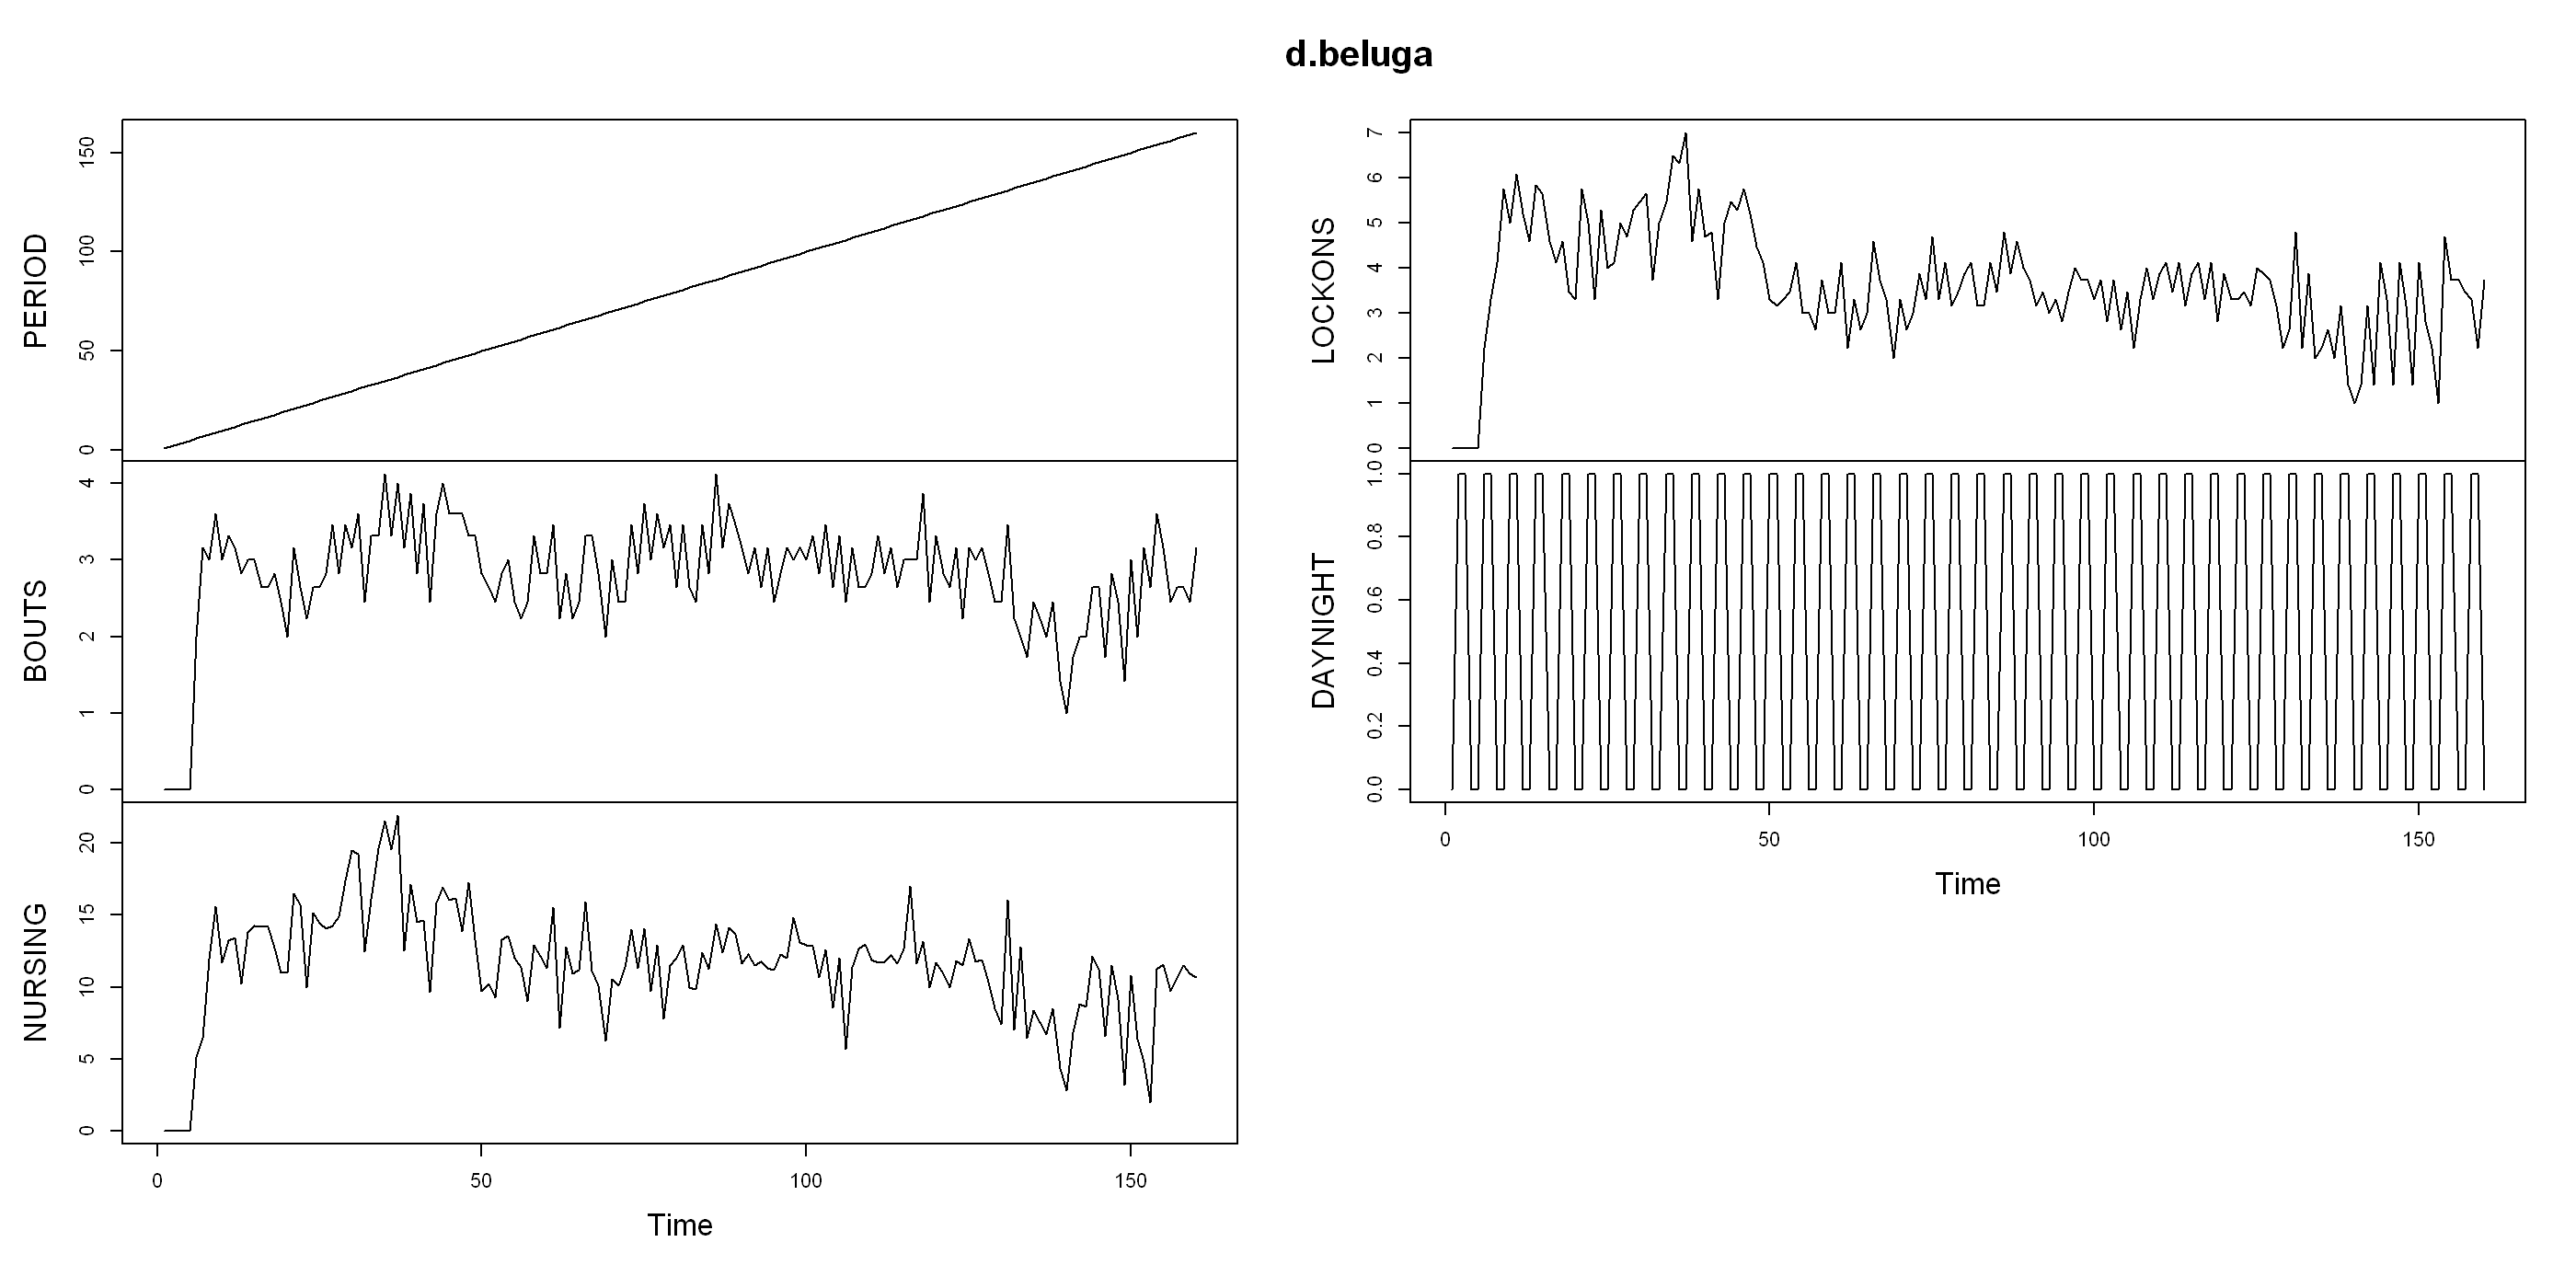

In [41]:
plot(d.beluga)

#### a

In [42]:
lin_model <- lm(NURSING ~ PERIOD + BOUTS + LOCKONS + DAYNIGHT, data = d.beluga)

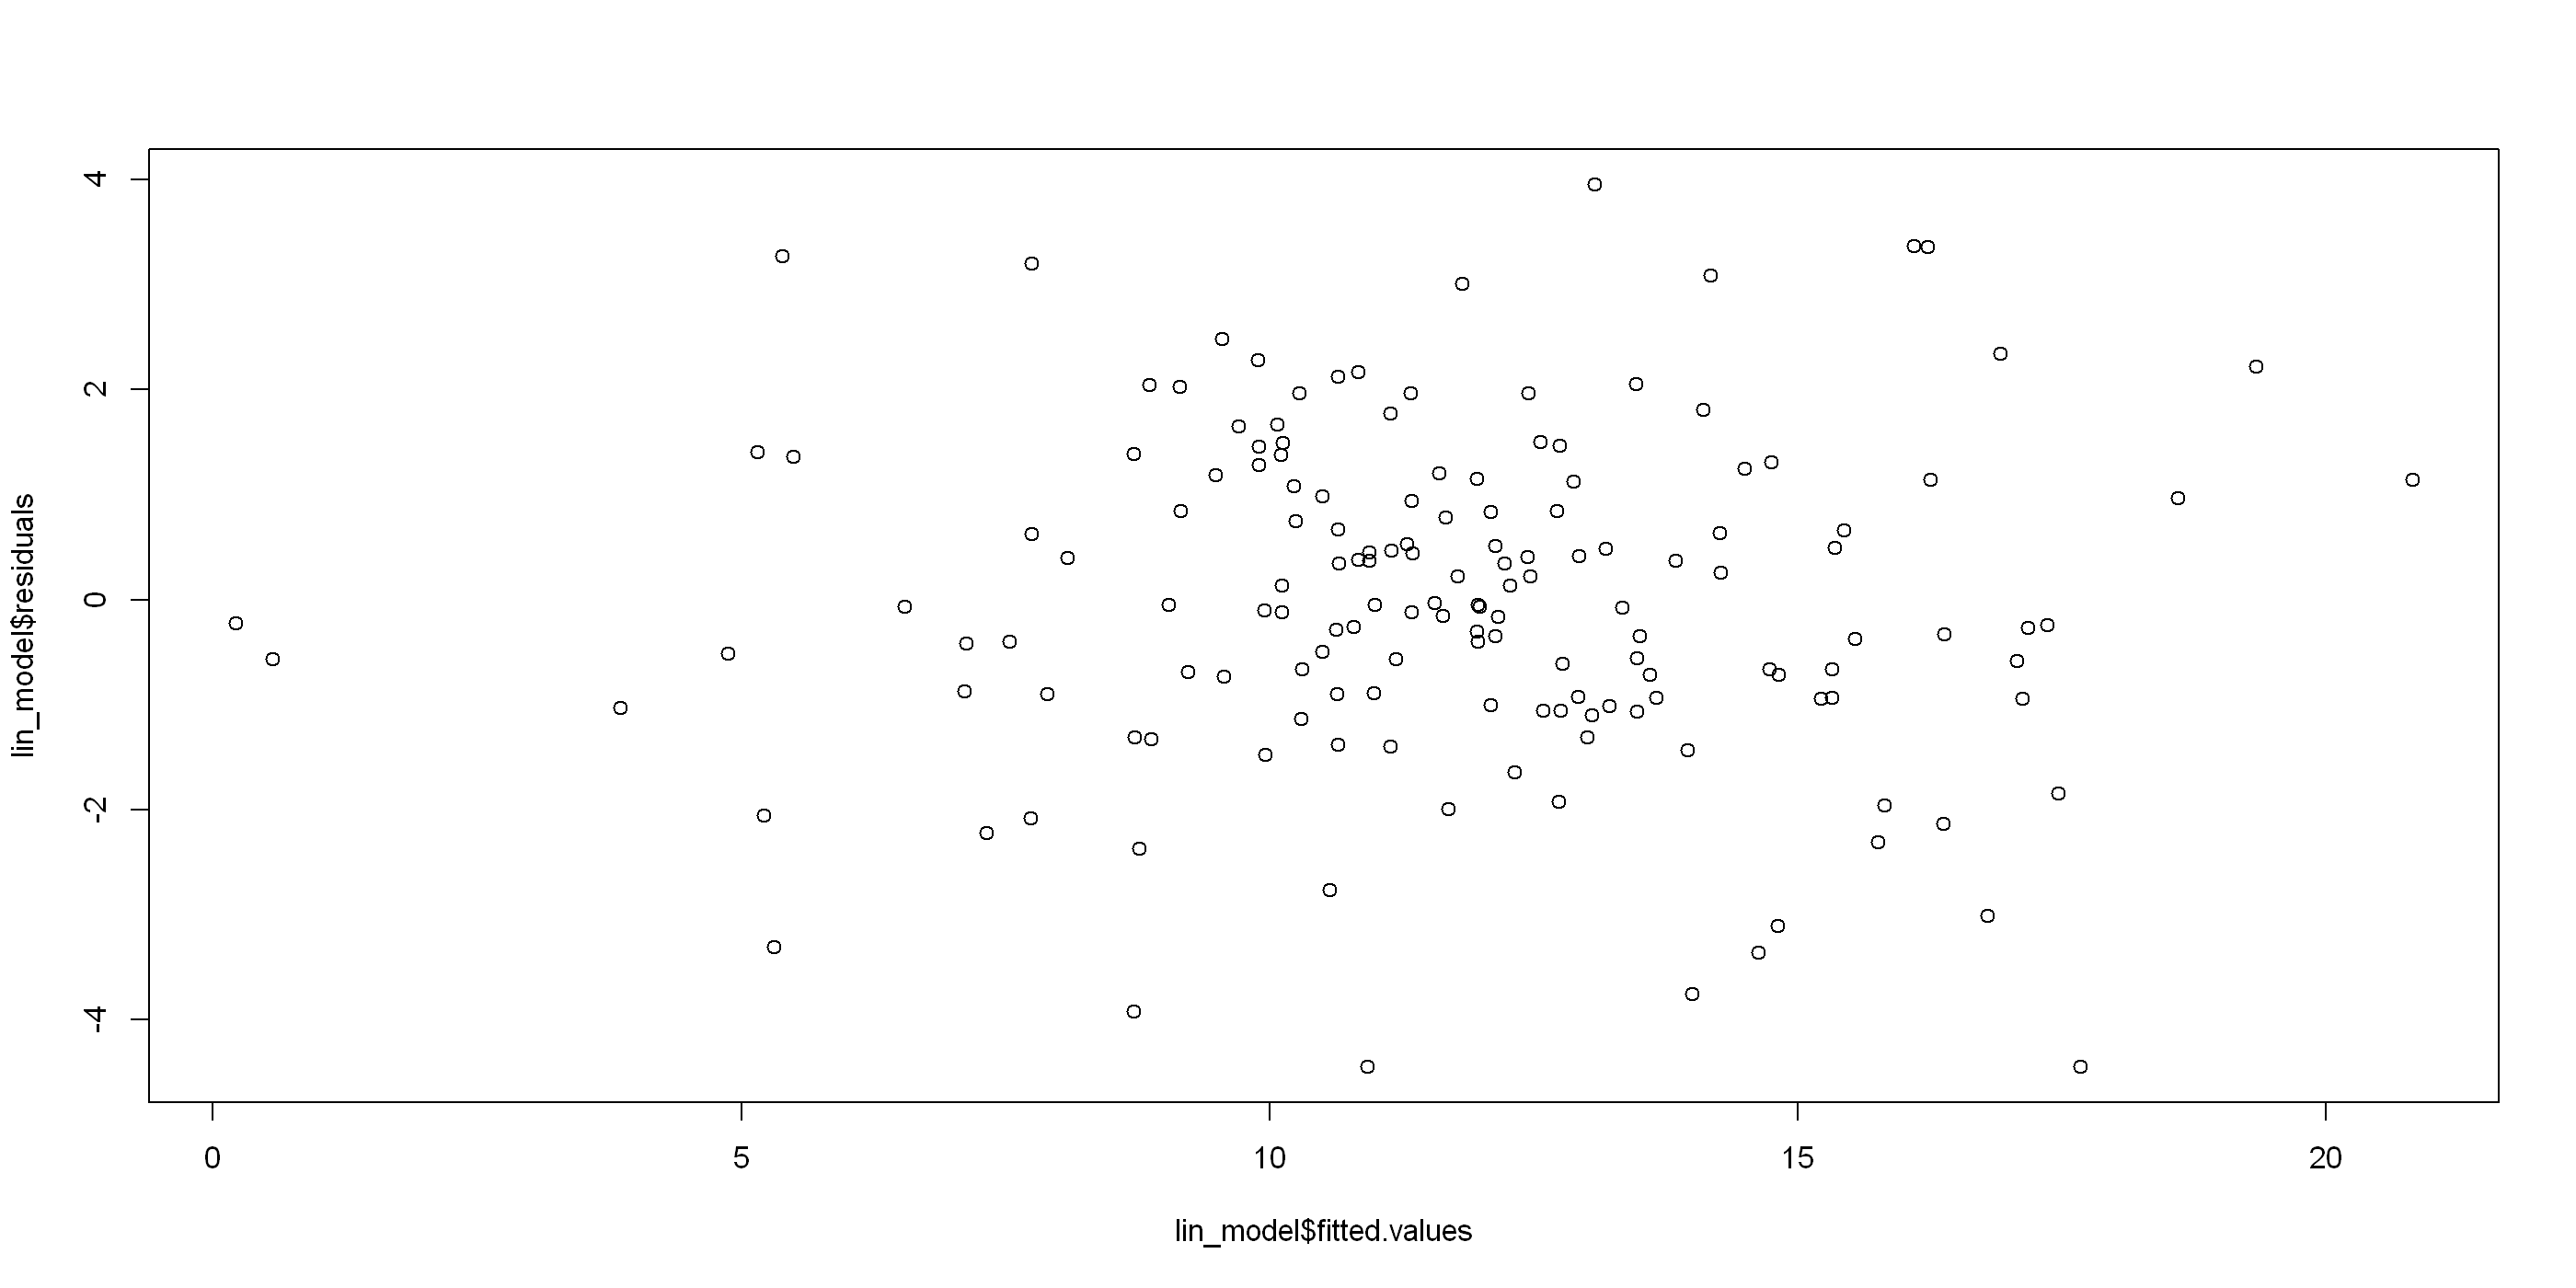

In [43]:
plot(lin_model$fitted.values, lin_model$residuals)

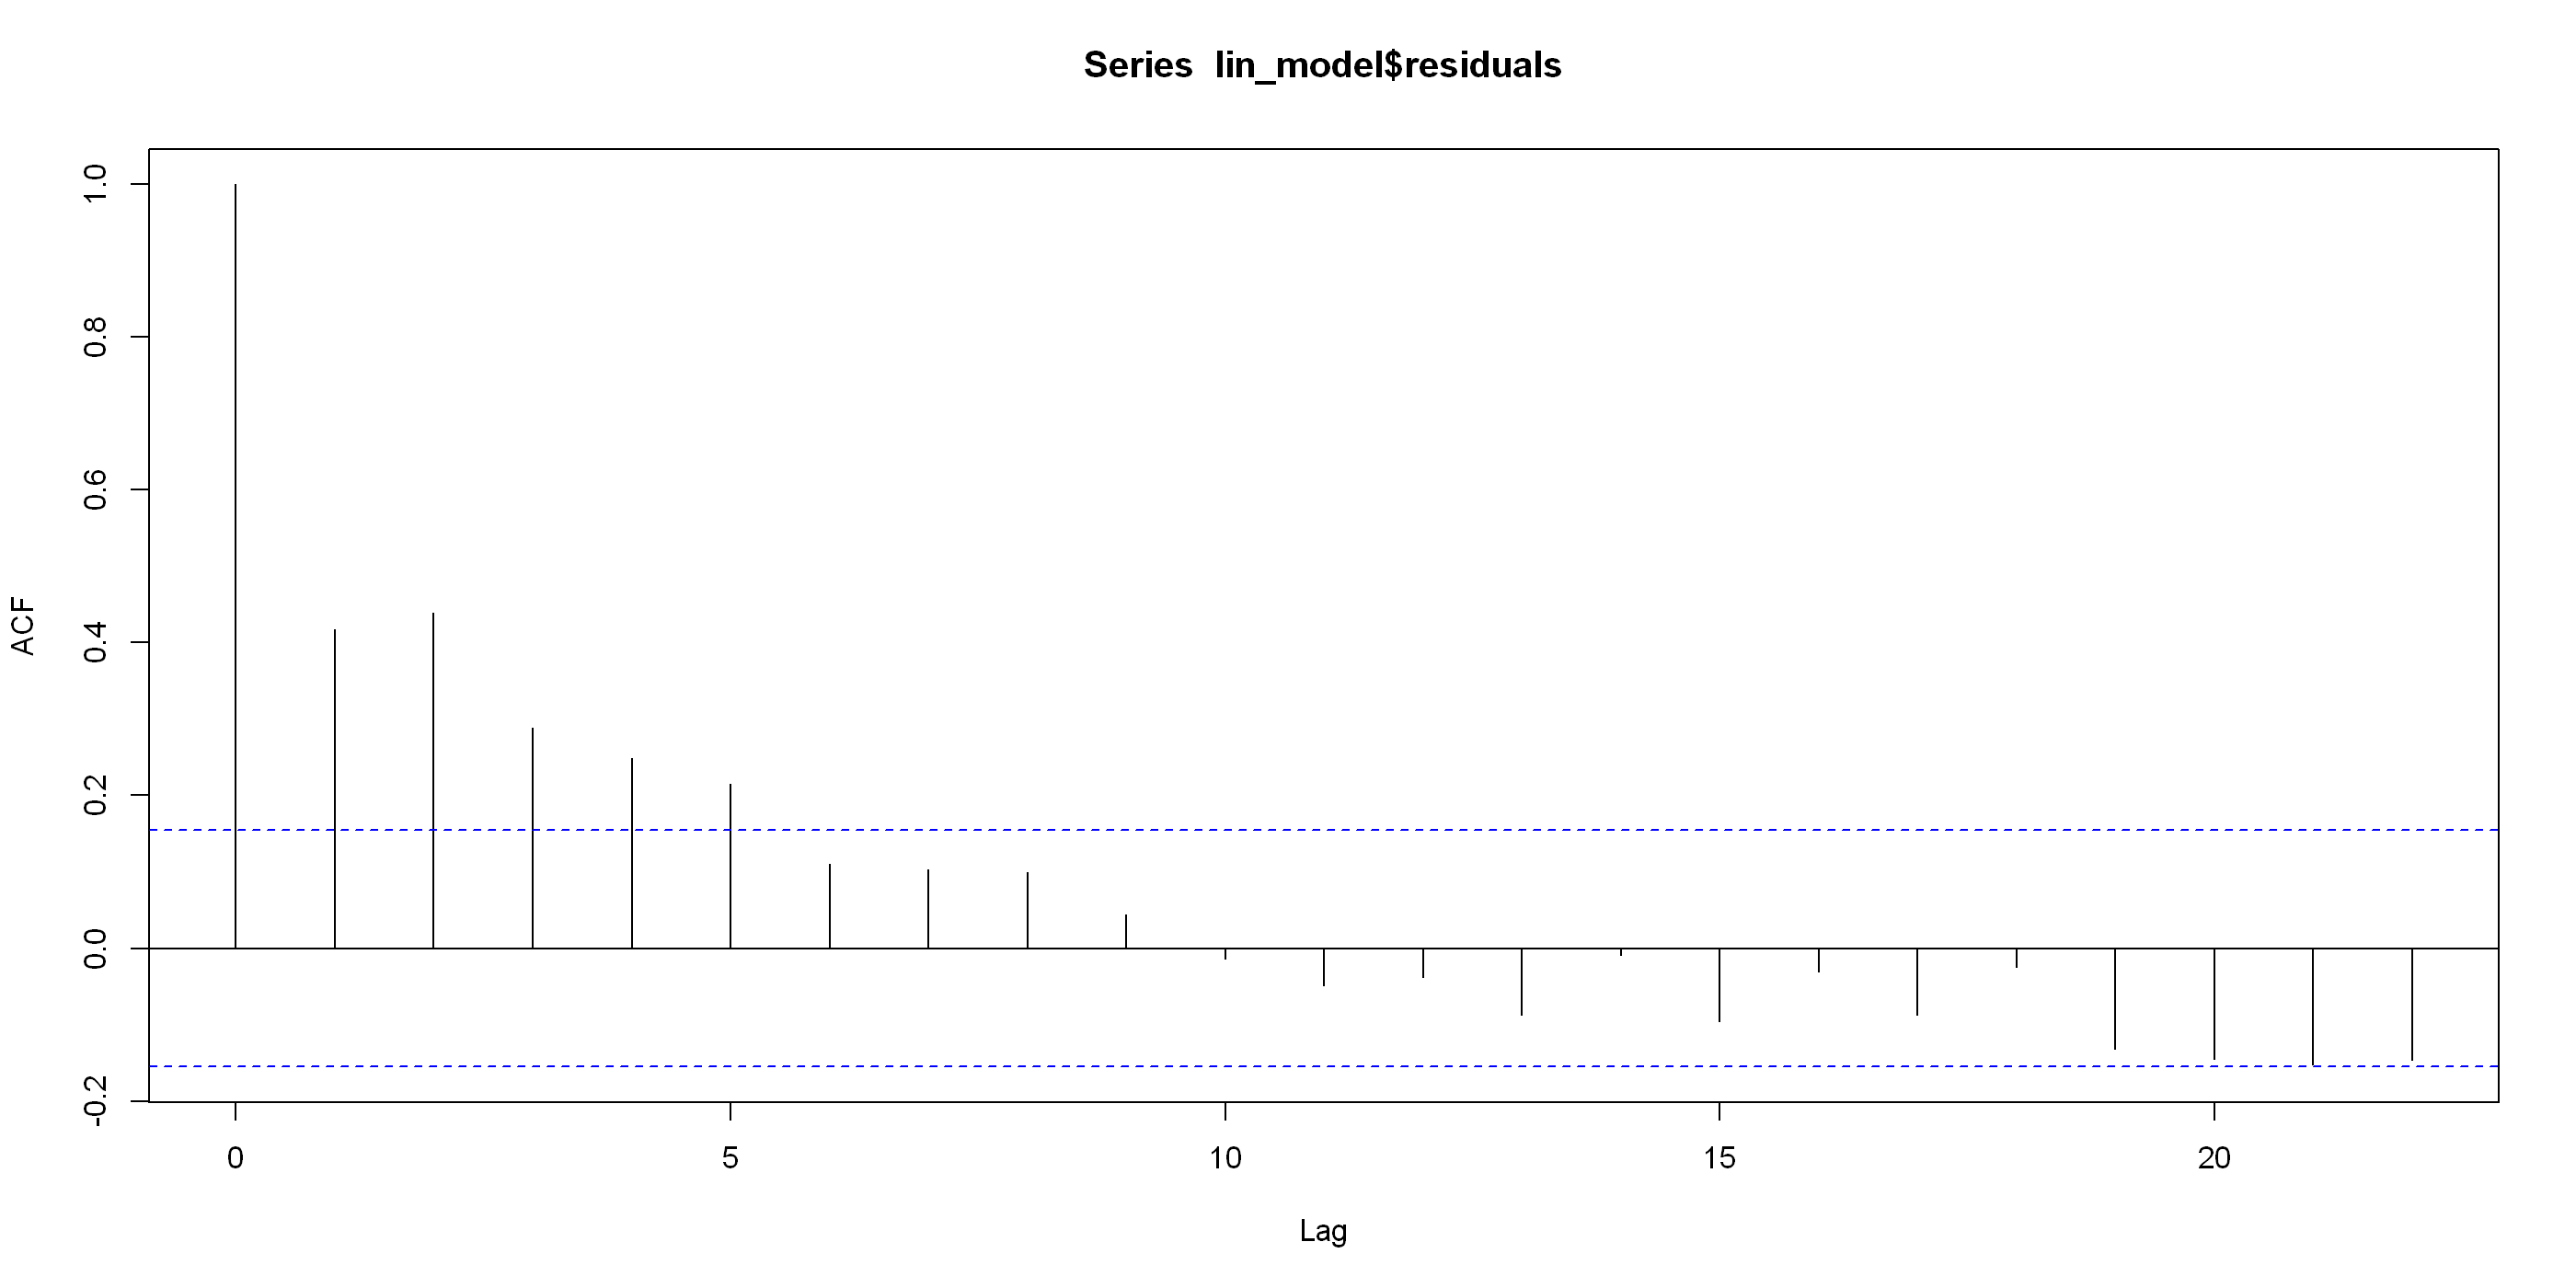

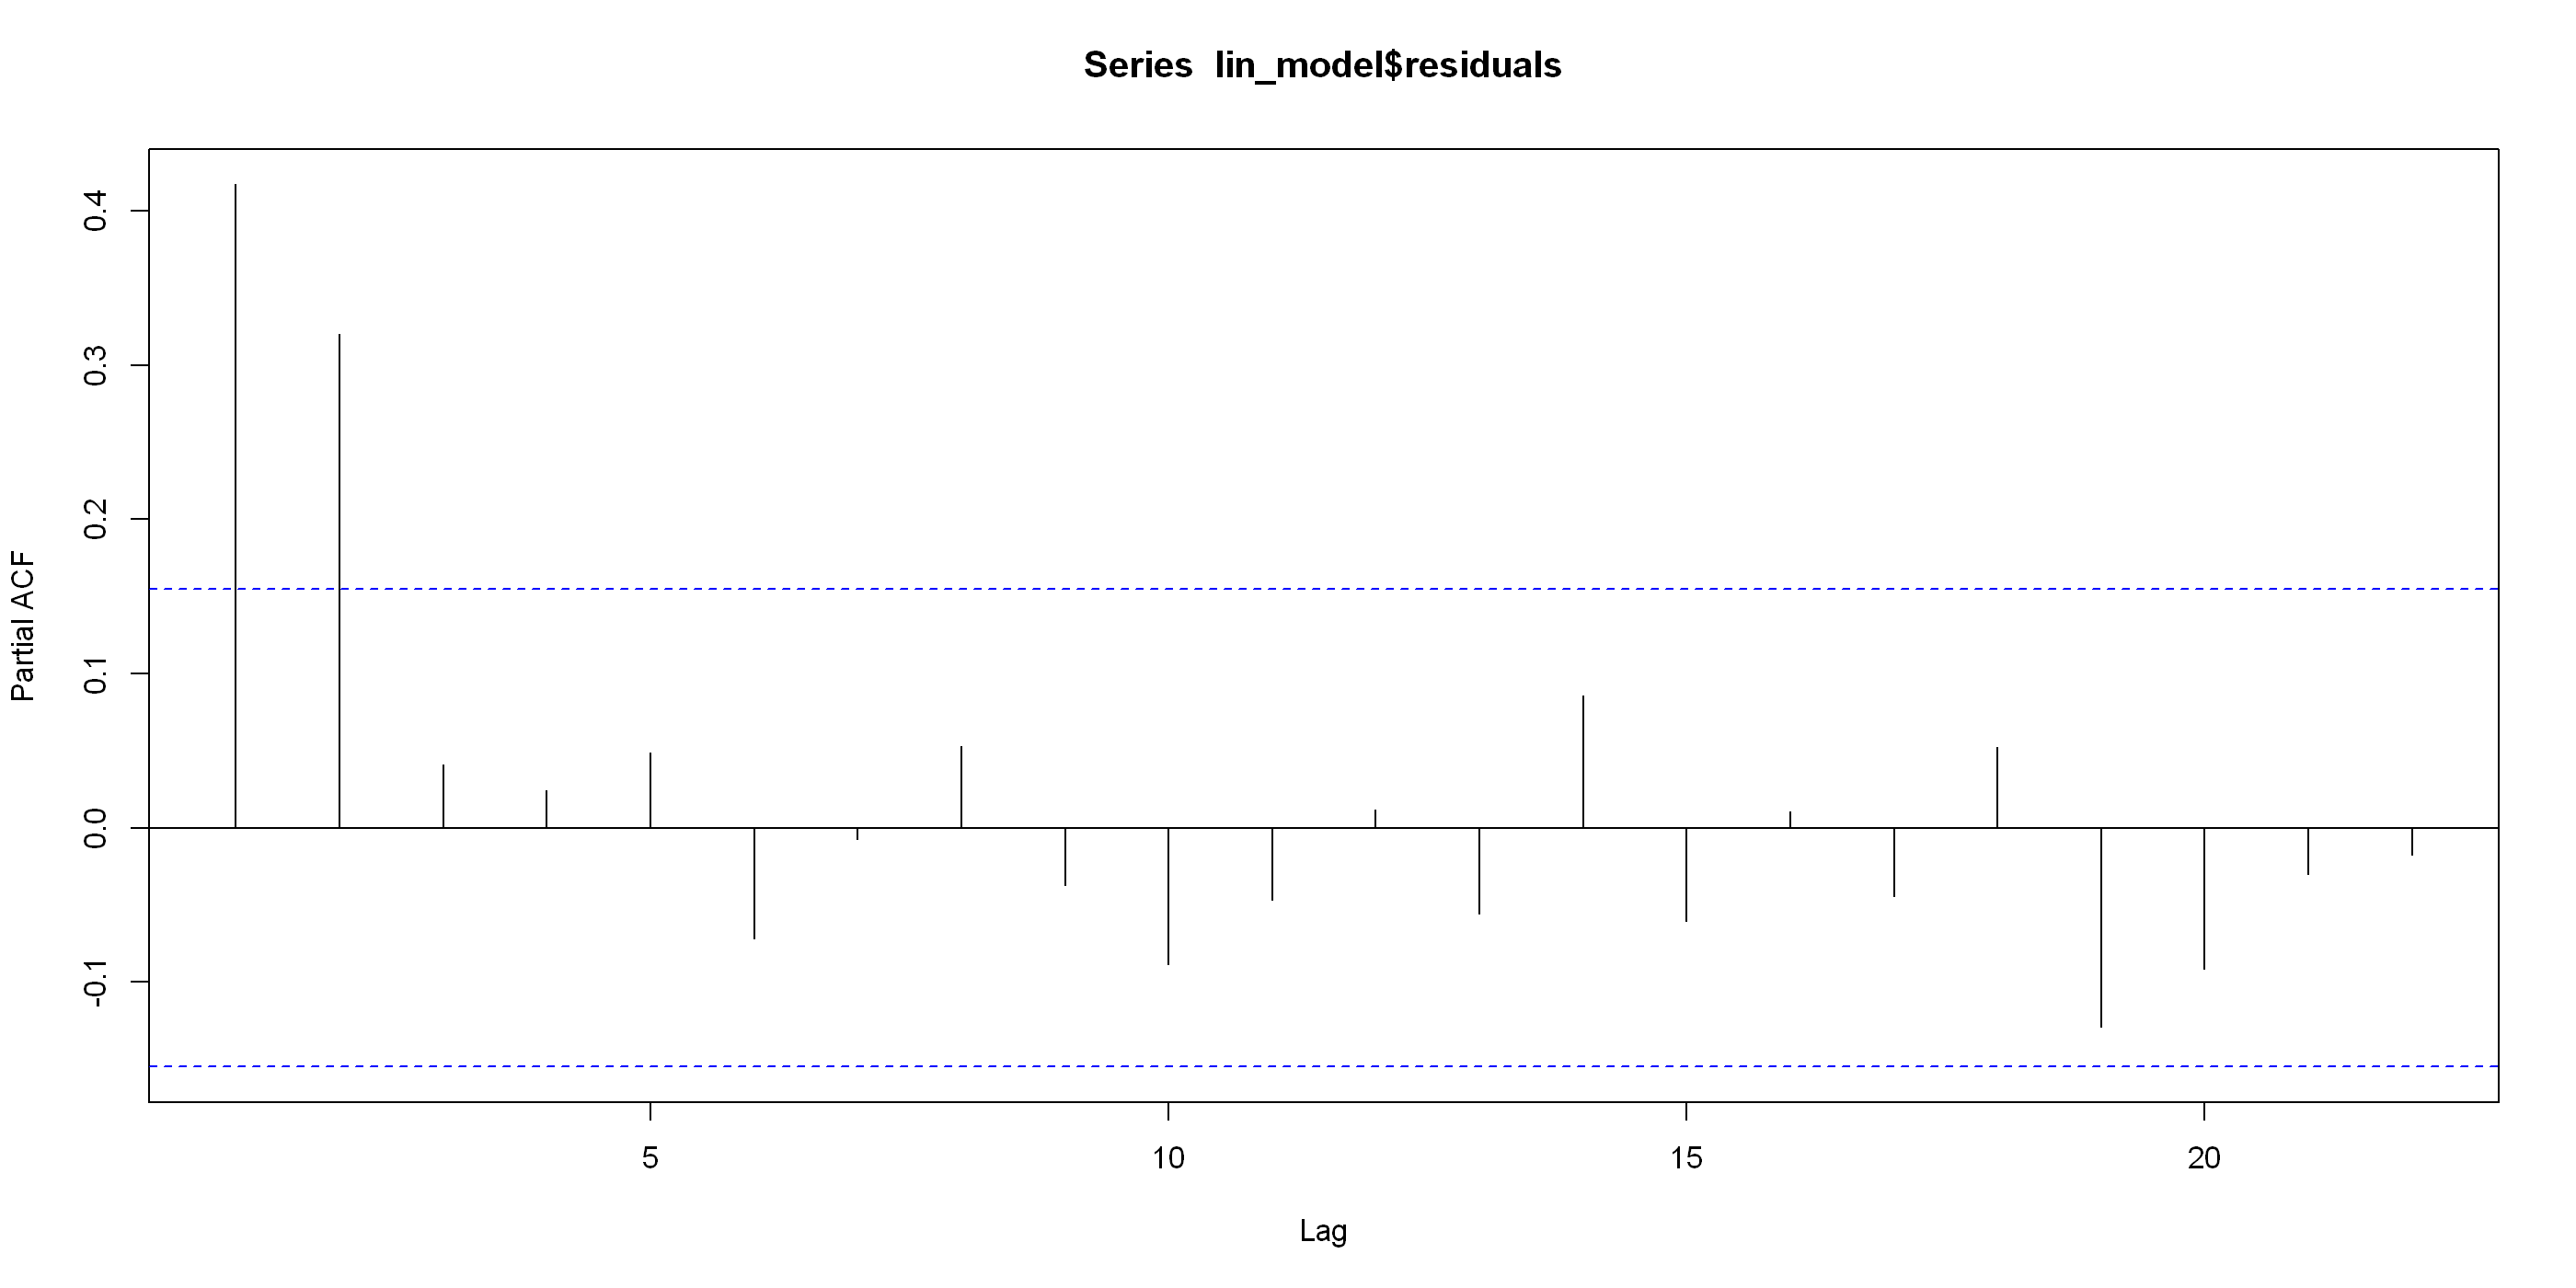

In [44]:
acf(lin_model$residuals)
pacf(lin_model$residuals)

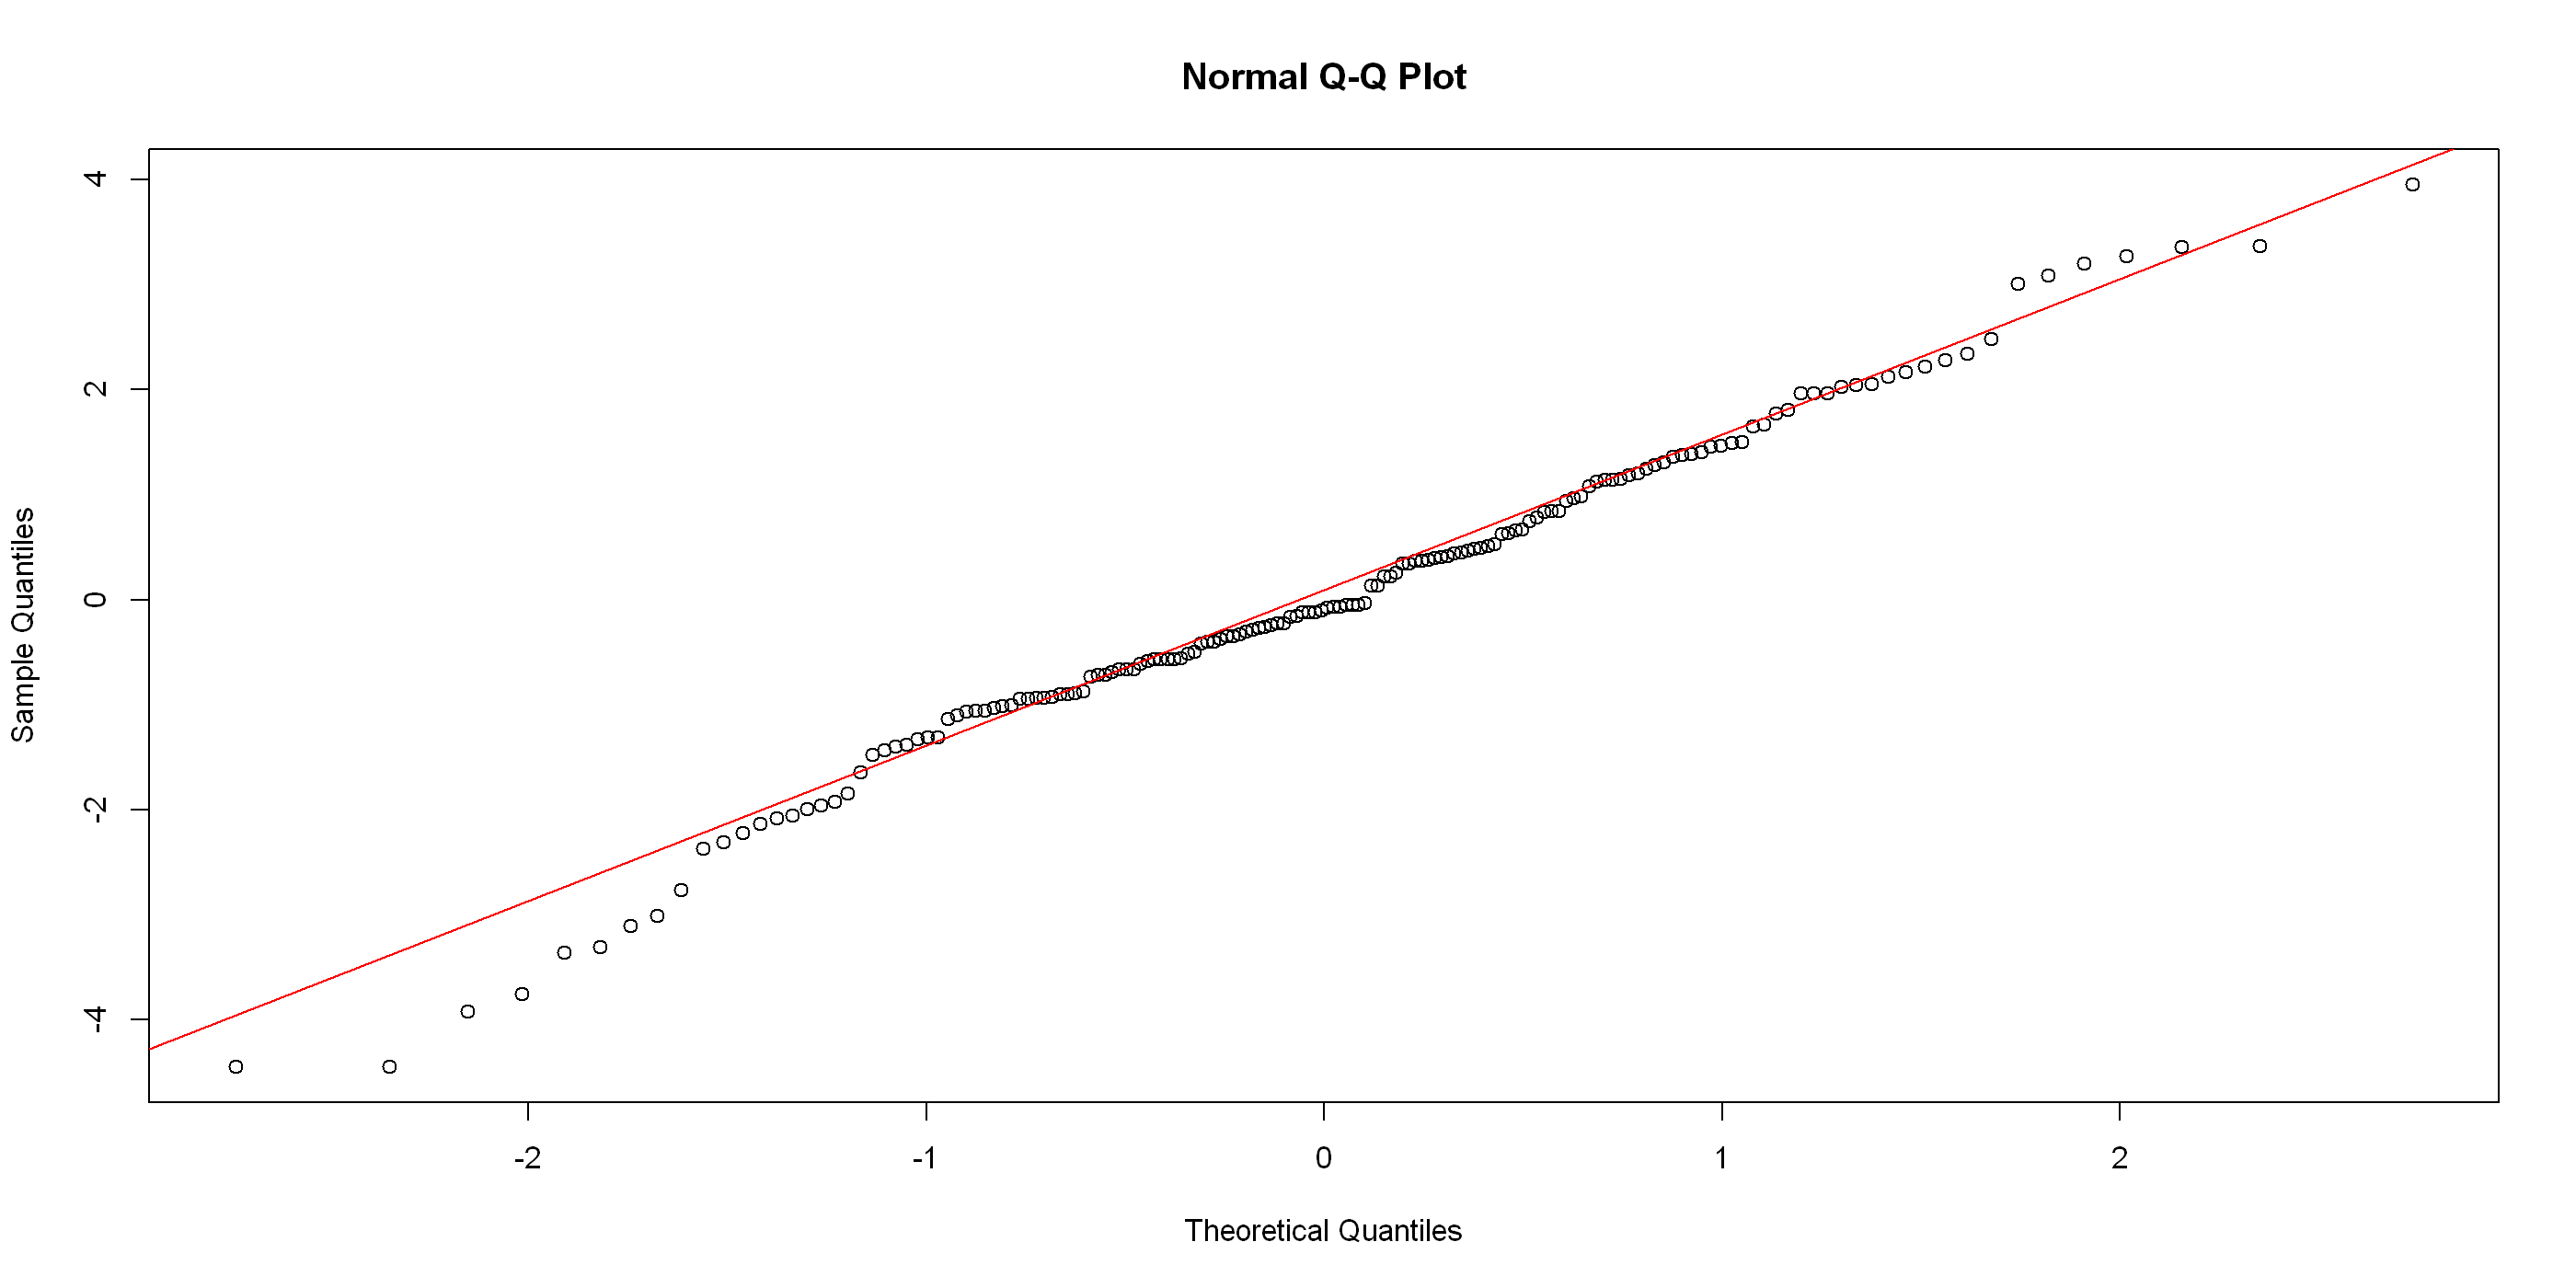

In [45]:
qqnorm(y = lin_model$residuals)
qqline(y = lin_model$residuals,col="red")

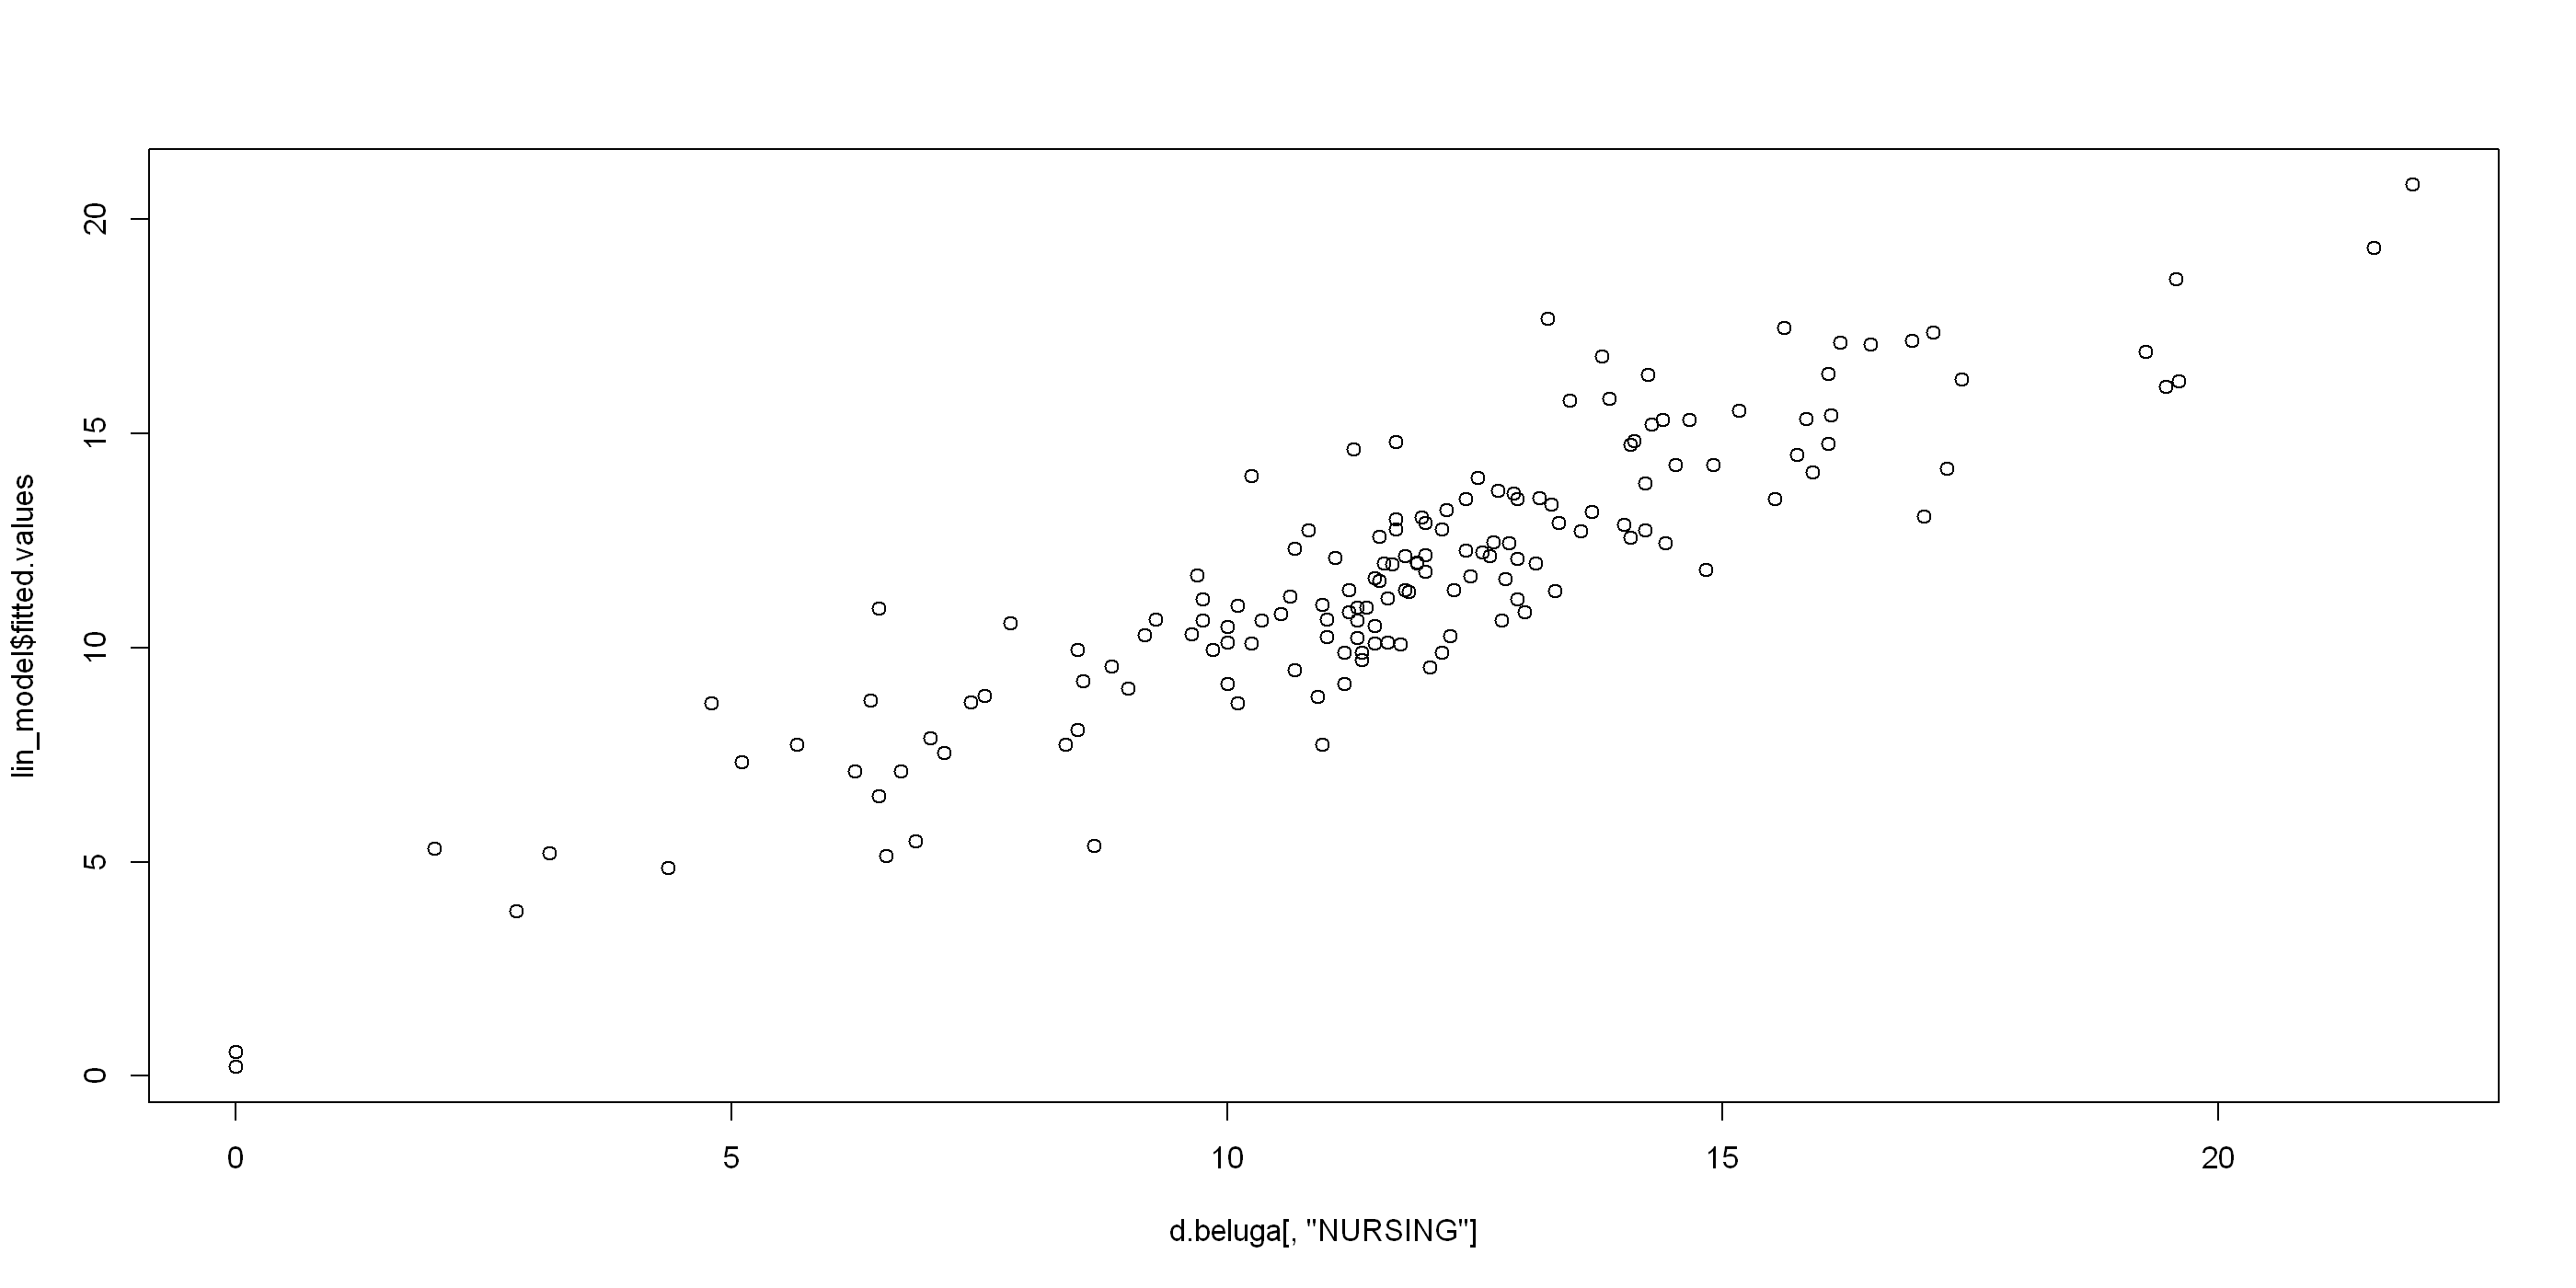

In [46]:
plot(d.beluga[,"NURSING"], lin_model$fitted.values)


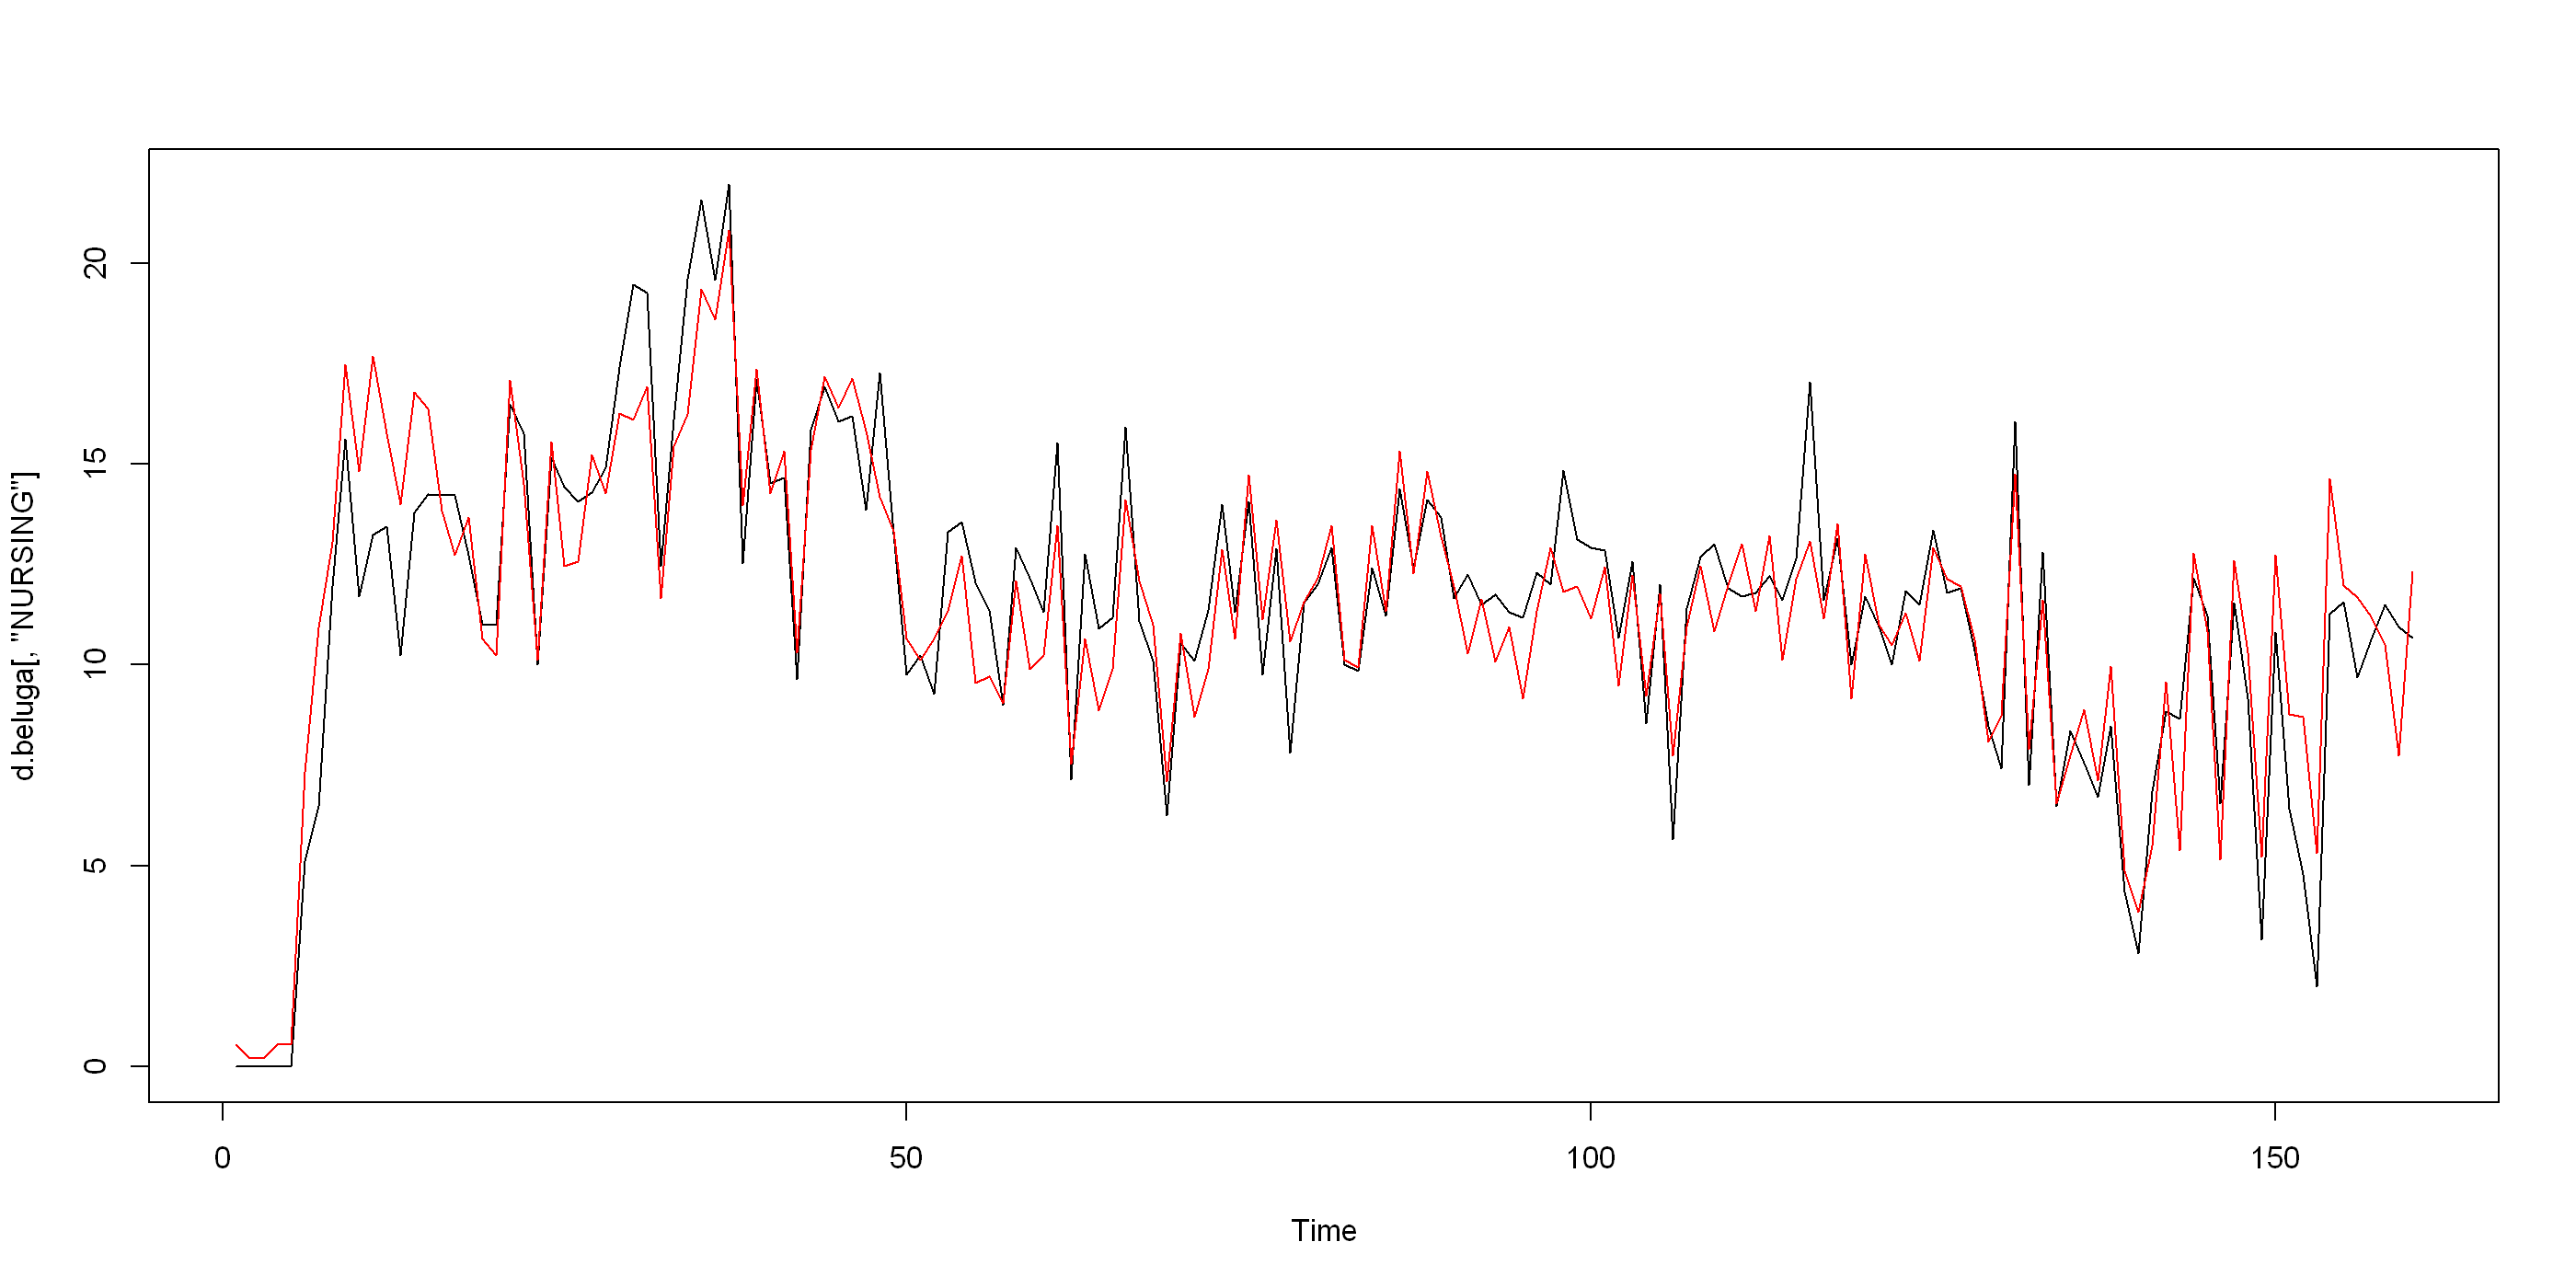

In [47]:
plot(d.beluga[,"NURSING"])
lines(lin_model$fitted.values,col="red")


In short, there is a no clear linear structure of the residuals, however the serial correlation is clear, hence the linear model does not suffice alone, eventhough the model fit per say appears to be fine. And we also note the residuals are not perfectly fit the quantiles of the normal distribution.

#### b

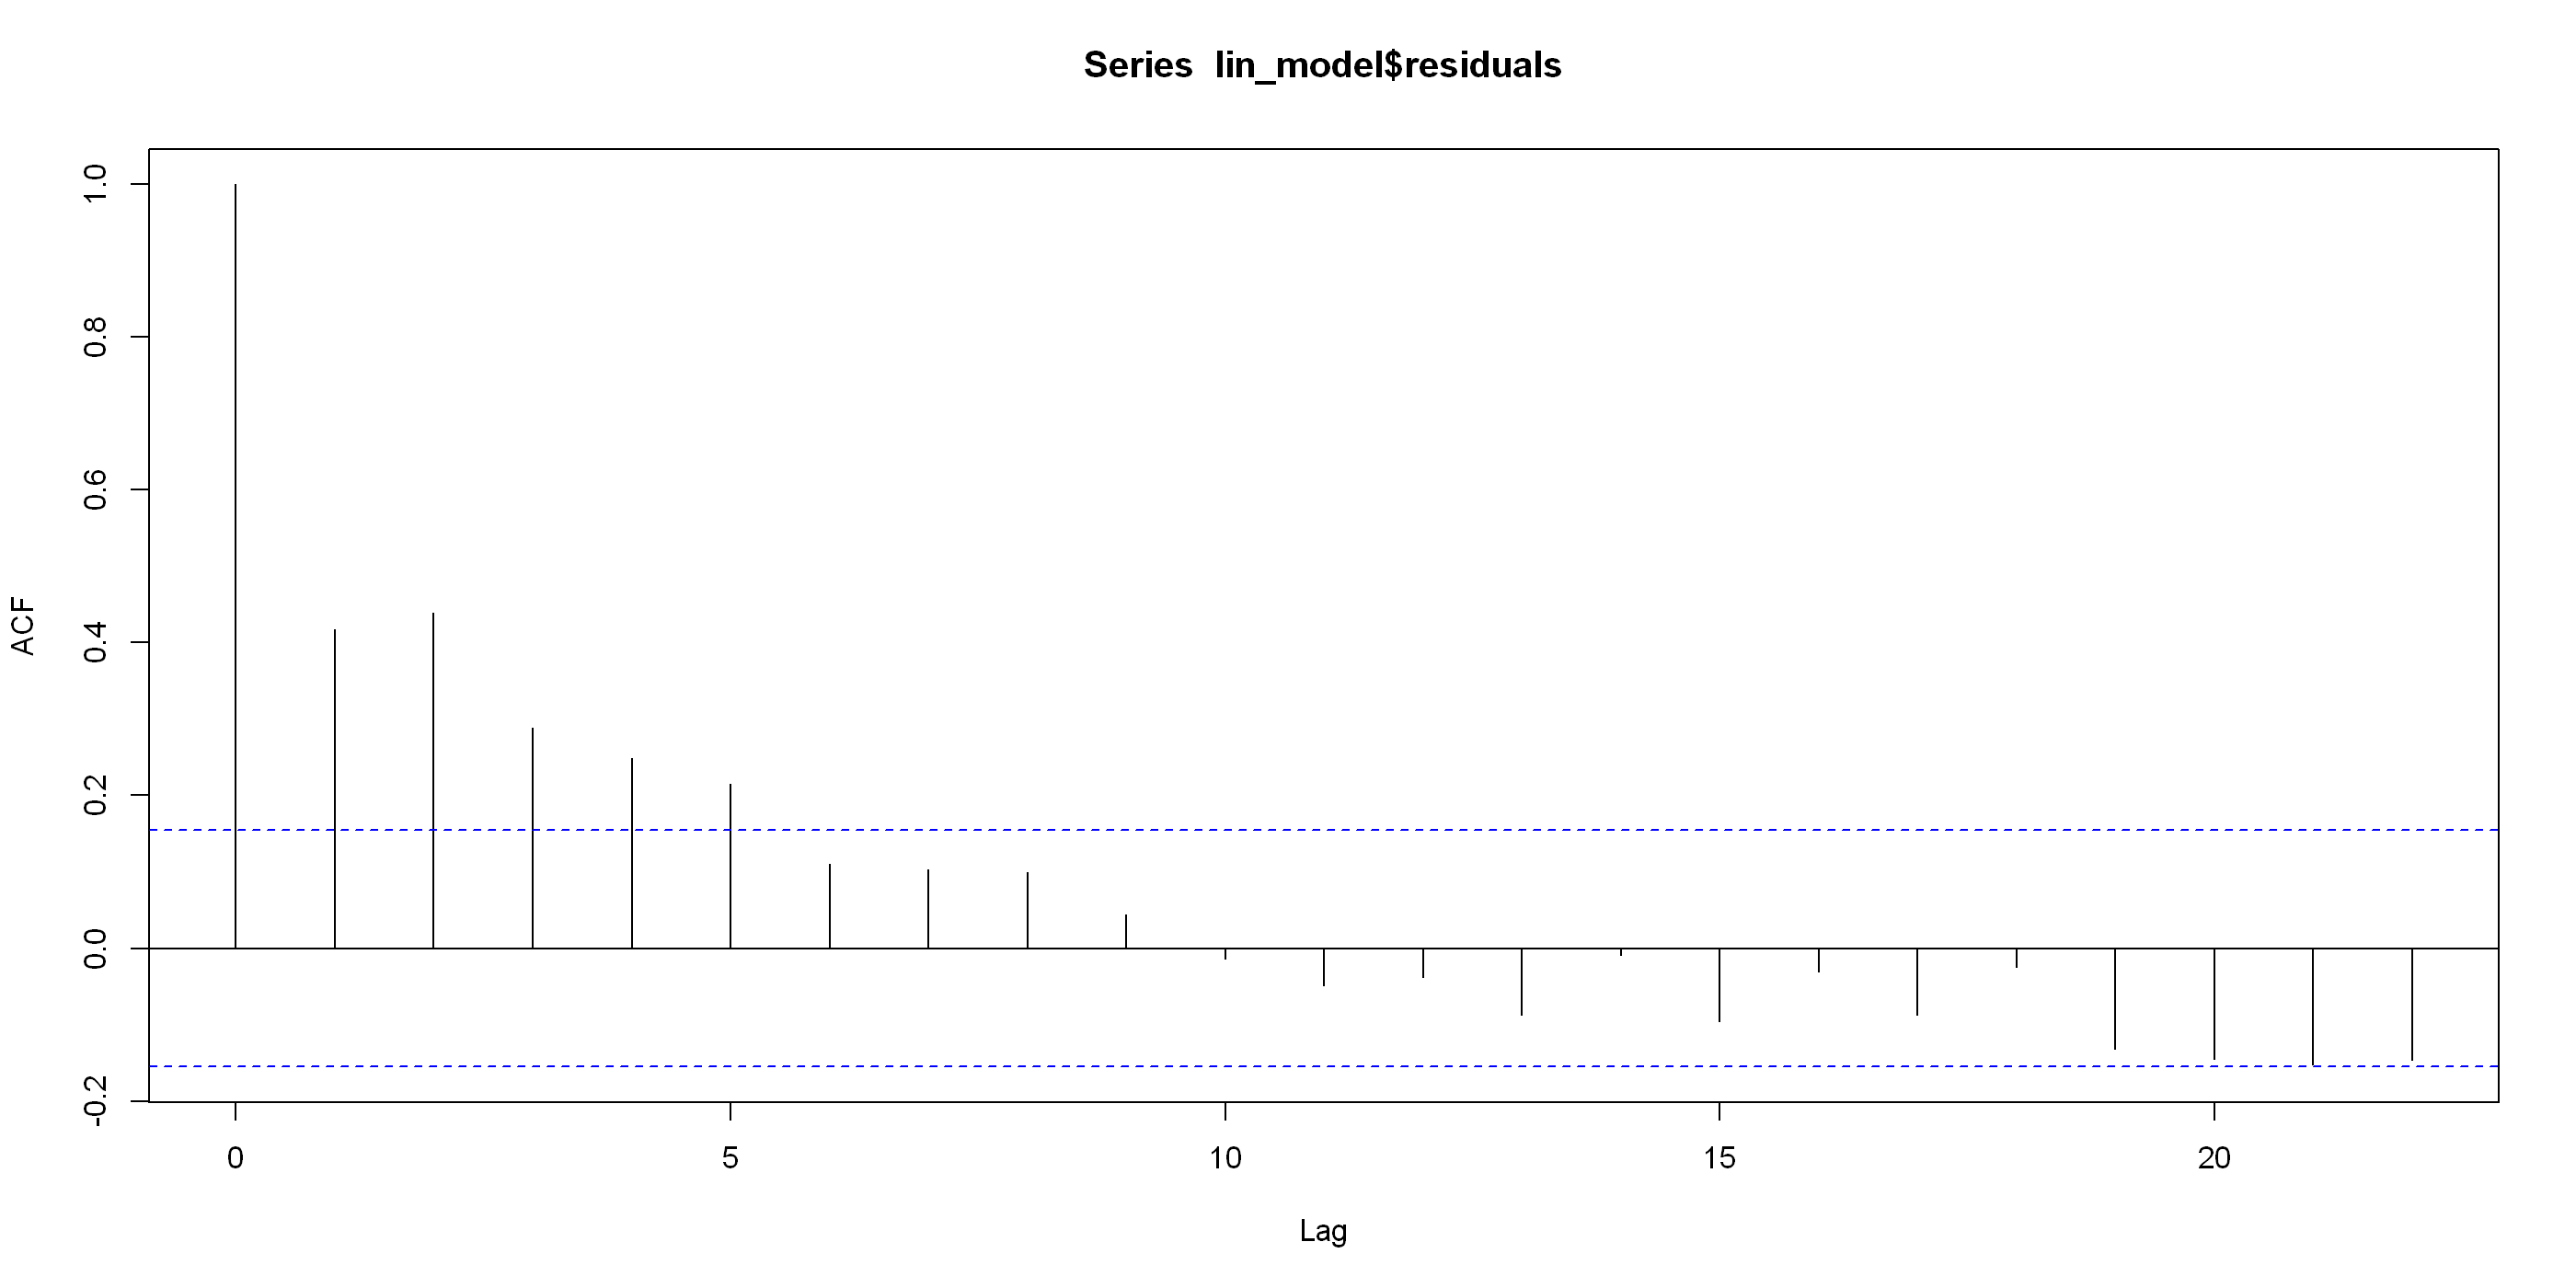

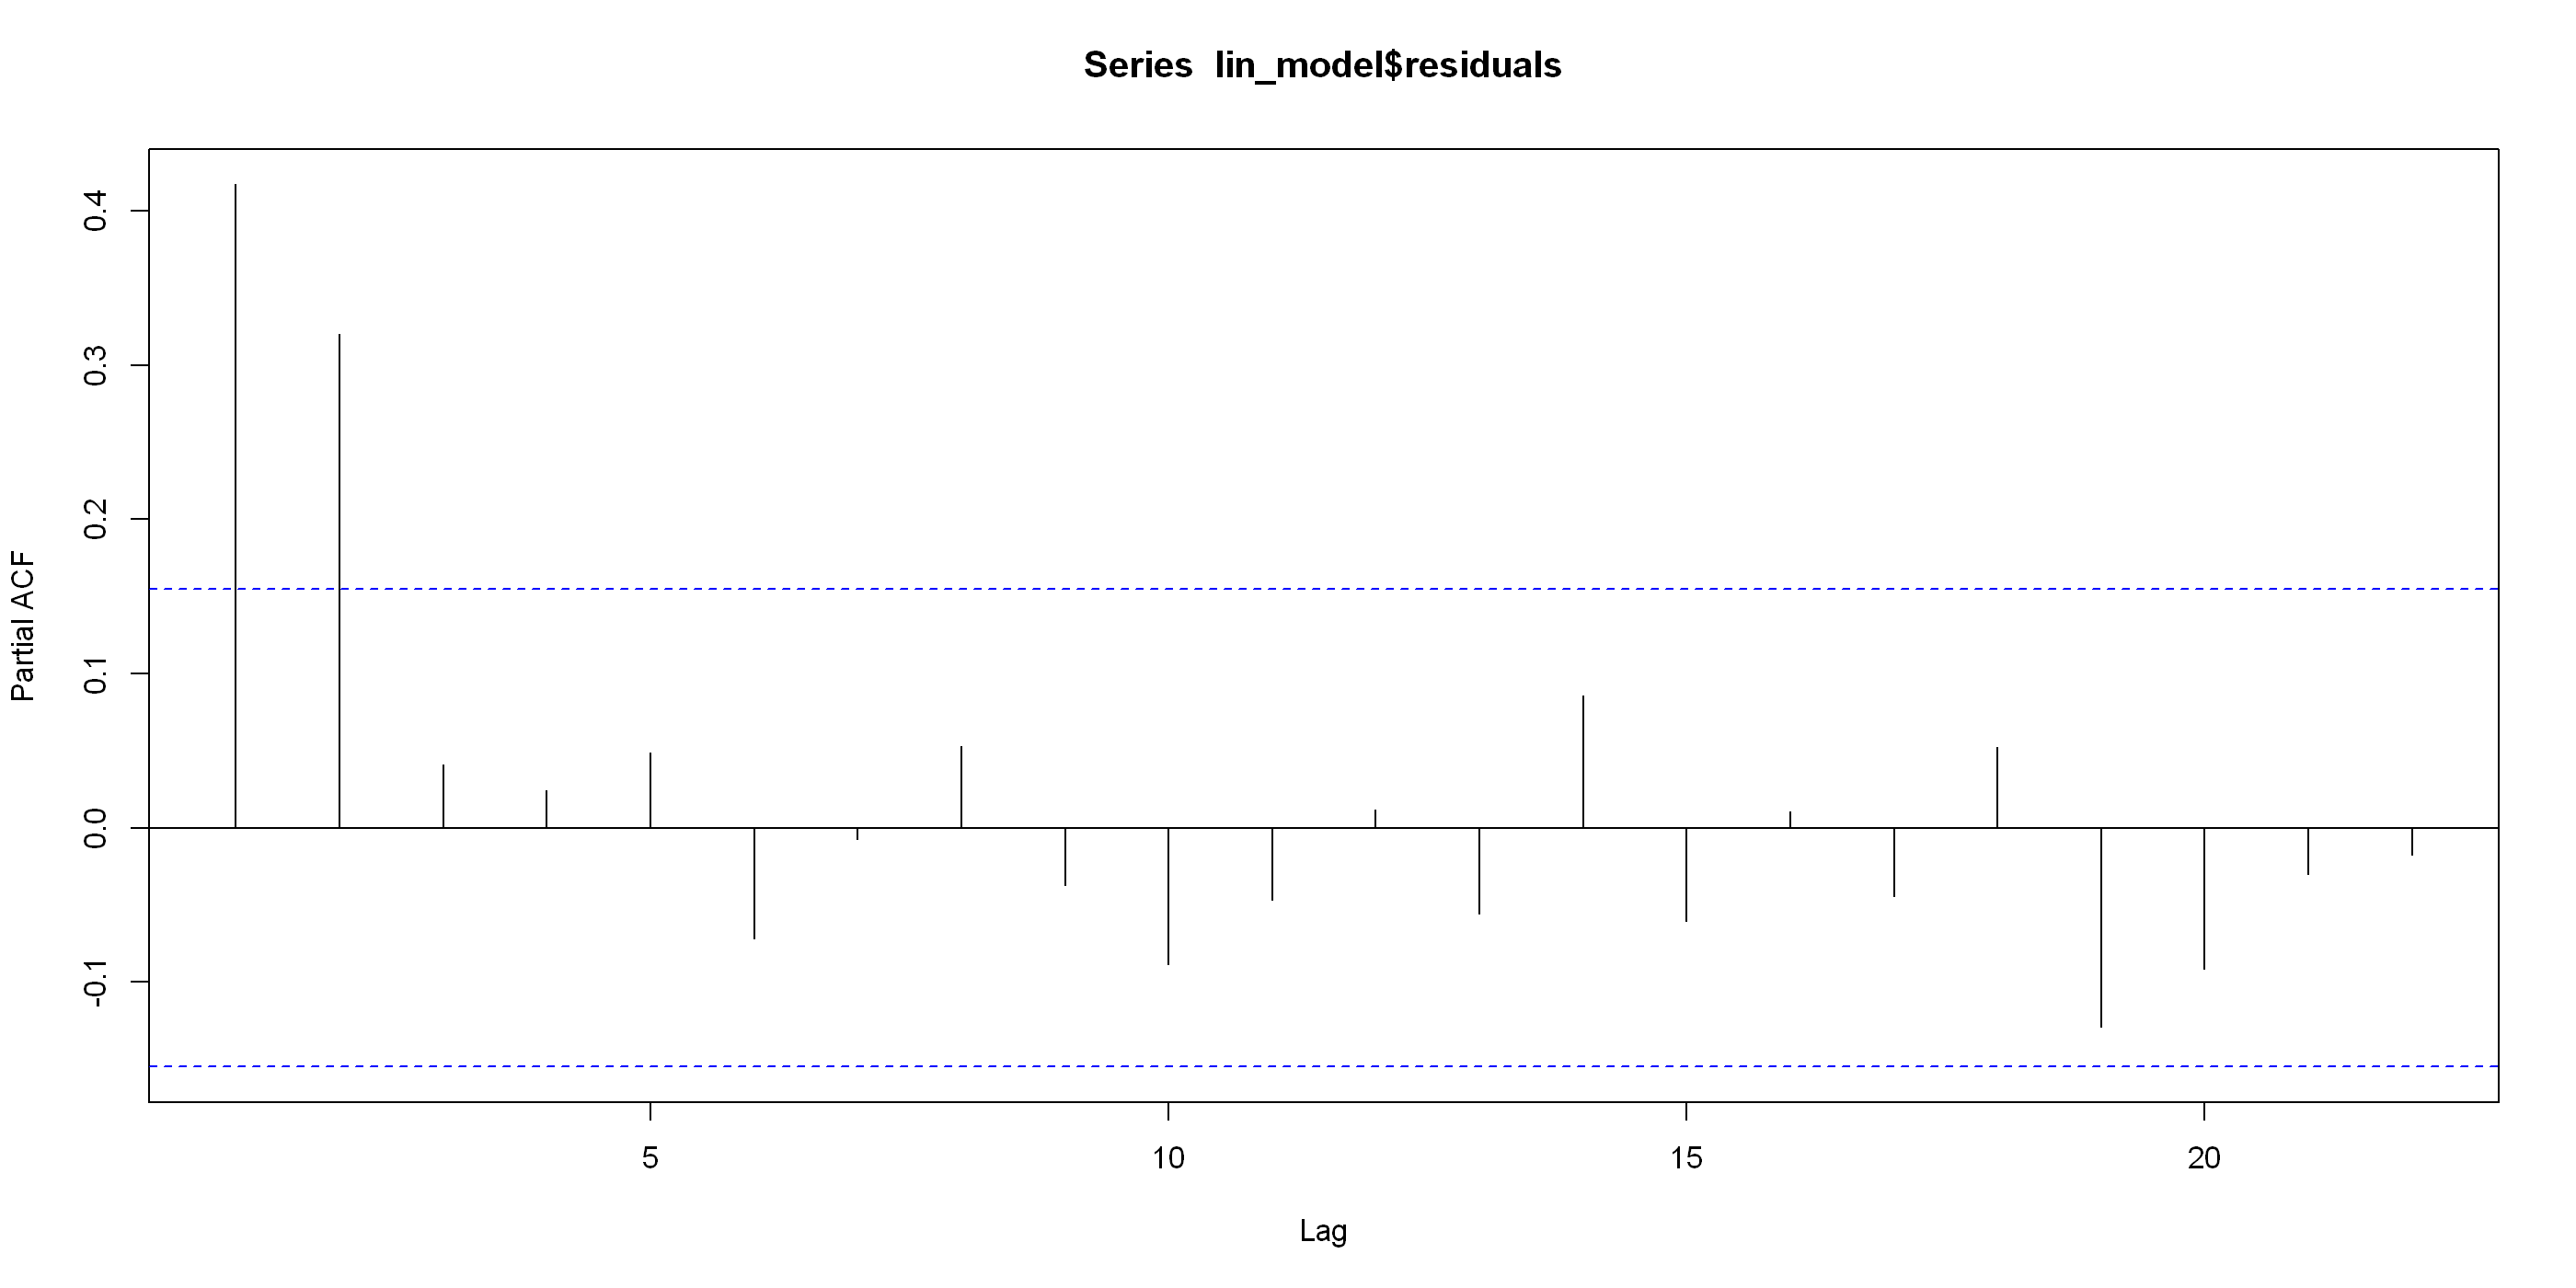

In [48]:
acf(lin_model$residuals)
pacf(lin_model$residuals)


It is clear that the cutoff is at lag 2, hence $p=2$.

In [49]:
ar_model <- arima(x=lin_model$residuals,order = c(2,0,0))

In [50]:
(ar_model$coef)

ar1          ar2    intercept 
 0.275587253  0.326276143 -0.005342329

In [51]:
fitted_vals <- lin_model$residuals - ar_model$residuals

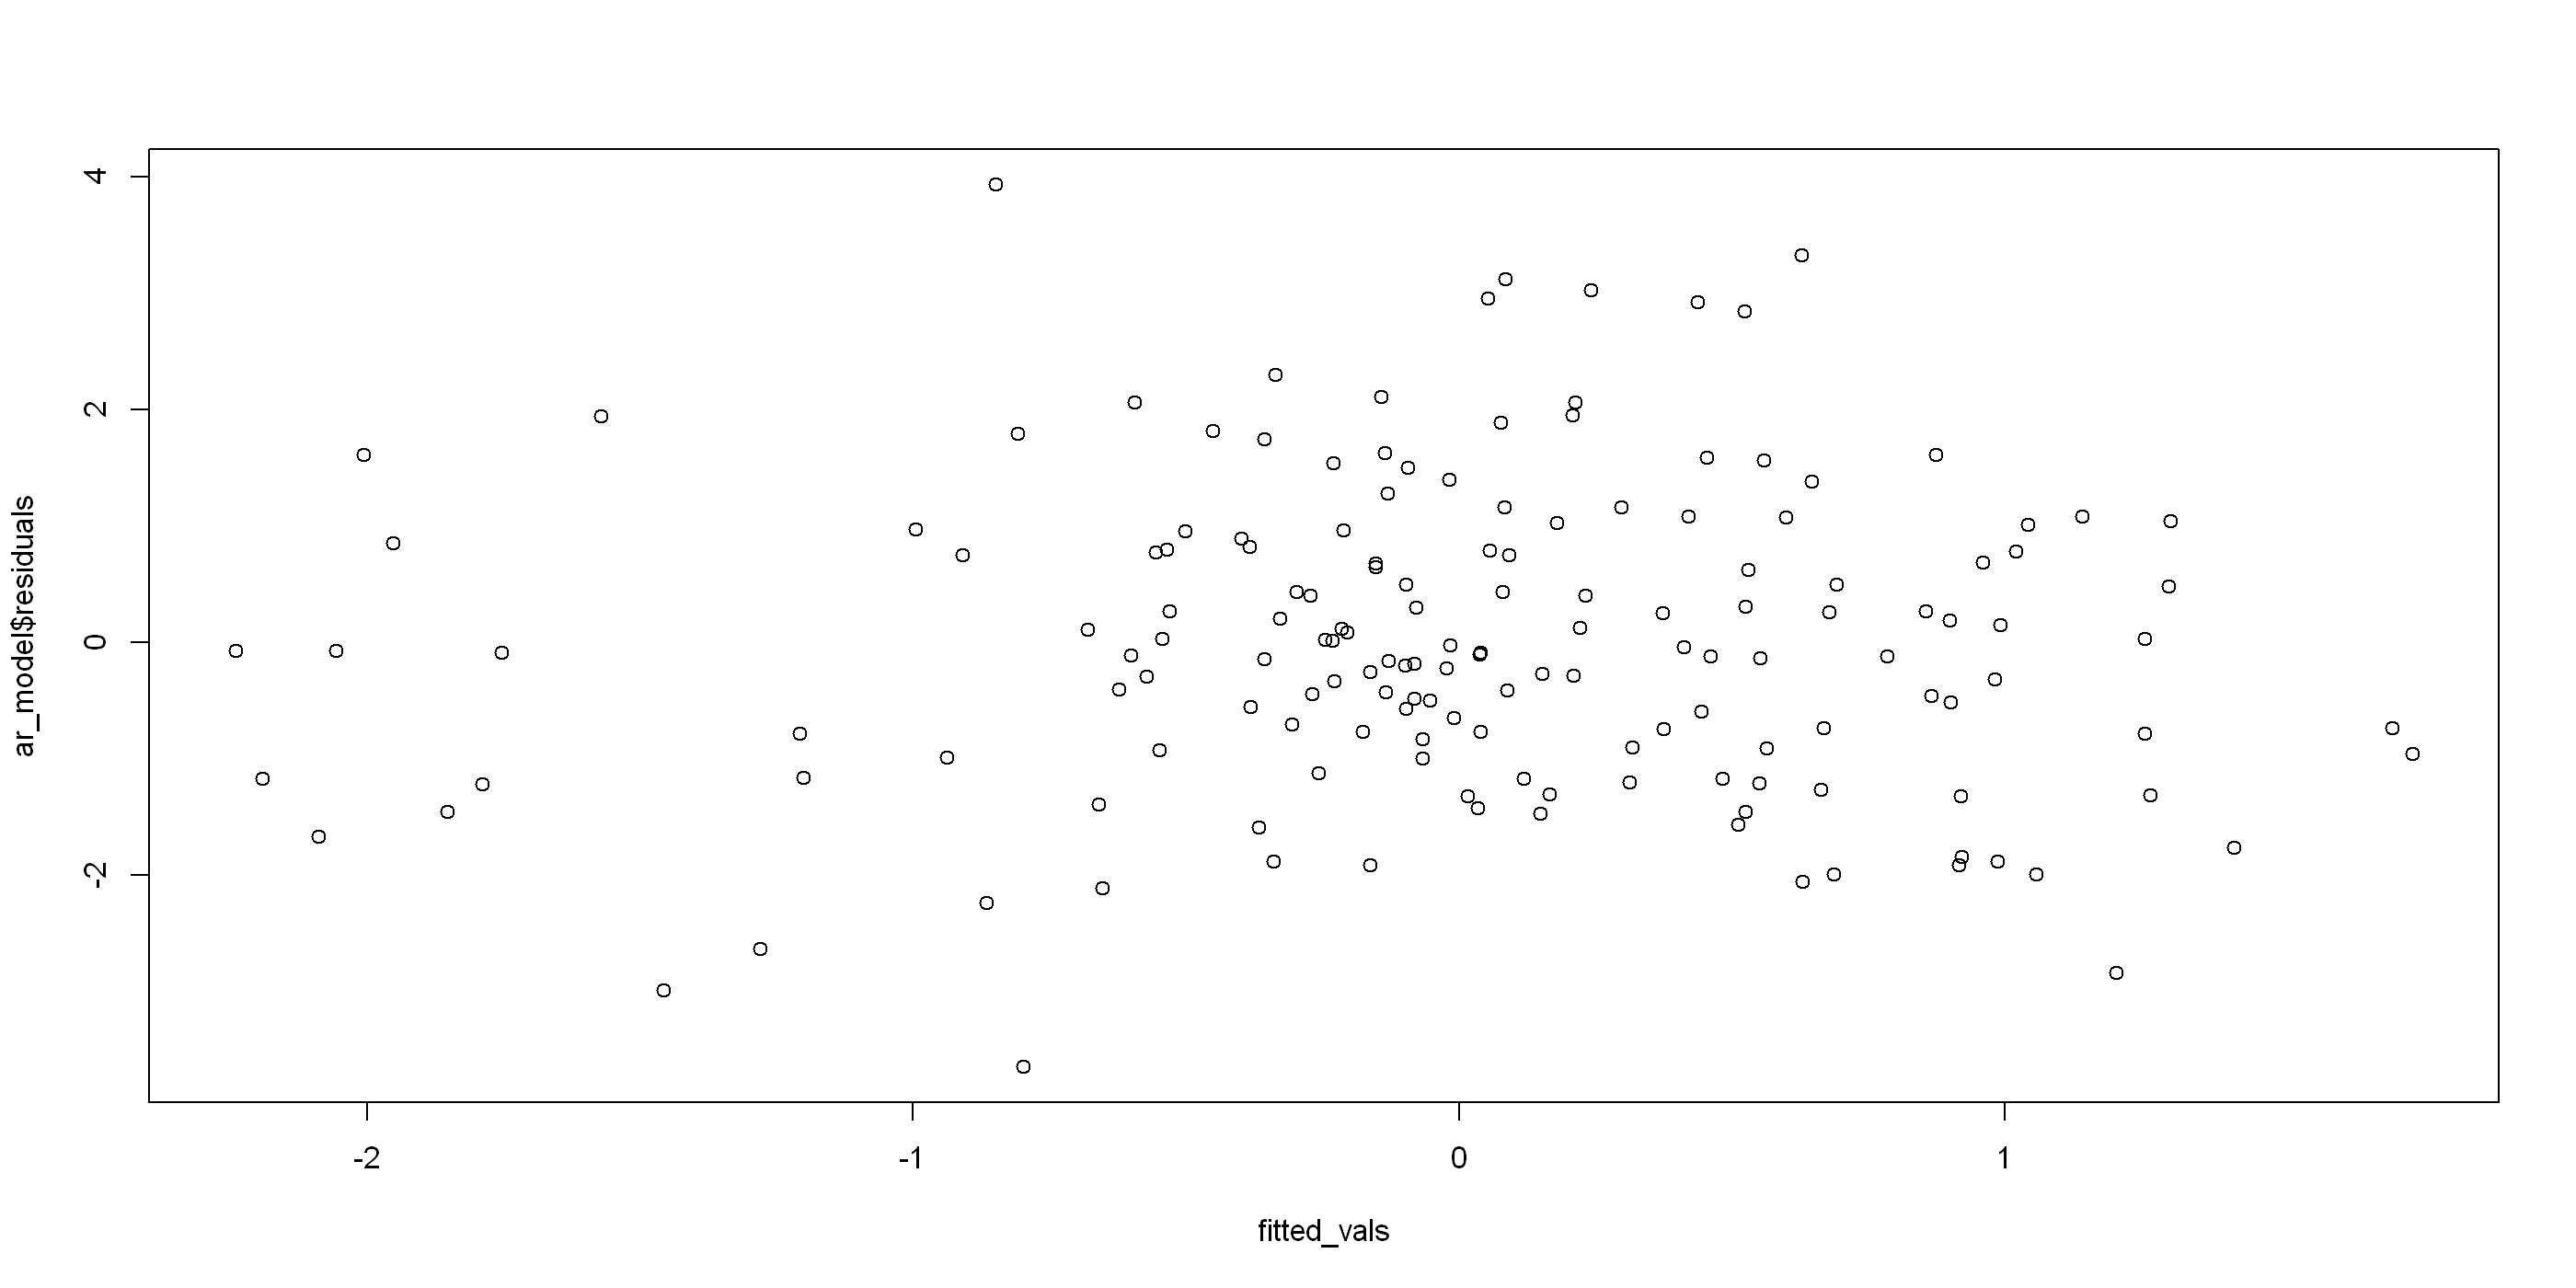

In [52]:
plot(fitted_vals,ar_model$residuals)

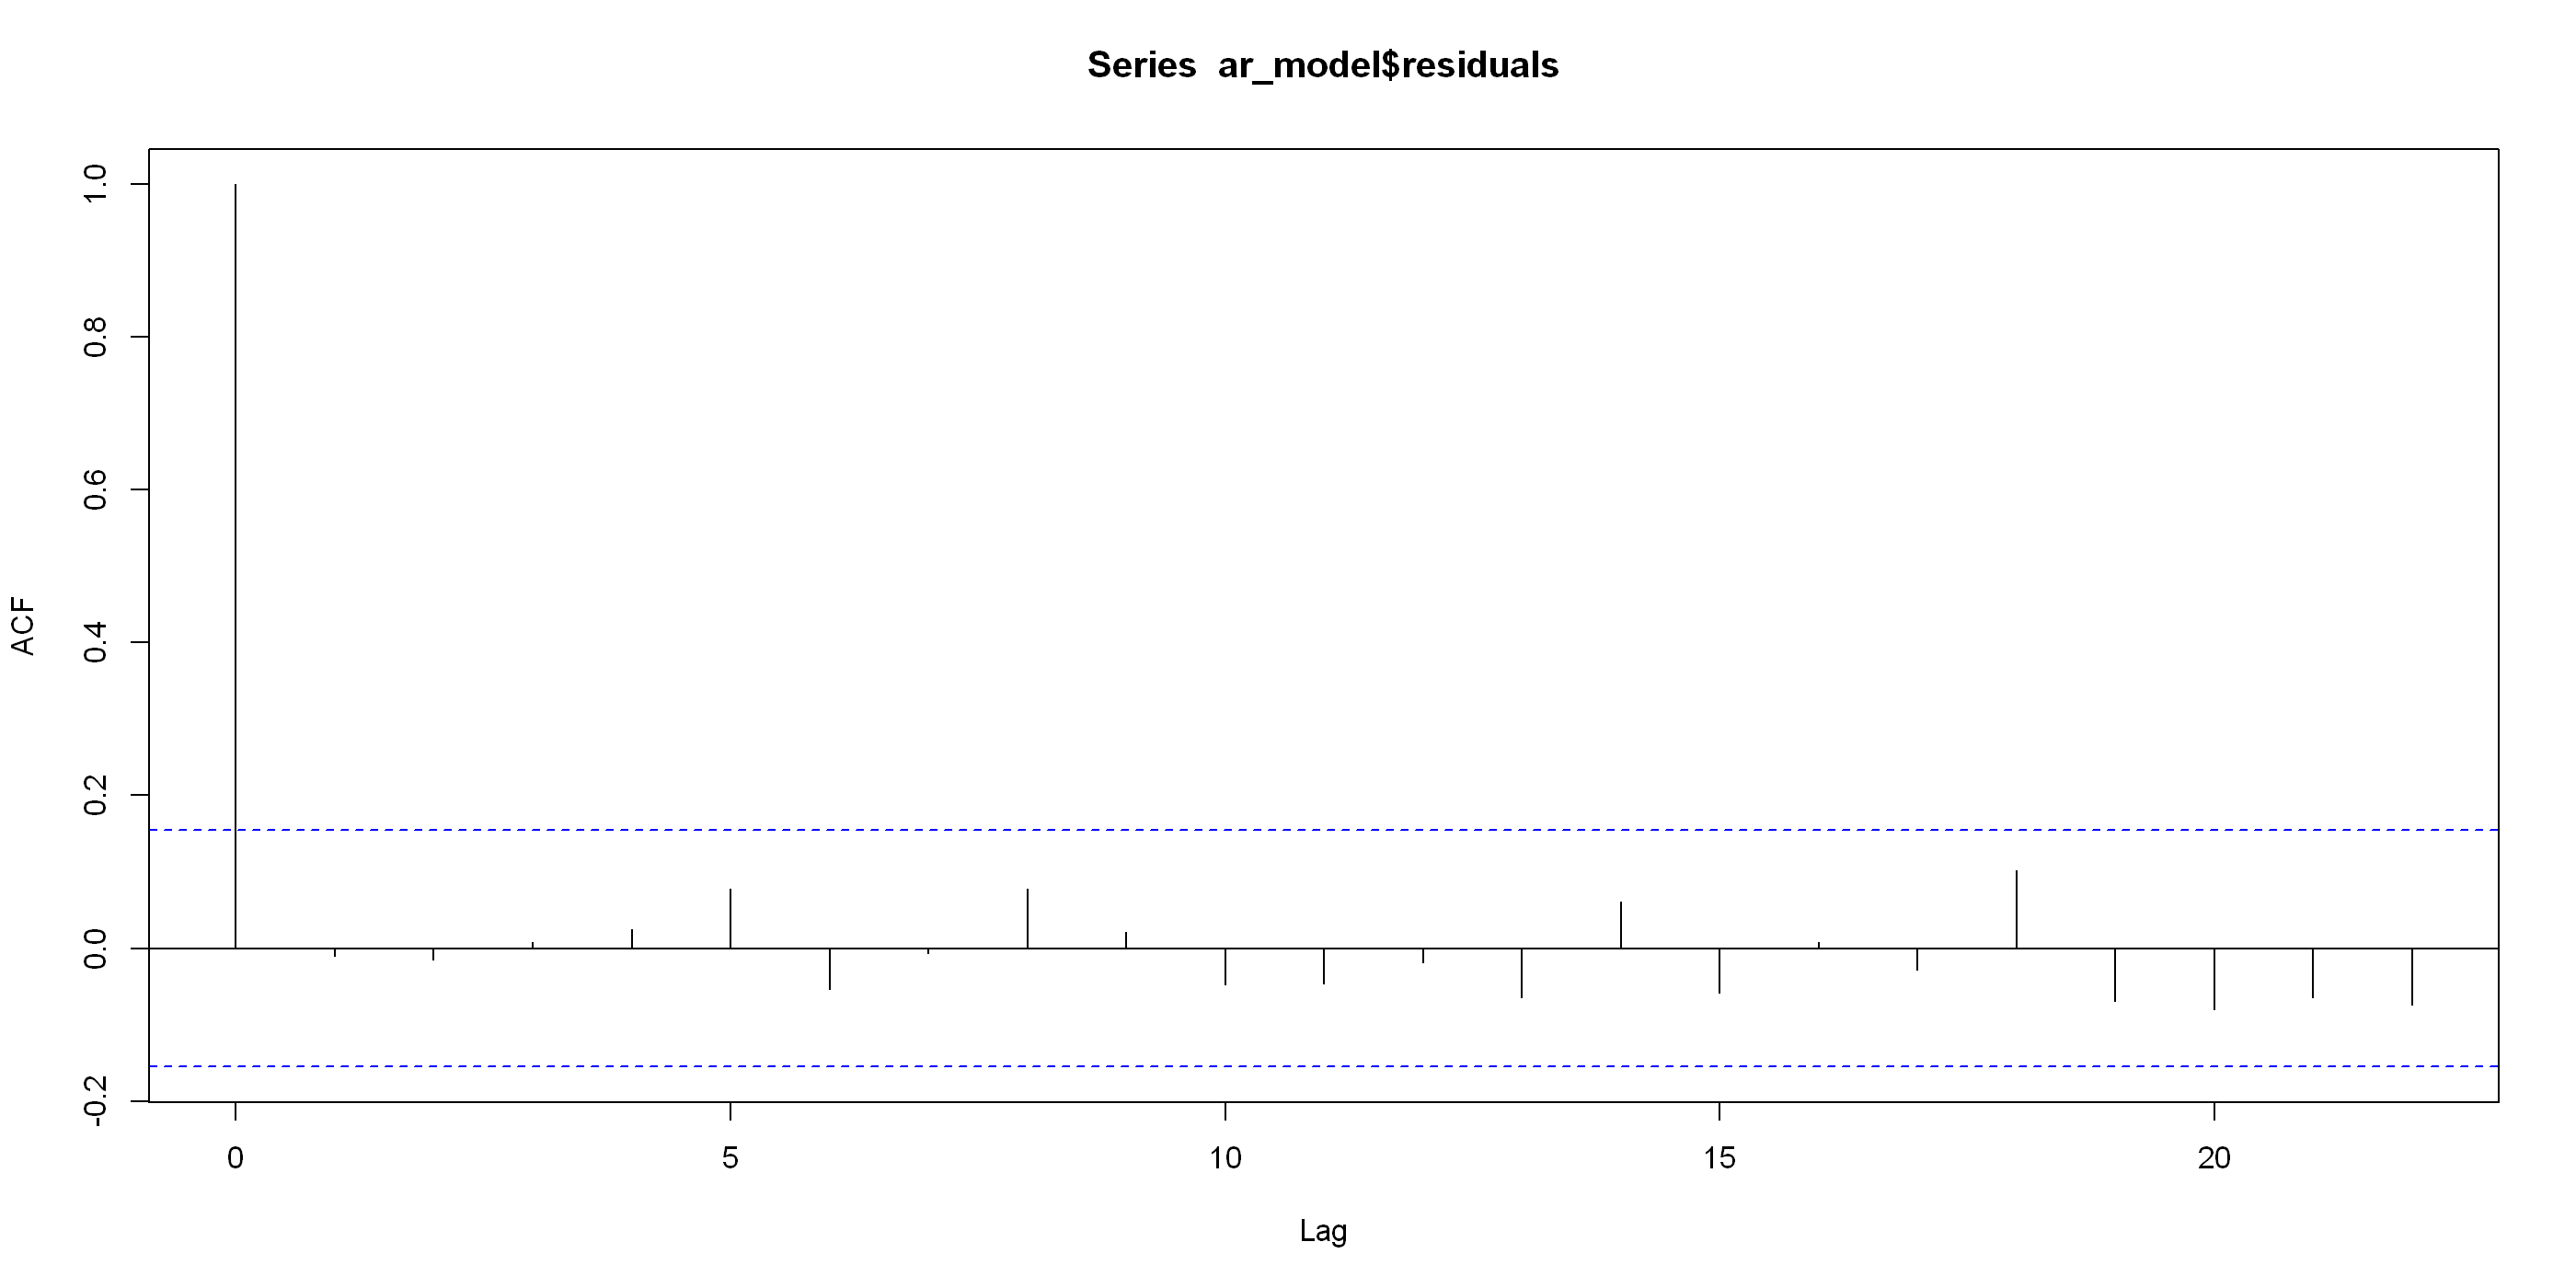

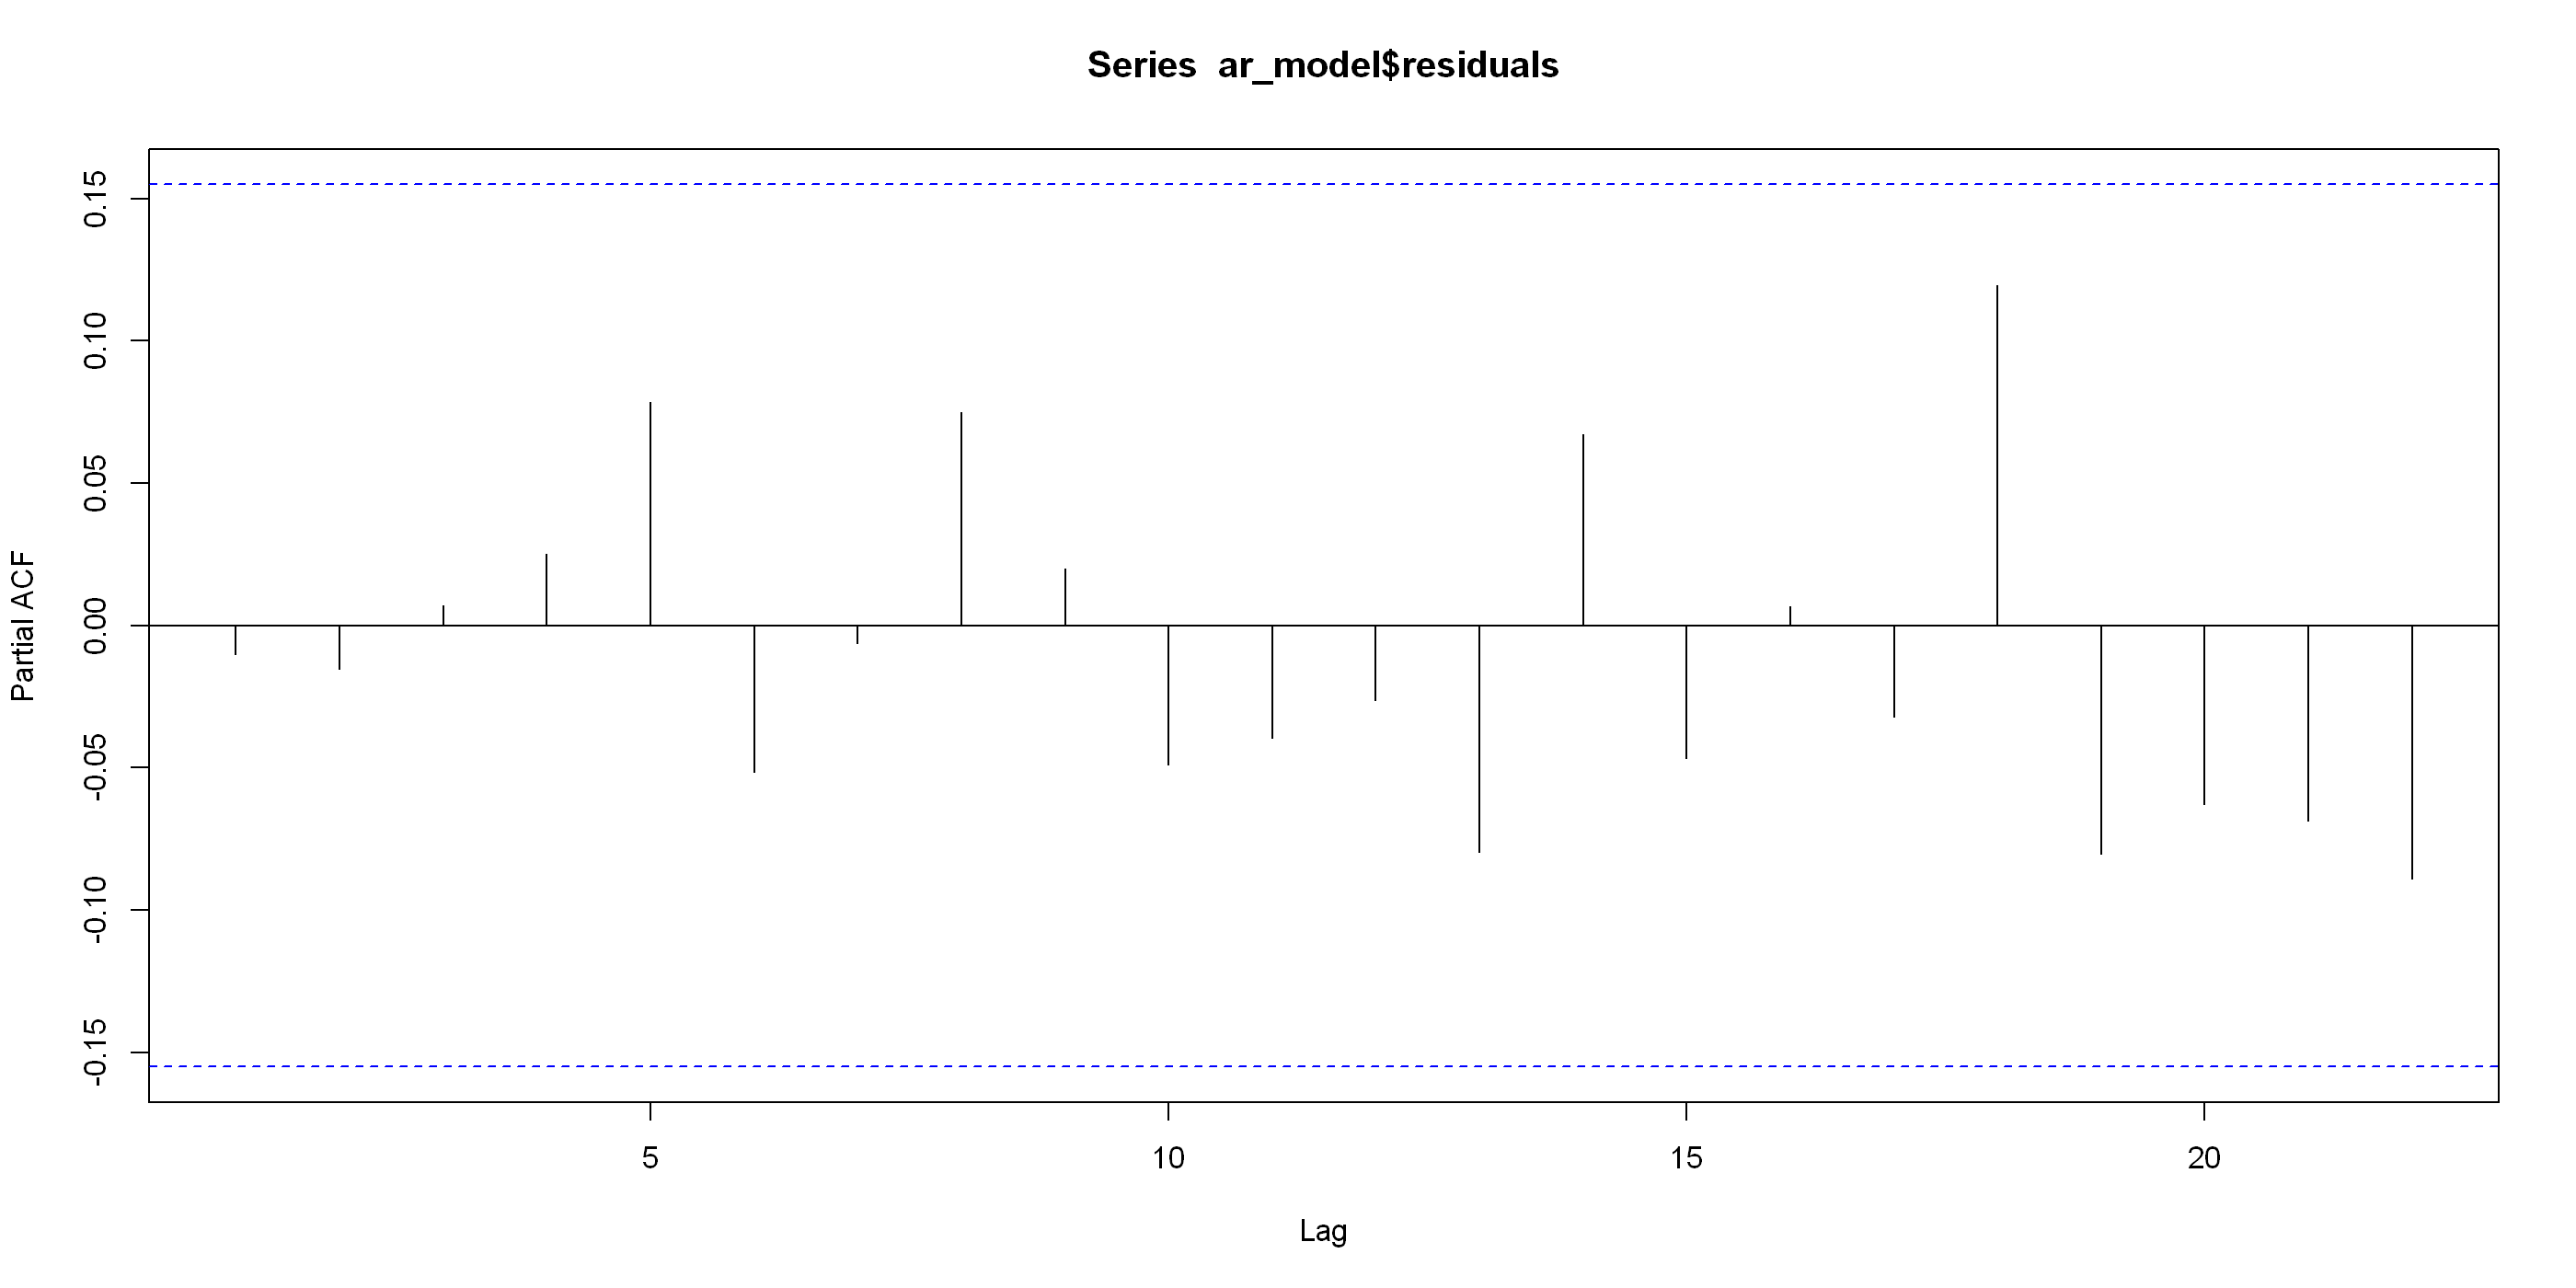

In [53]:
acf(ar_model$residuals)
pacf(ar_model$residuals)

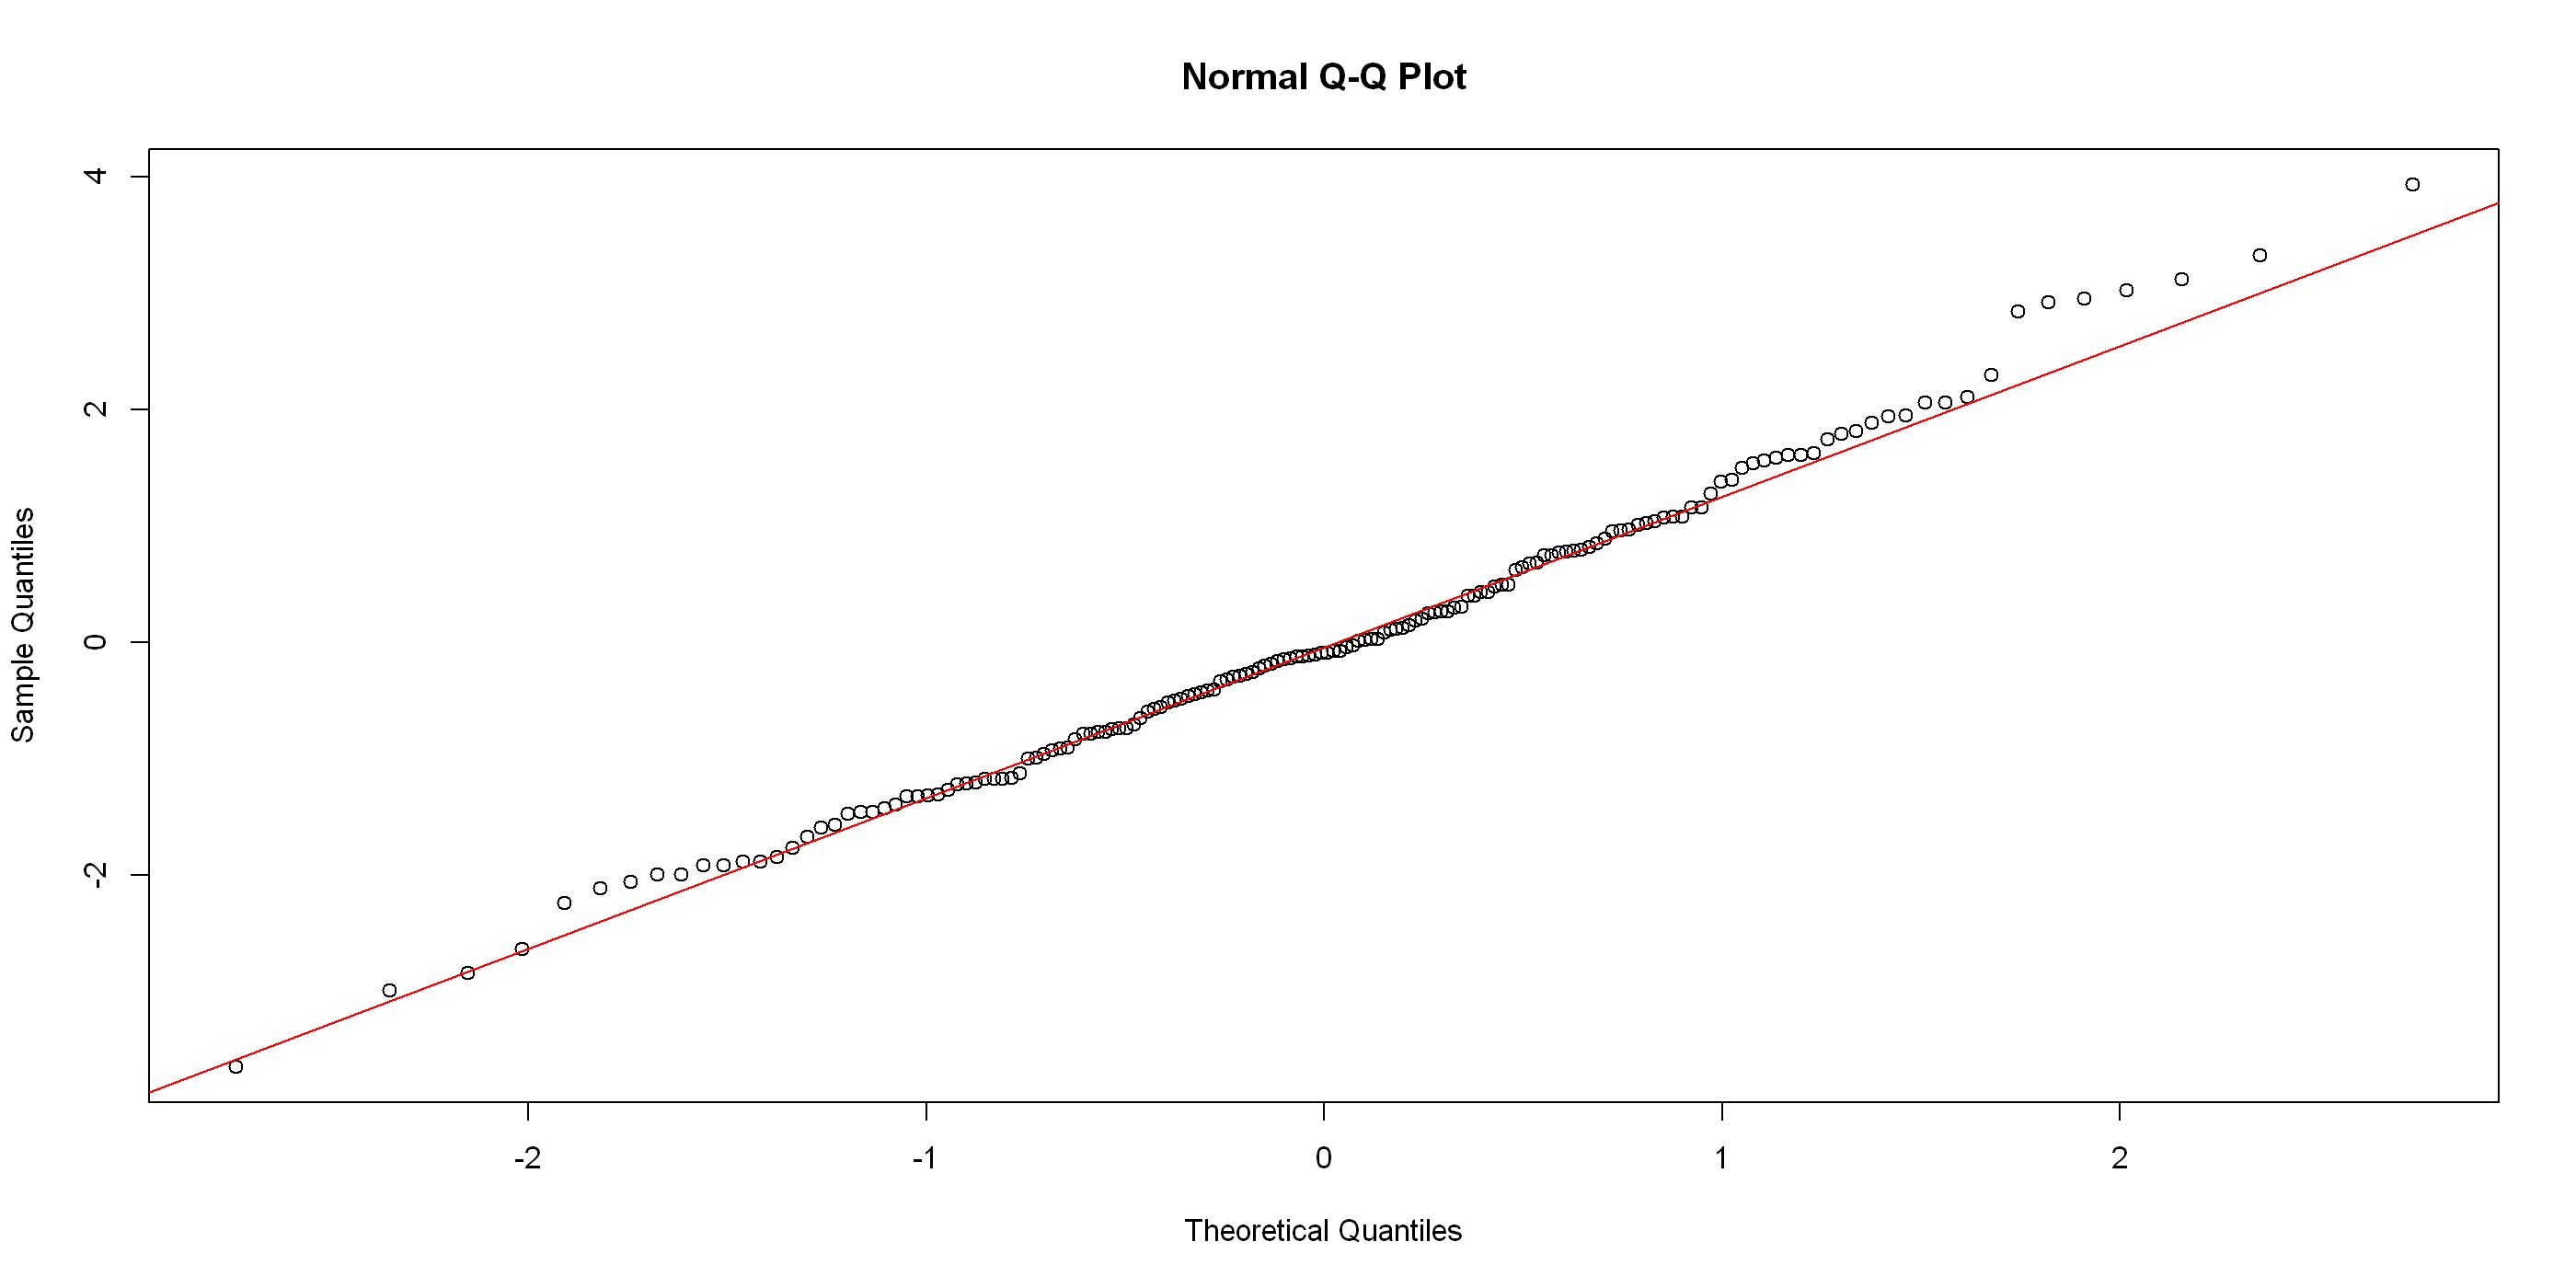

In [54]:
qqnorm(y=ar_model$residuals)
qqline(y=ar_model$residuals,col="red")

Now for the residuals, there is no clear structure, no serial correlation and roughly speaking fits the normal distribution.

#### c

With d-many features
$$
f(\underline{x},\underline{\beta})_t = \beta_0 \mathbb{1}_t + \sum^d_{i=1}\beta_i x_{t,i} + E_t
$$

with $E_t$ modelled by $AR(p)$:

$$
\underline{x}^*_t = \underline{x}_t-\sum^{p}_{j=1} \alpha_j \underline{x}_{t-j}
$$

and 
$$
\mathbb{1}^*_t = \mathbb{1}_t - \sum^{p}_{j=1} \alpha_j \mathbb{1}_{t-j} 
$$

ultimately

$$
E_t = \sum^p_{j=1} \alpha_j E_{t-j} + U_t \Leftrightarrow U_t = E_t-\sum^p_{j=1} \alpha_j E_{t-j} 
$$

which yields

$$
f^*(\underline{x},\underline{\beta},\underline{\alpha})_t = \beta_0 \left(\mathbb{1}_t - \sum^{p}_{j=1} \alpha_j \mathbb{1}_{t-j}\right)  + \sum^d_{i=1}\beta_i \left(x_{t,i}-\sum^{p}_{j=1} \alpha_j x_{t-j,i} \right) + E_t-\sum^p_{j=1} \alpha_j E_{t-j} 

$$

In [55]:
ar_model$coef
names(ar_model$coef)

ar1          ar2    intercept 
 0.275587253  0.326276143 -0.005342329

[1] "ar1"       "ar2"       "intercept"

In [56]:
x_transformed <- function(x,ar_model)
{
    x <- as.numeric(x)
    x_trans <- x
    p <- length(ar_model$coef)-1
    for(j in 1:p)
    {
        x_trans <- x_trans - ar_model$coef[j]*dplyr::lag(x,n=j)
    }
    x_trans
}
d.trans <- data.frame(
  NURSING_s  = x_transformed(d.beluga[, "NURSING"],  ar_model),
  PERIOD_s   = x_transformed(d.beluga[, "PERIOD"],   ar_model),
  BOUTS_s    = x_transformed(d.beluga[, "BOUTS"],    ar_model),
  LOCKONS_s  = x_transformed(d.beluga[, "LOCKONS"],  ar_model),
  DAYNIGHT_s = x_transformed(d.beluga[, "DAYNIGHT"], ar_model)
)


In [57]:
lin_model_manAdj <- lm(NURSING_s ~ PERIOD_s + BOUTS_s + LOCKONS_s + DAYNIGHT_s,data=d.trans)

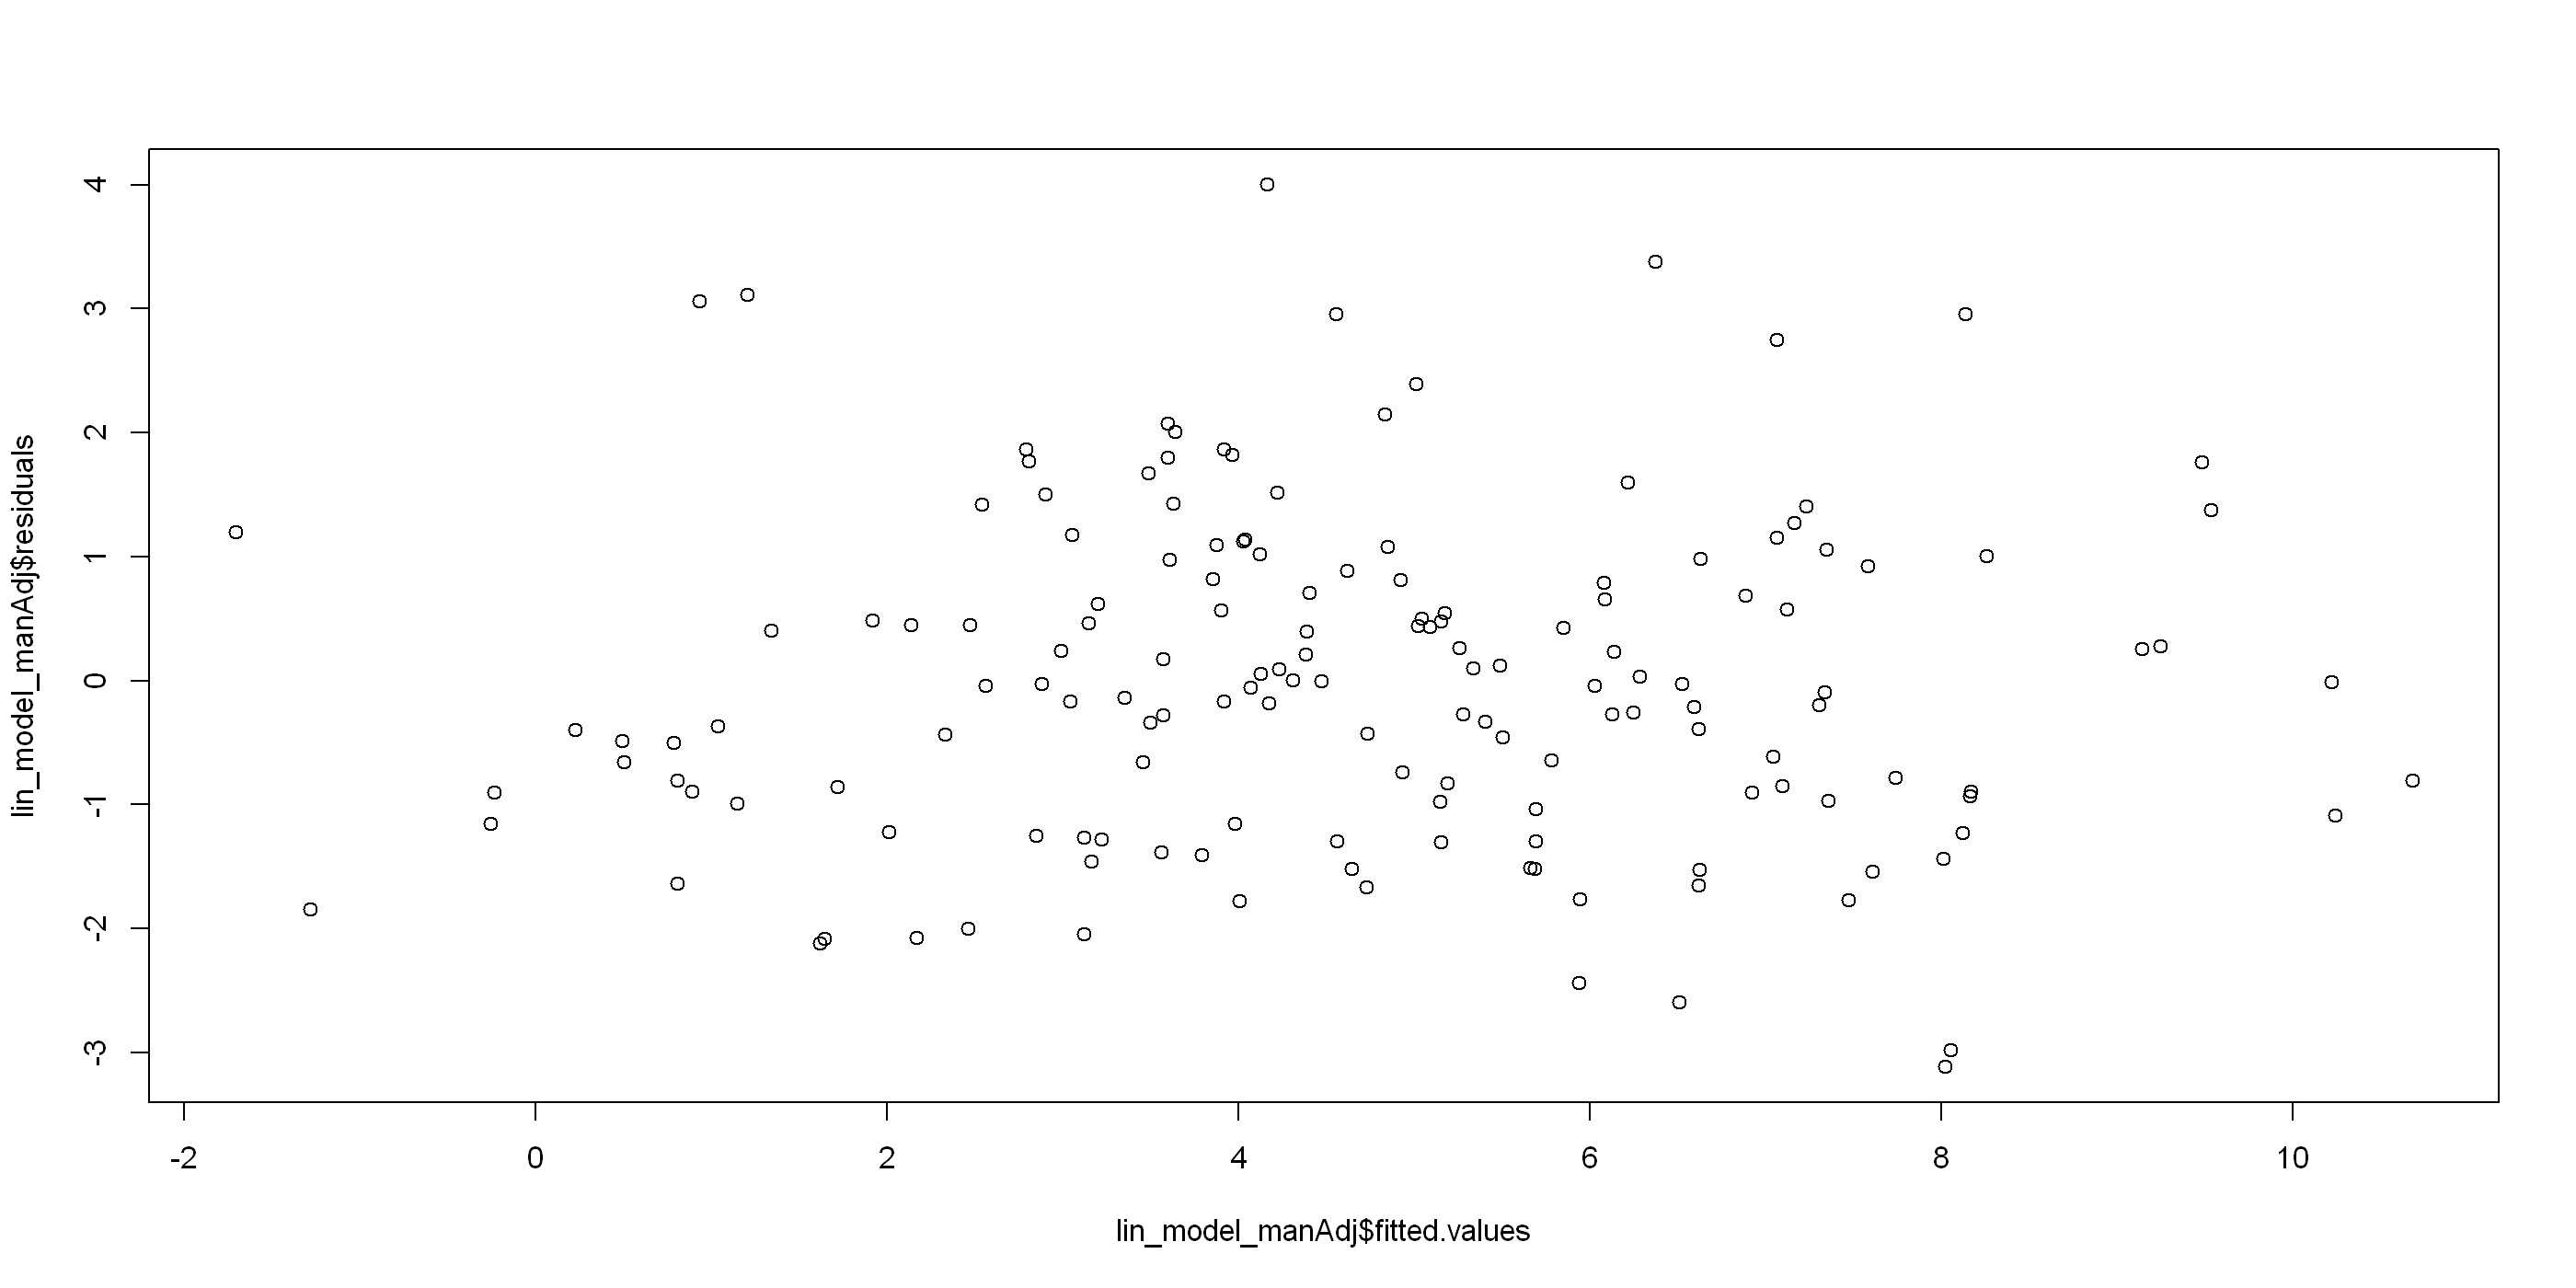

In [58]:
plot(lin_model_manAdj$fitted.values,lin_model_manAdj$residuals)

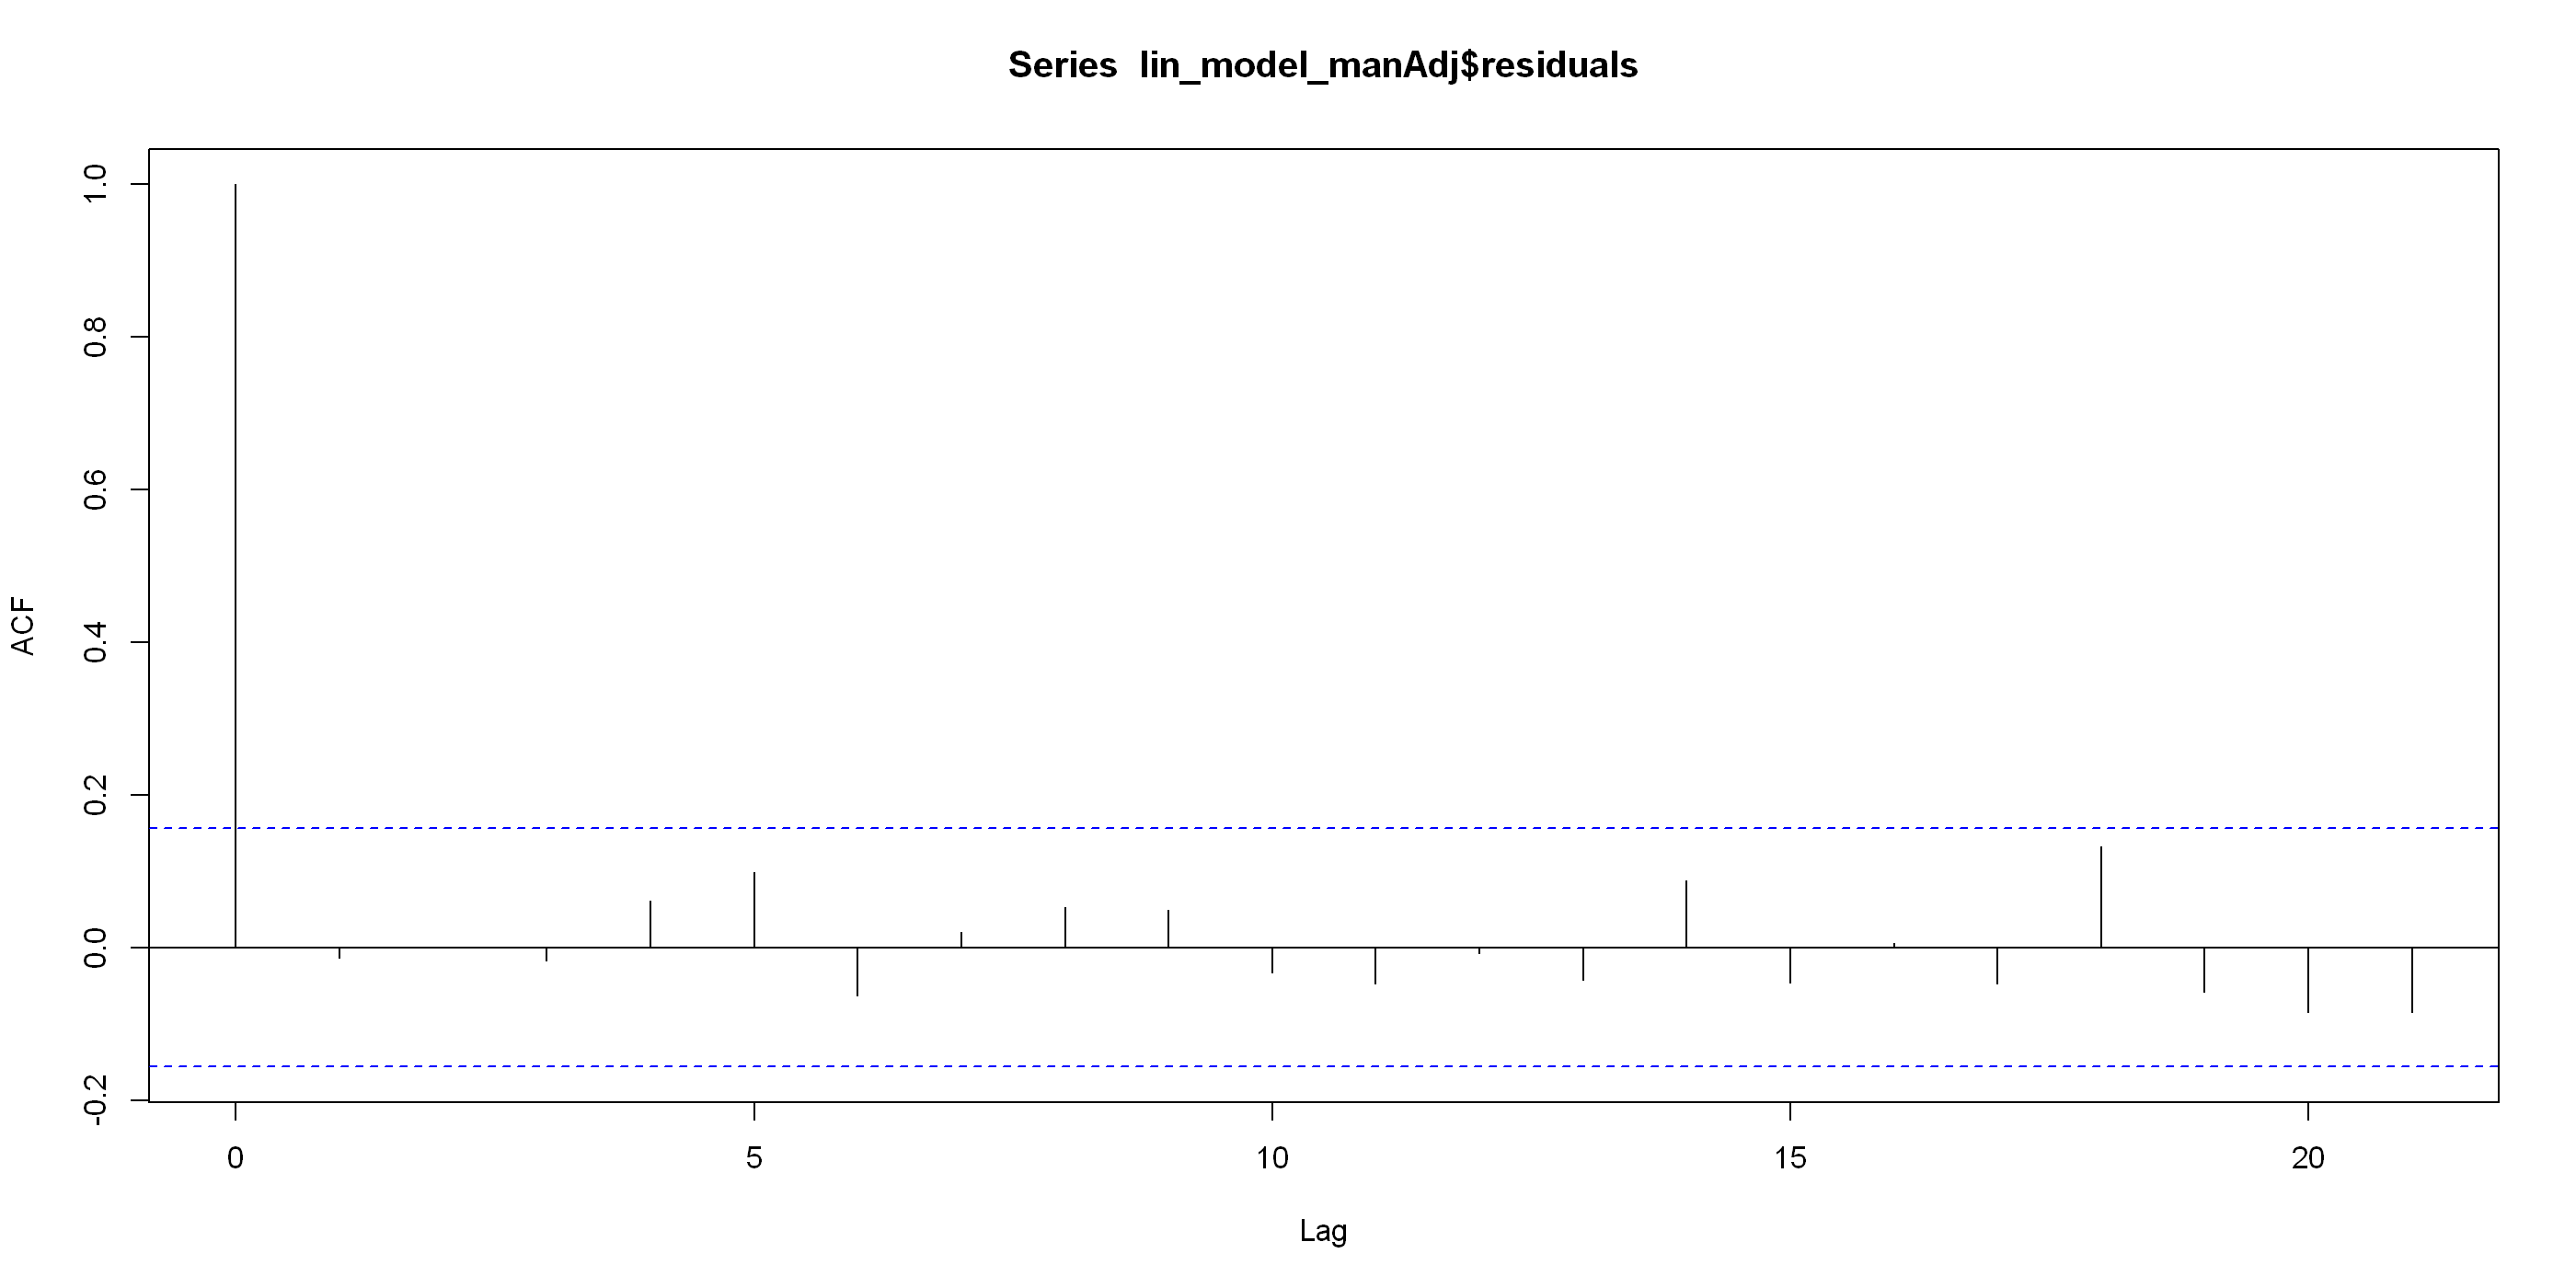

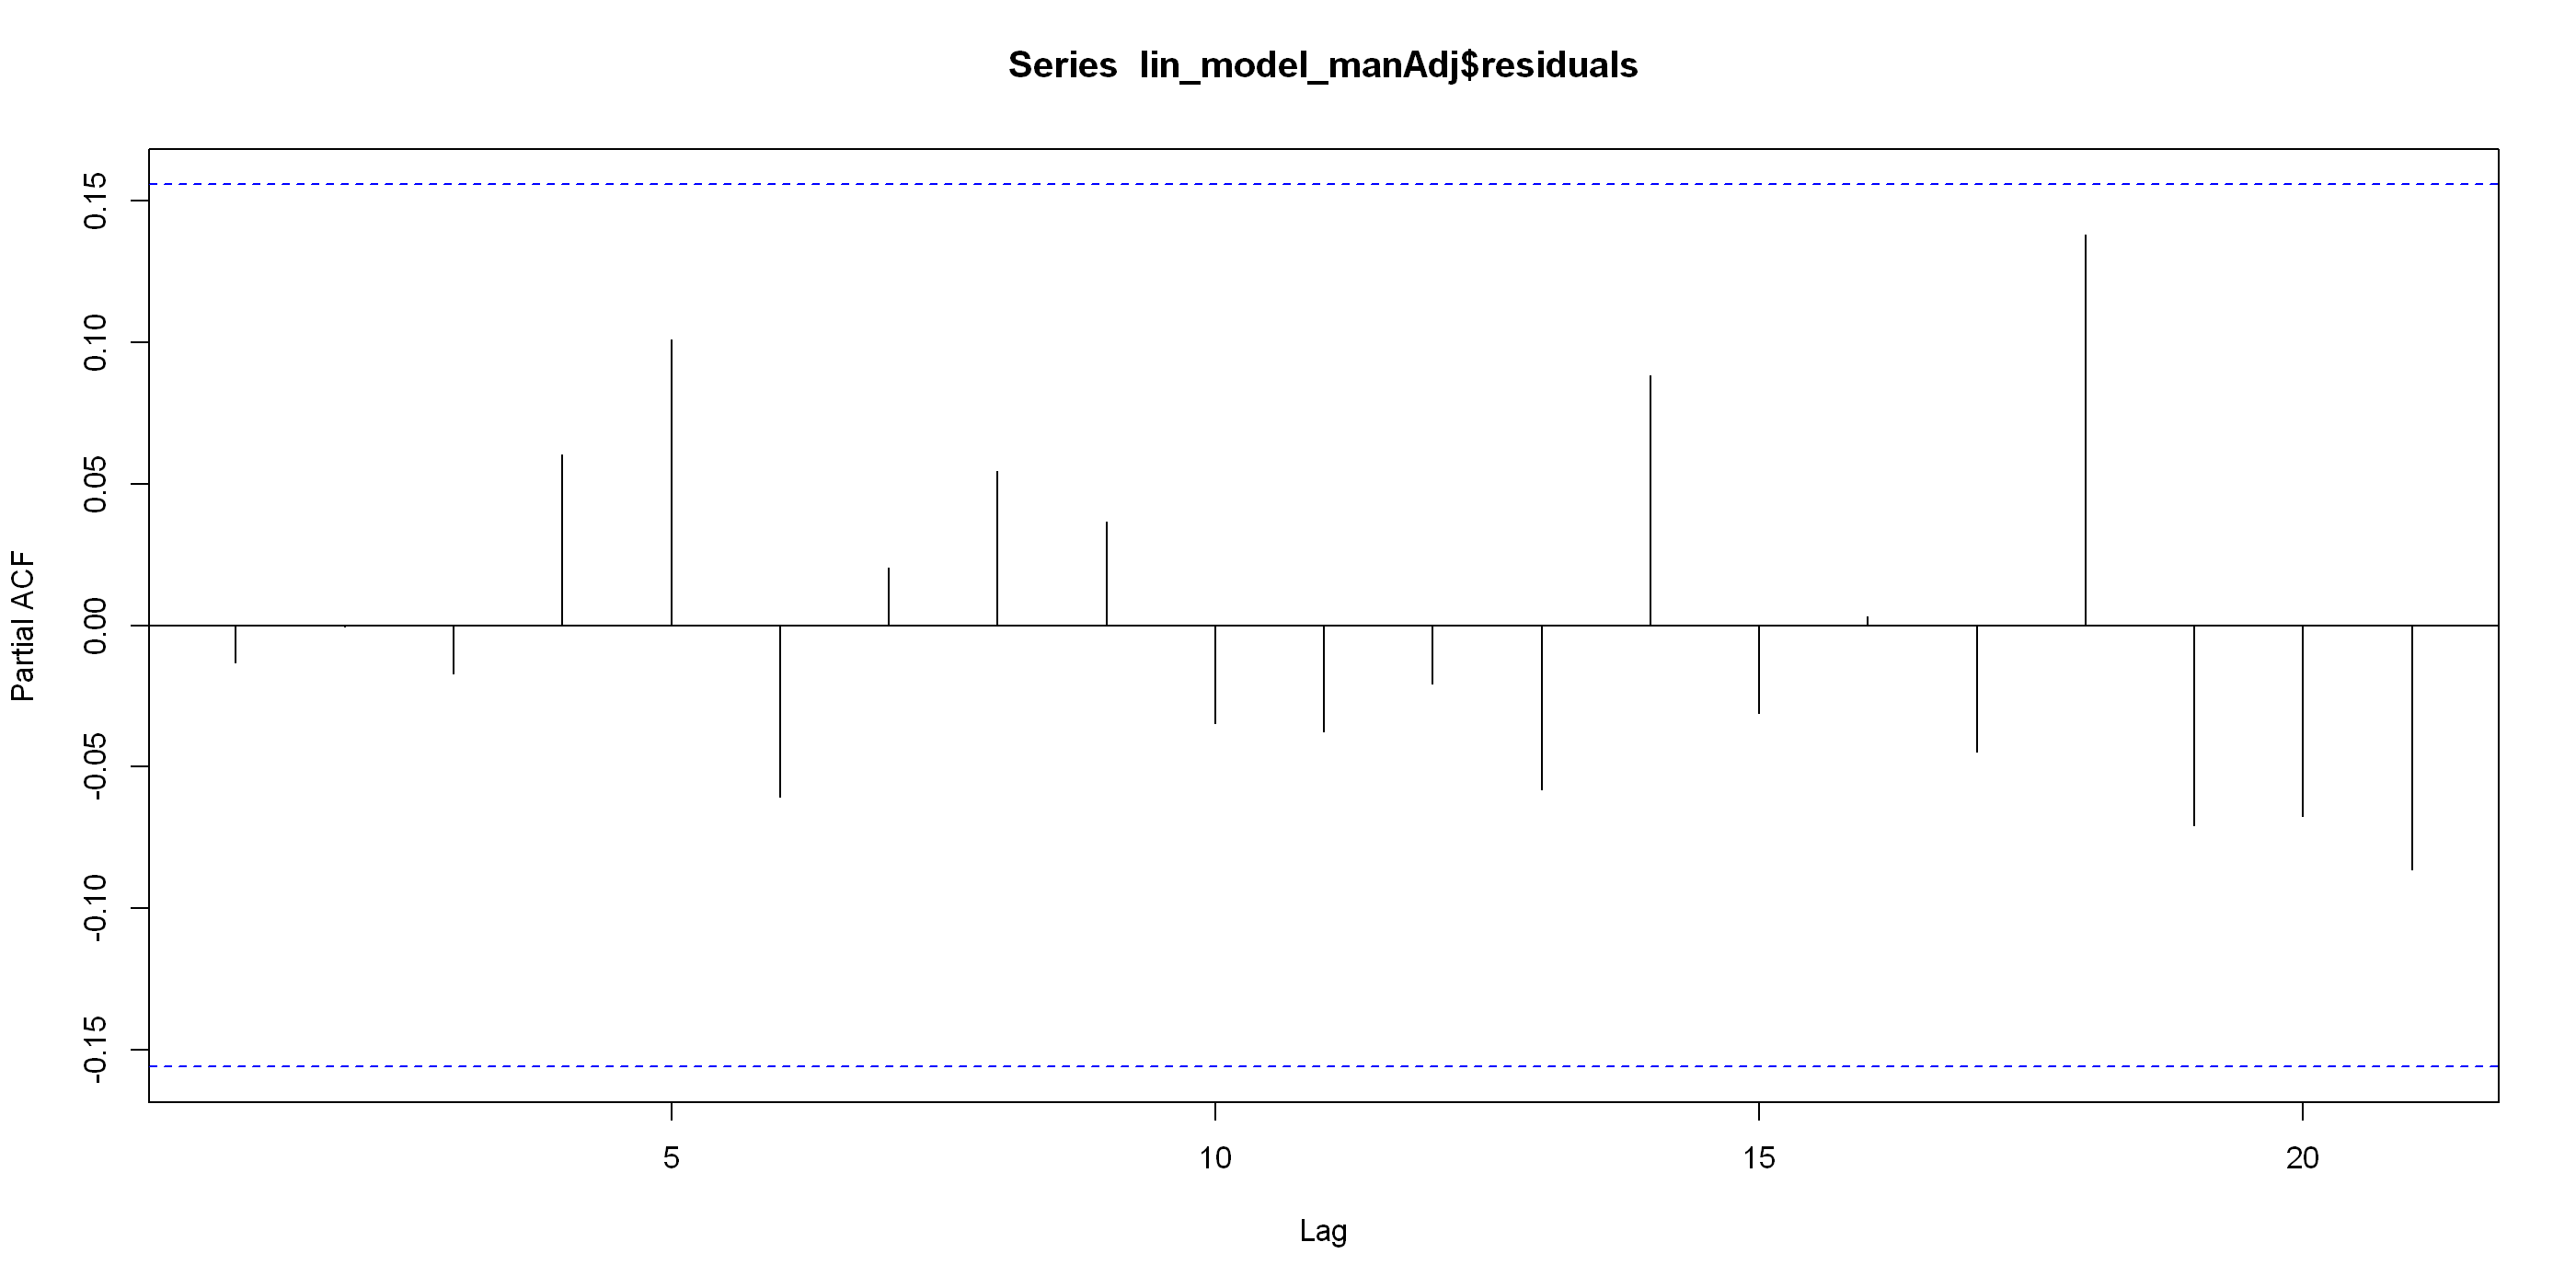

In [59]:
acf(lin_model_manAdj$residuals)
pacf(lin_model_manAdj$residuals)

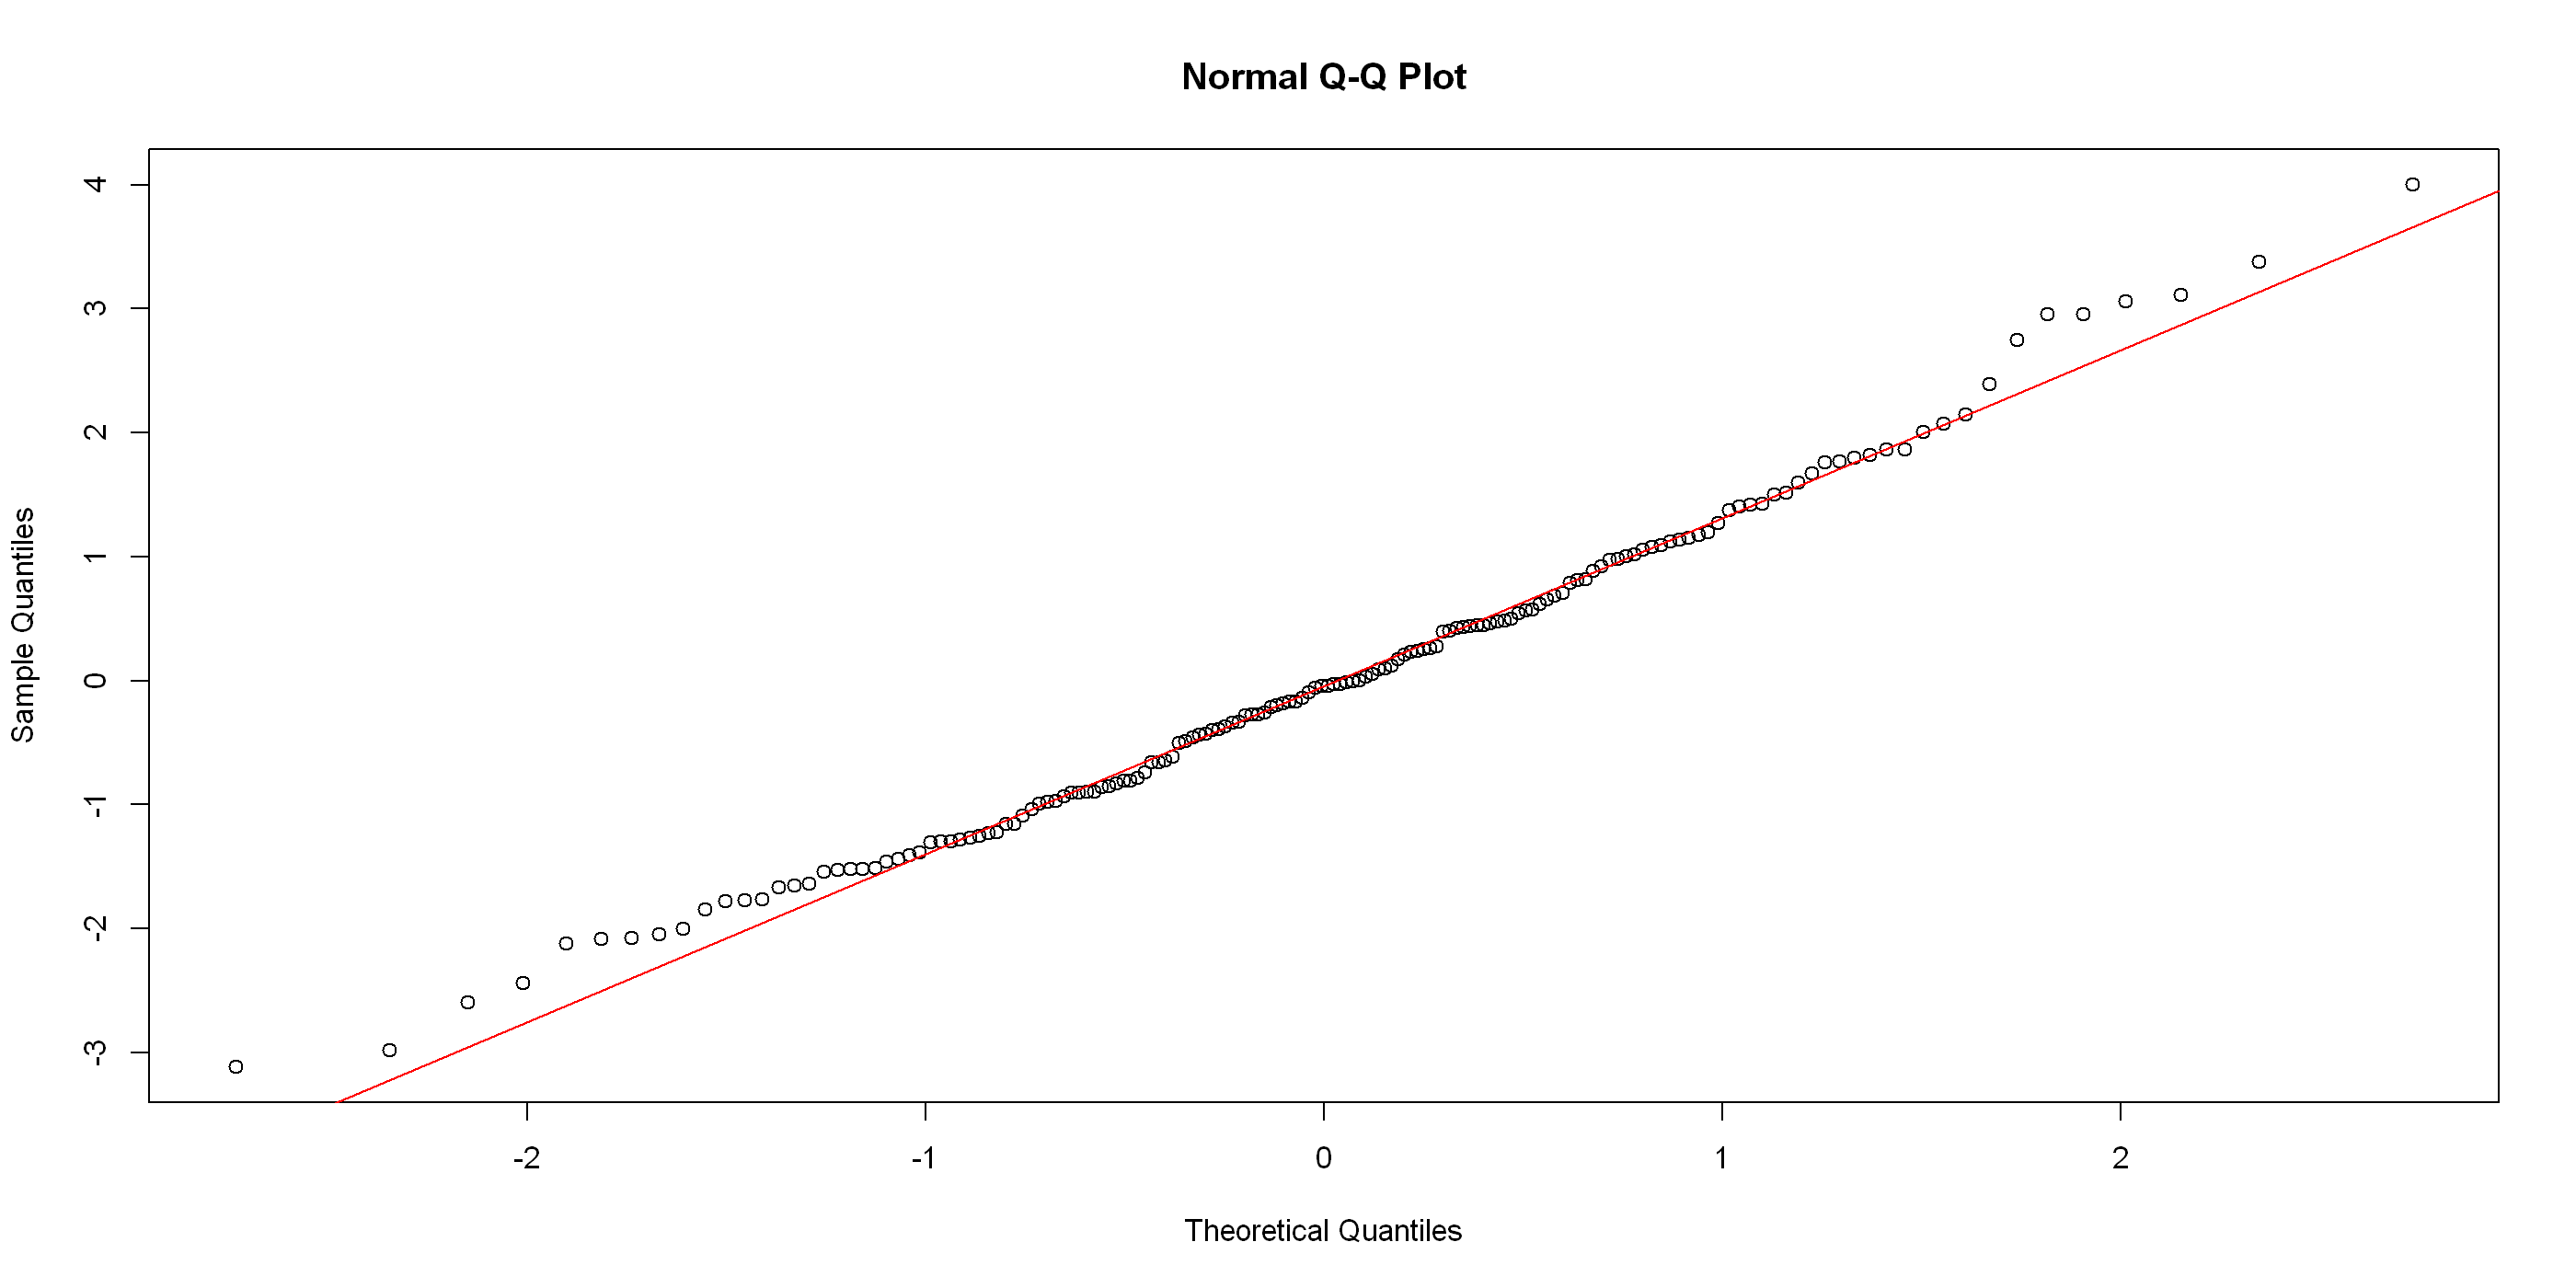

In [60]:
qqnorm(lin_model_manAdj$residuals)
qqline(lin_model_manAdj$residuals,col="red")

In [61]:
library(nlme)

In [62]:
lin_model_adj <- gls(NURSING ~ PERIOD + BOUTS + LOCKONS + DAYNIGHT, data = d.beluga,correlation=corARMA(p=2,q=0))

In [63]:
r_norm <- residuals(lin_model_adj, type = "normalized")


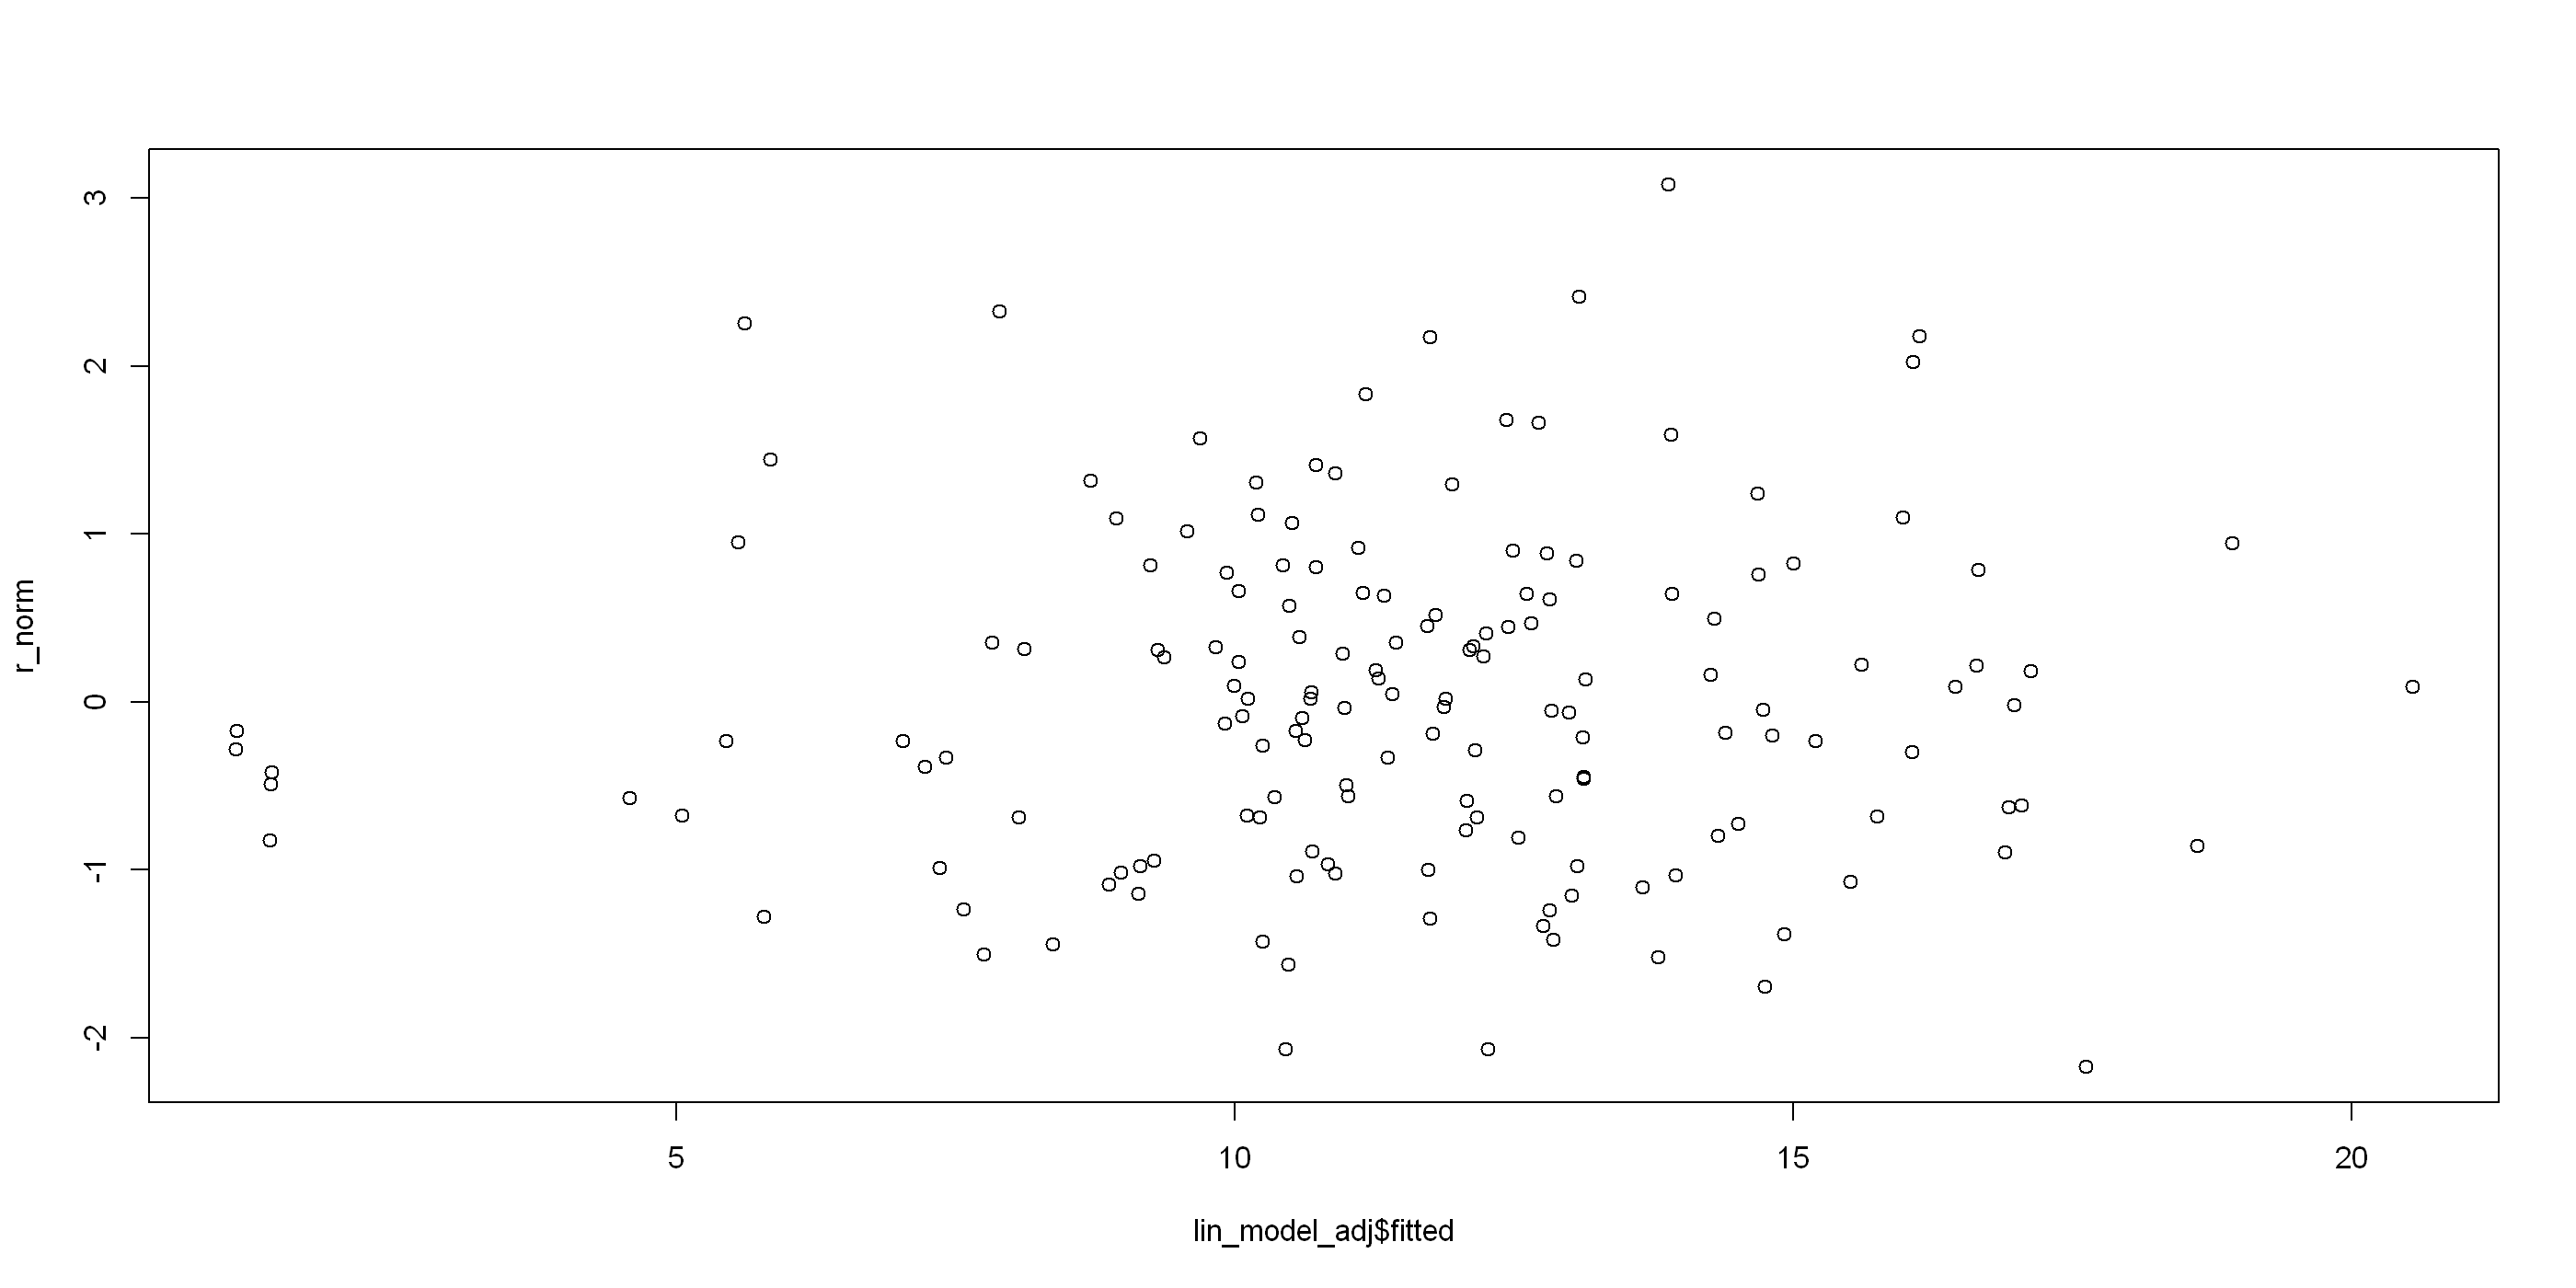

In [64]:
plot(lin_model_adj$fitted,r_norm)

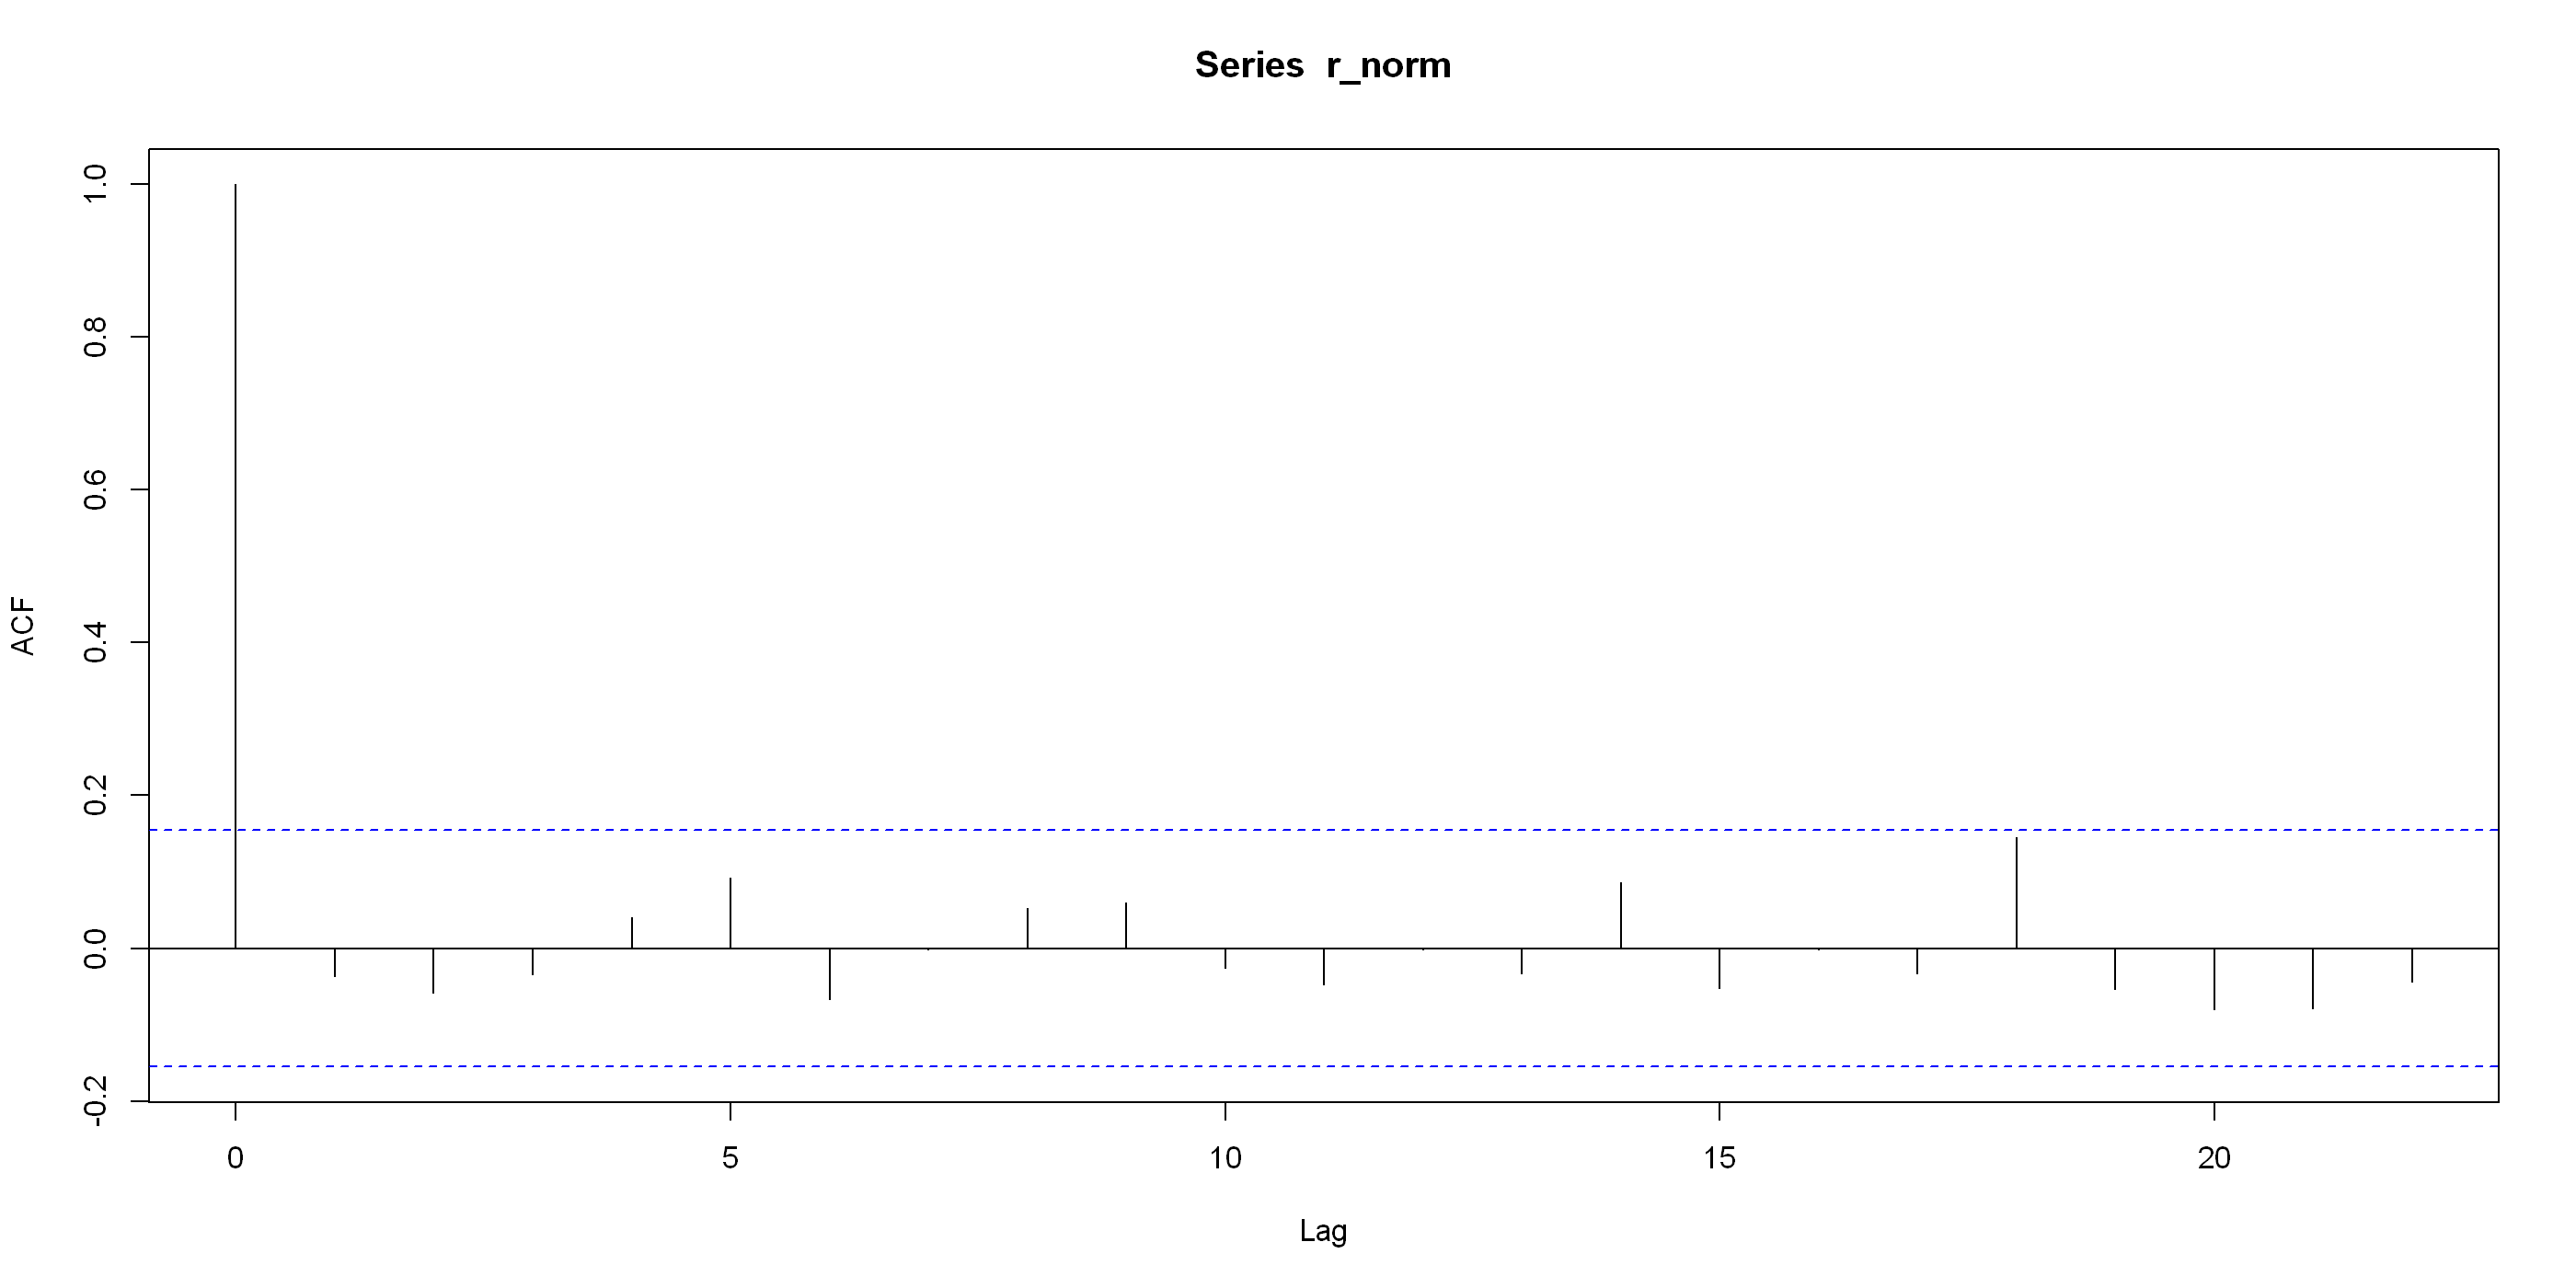

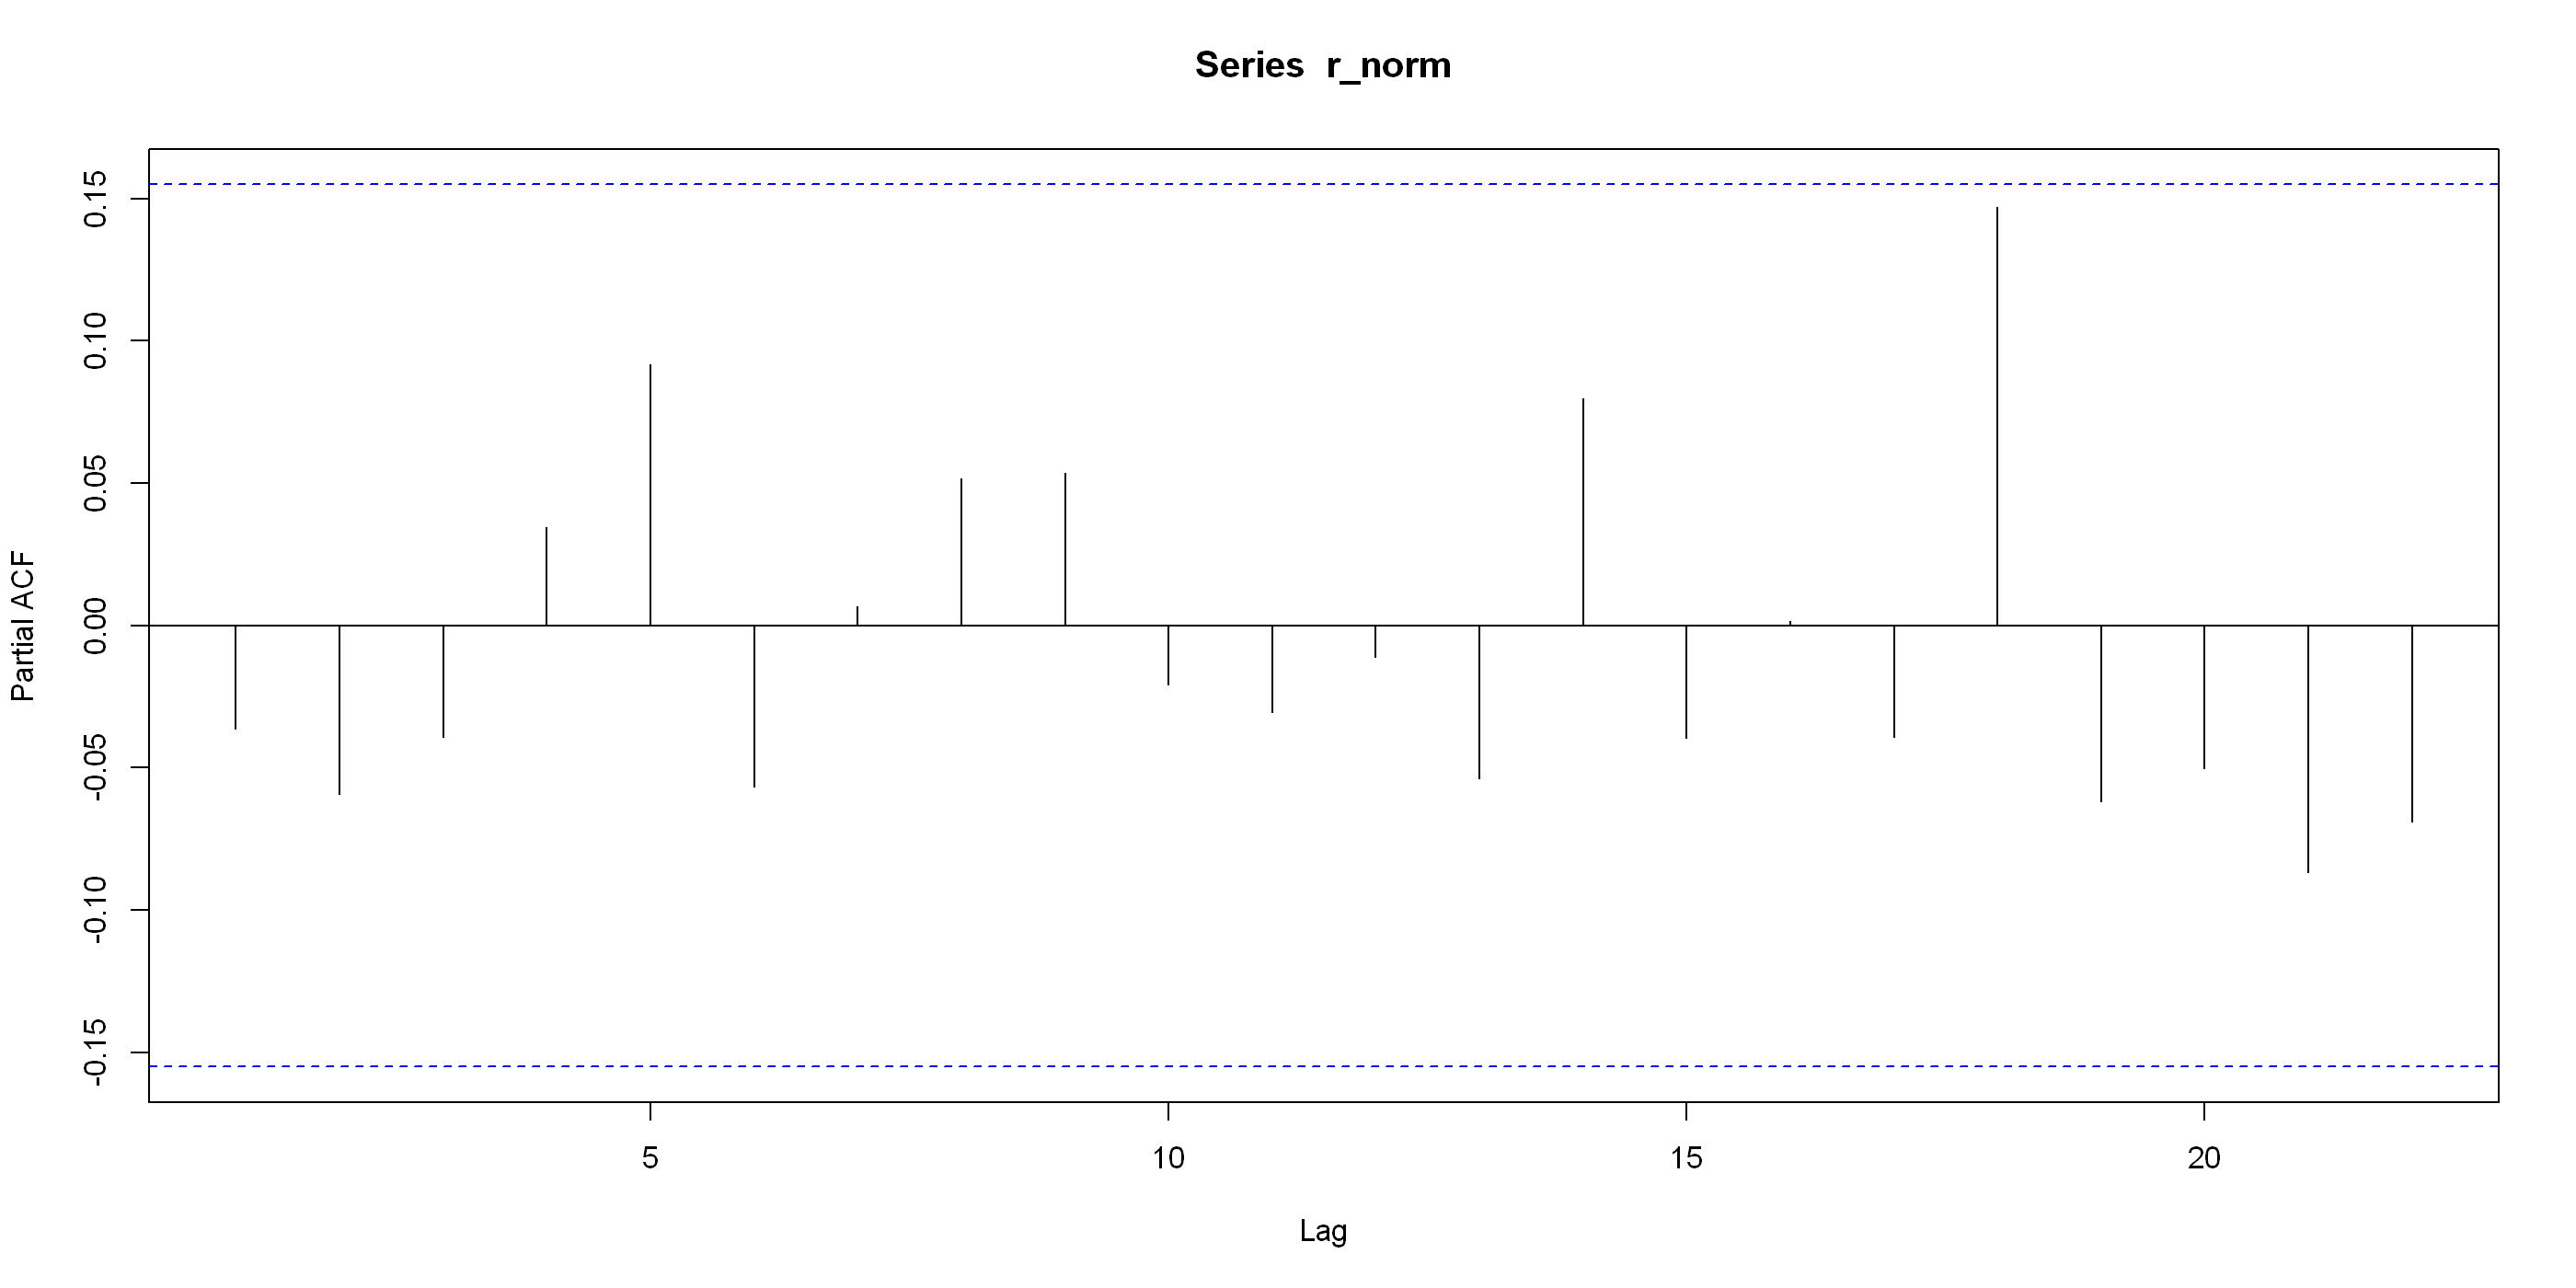

In [65]:
acf(r_norm)
pacf(r_norm)

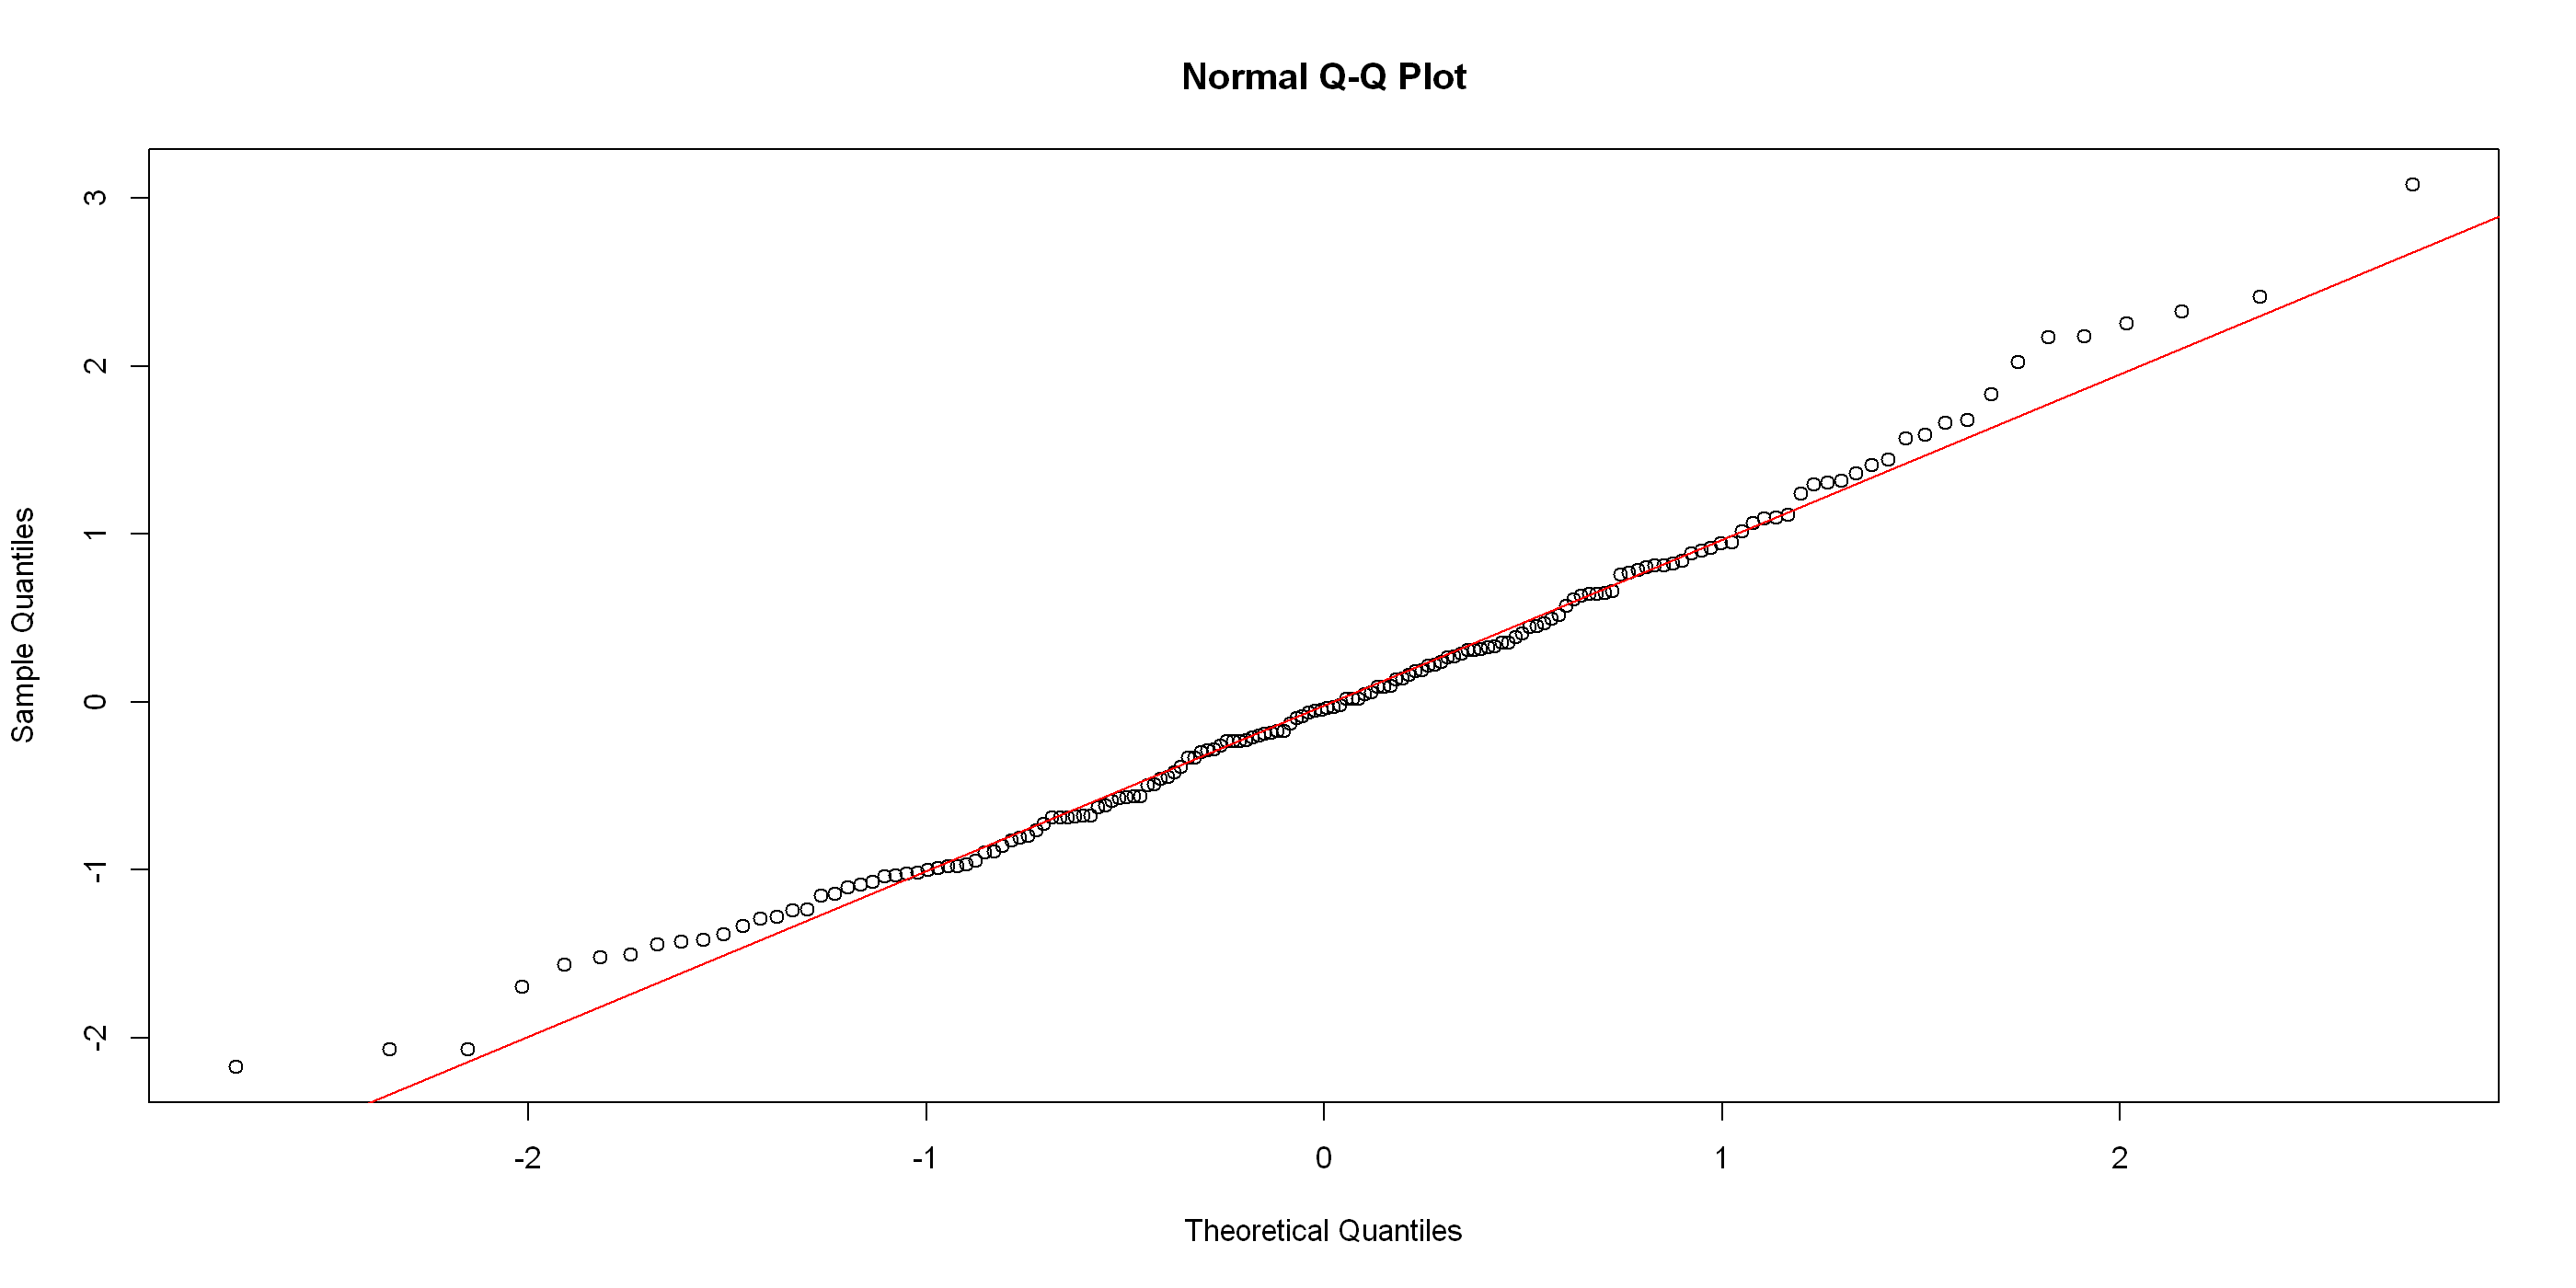

In [66]:
qqnorm(r_norm)
qqline(r_norm,col="red")

In [67]:
summary(lin_model_adj)

Generalized least squares fit by REML
  Model: NURSING ~ PERIOD + BOUTS + LOCKONS + DAYNIGHT 
  Data: d.beluga 
       AIC      BIC    logLik
  574.0451 598.3925 -279.0226

Correlation Structure: ARMA(2,0)
 Formula: ~1 
 Parameter estimate(s):
     Phi1      Phi2 
0.2943069 0.3815600 

Coefficients:
                 Value Std.Error   t-value p-value
(Intercept)  1.3621123 0.8122847  1.676890  0.0956
PERIOD       0.0027206 0.0068844  0.395181  0.6933
BOUTS        0.2654501 0.3374061  0.786738  0.4326
LOCKONS      2.5742257 0.1959795 13.135176  0.0000
DAYNIGHT    -0.3055626 0.1528684 -1.998861  0.0474

 Correlation: 
         (Intr) PERIOD BOUTS  LOCKON
PERIOD   -0.633                     
BOUTS    -0.289 -0.215              
LOCKONS  -0.095  0.227 -0.807       
DAYNIGHT -0.010  0.023 -0.138  0.068

Standardized residuals:
        Min          Q1         Med          Q3         Max 
-2.65570301 -0.55476100  0.01668981  0.60704810  2.38086762 

Residual standard error: 1.655502 
Degrees o

In [68]:
summary(prcomp(d.beluga[, c("PERIOD", "BOUTS", "LOCKONS", "DAYNIGHT")],
               scale. = TRUE))

Importance of components:
                          PC1    PC2    PC3     PC4
Standard deviation     1.3750 1.0090 0.9834 0.35248
Proportion of Variance 0.4727 0.2545 0.2417 0.03106
Cumulative Proportion  0.4727 0.7272 0.9689 1.00000

In [69]:
simplified_model <- function(data, include) {
  data <- as.data.frame(data)
  f    <- reformulate(termlabels = include, response = "NURSING")
  fit  <- gls(f, data = data,
              correlation = corARMA(p = 2, q = 0),
              method      = "ML")
  list(
    fit  = fit,
    res  = residuals(fit, type = "normalized"),
    vars = include
  )
}

plot_diagnostics <- function(m, label = "") {
  op <- par(mfrow = c(2, 2), mar = c(4, 4, 2.5, 1), oma = c(0, 0, 2, 0))
  on.exit(par(op))

  r <- m$res
  f <- fitted(m$fit)

  qqnorm(r, main = "Normal Q-Q"); qqline(r, col = "red", lwd = 1.5)
  plot(f, r, xlab = "Fitted", ylab = "Normalized residuals",
       main = "Residuals vs fitted"); abline(h = 0, lty = 2, col = "grey")
  acf(r,  main = "ACF of normalized residuals")
  pacf(r, main = "PACF of normalized residuals")

  mtext(label, outer = TRUE, cex = 1.1, font = 2)
}

In [70]:
## rank and pick top 2
tab     <- tab[order(tab$AIC), ]
top2    <- head(tab$model, 2)
top_fits <- models[top2]

## plot both
for (nm in names(top_fits)) {
  plot_diagnostics(top_fits[[nm]], label = nm)
}

ERROR: Error in eval(expr, envir, enclos): object 'tab' not found


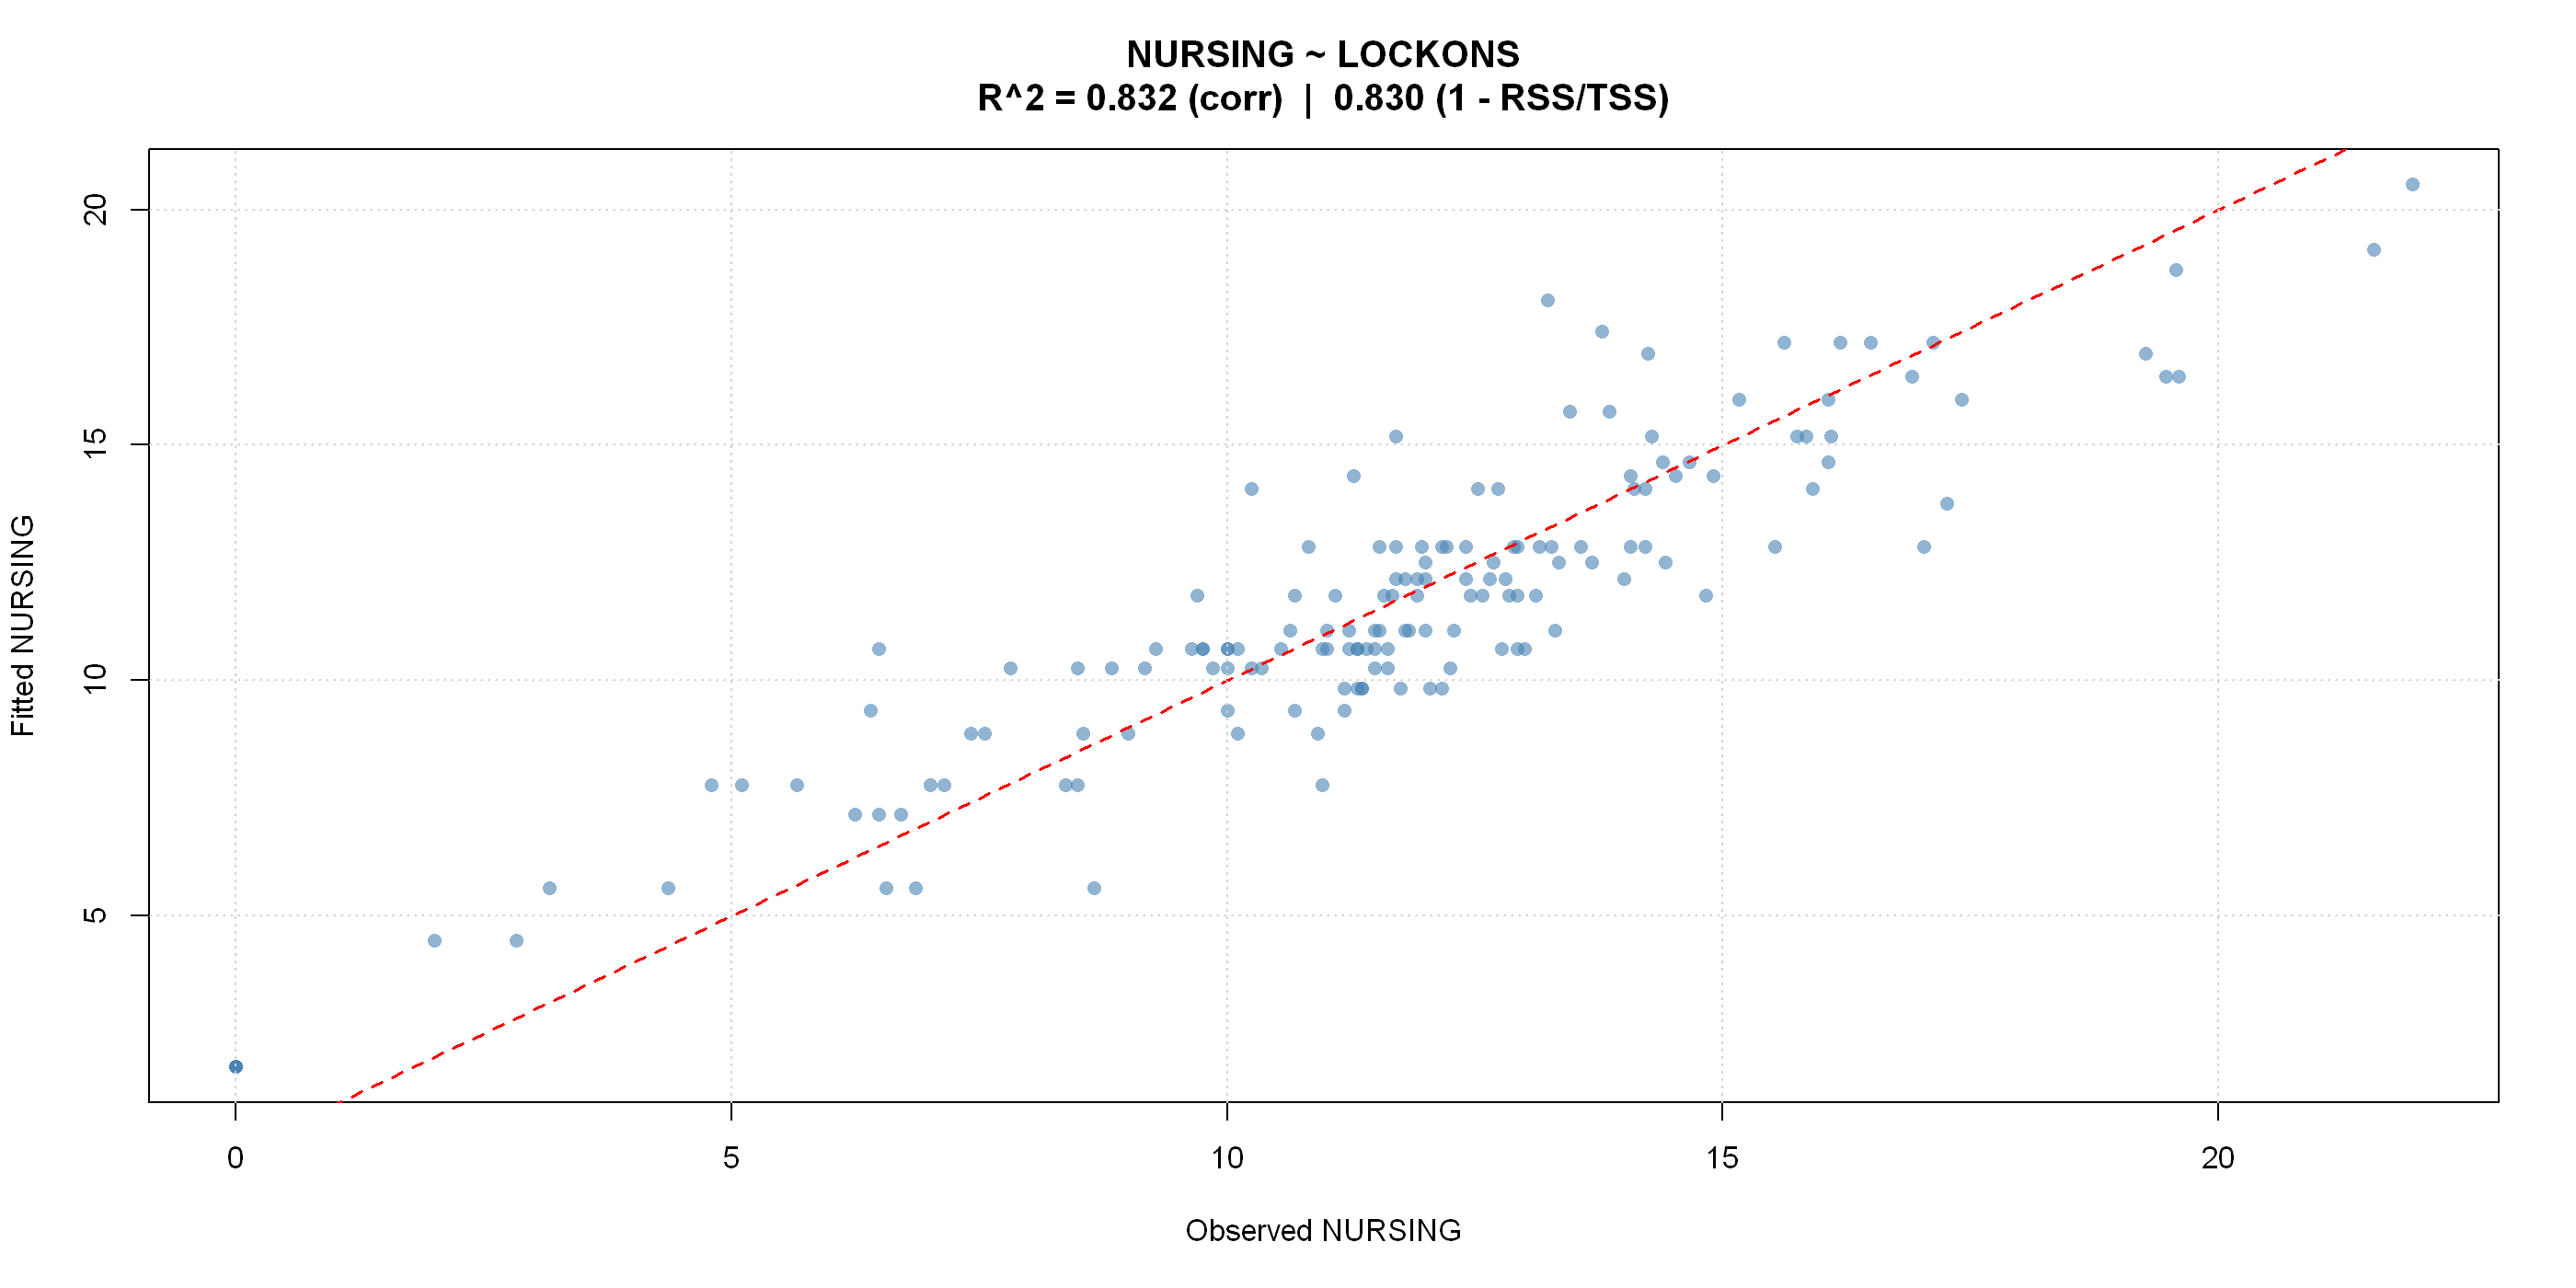

Generalized least squares fit by REML
  Model: NURSING ~ LOCKONS 
  Data: as.data.frame(d.beluga) 
       AIC      BIC    logLik
  562.1728 577.4857 -276.0864

Correlation Structure: ARMA(2,0)
 Formula: ~1 
 Parameter estimate(s):
     Phi1      Phi2 
0.2903487 0.3788887 

Coefficients:
               Value Std.Error   t-value p-value
(Intercept) 1.791558 0.5159290  3.472489   7e-04
LOCKONS     2.677864 0.1151981 23.245722   0e+00

 Correlation: 
        (Intr)
LOCKONS -0.789

Standardized residuals:
        Min          Q1         Med          Q3         Max 
-2.93477040 -0.56028468  0.06232427  0.68153257  2.53861662 

Residual standard error: 1.653149 
Degrees of freedom: 160 total; 158 residual

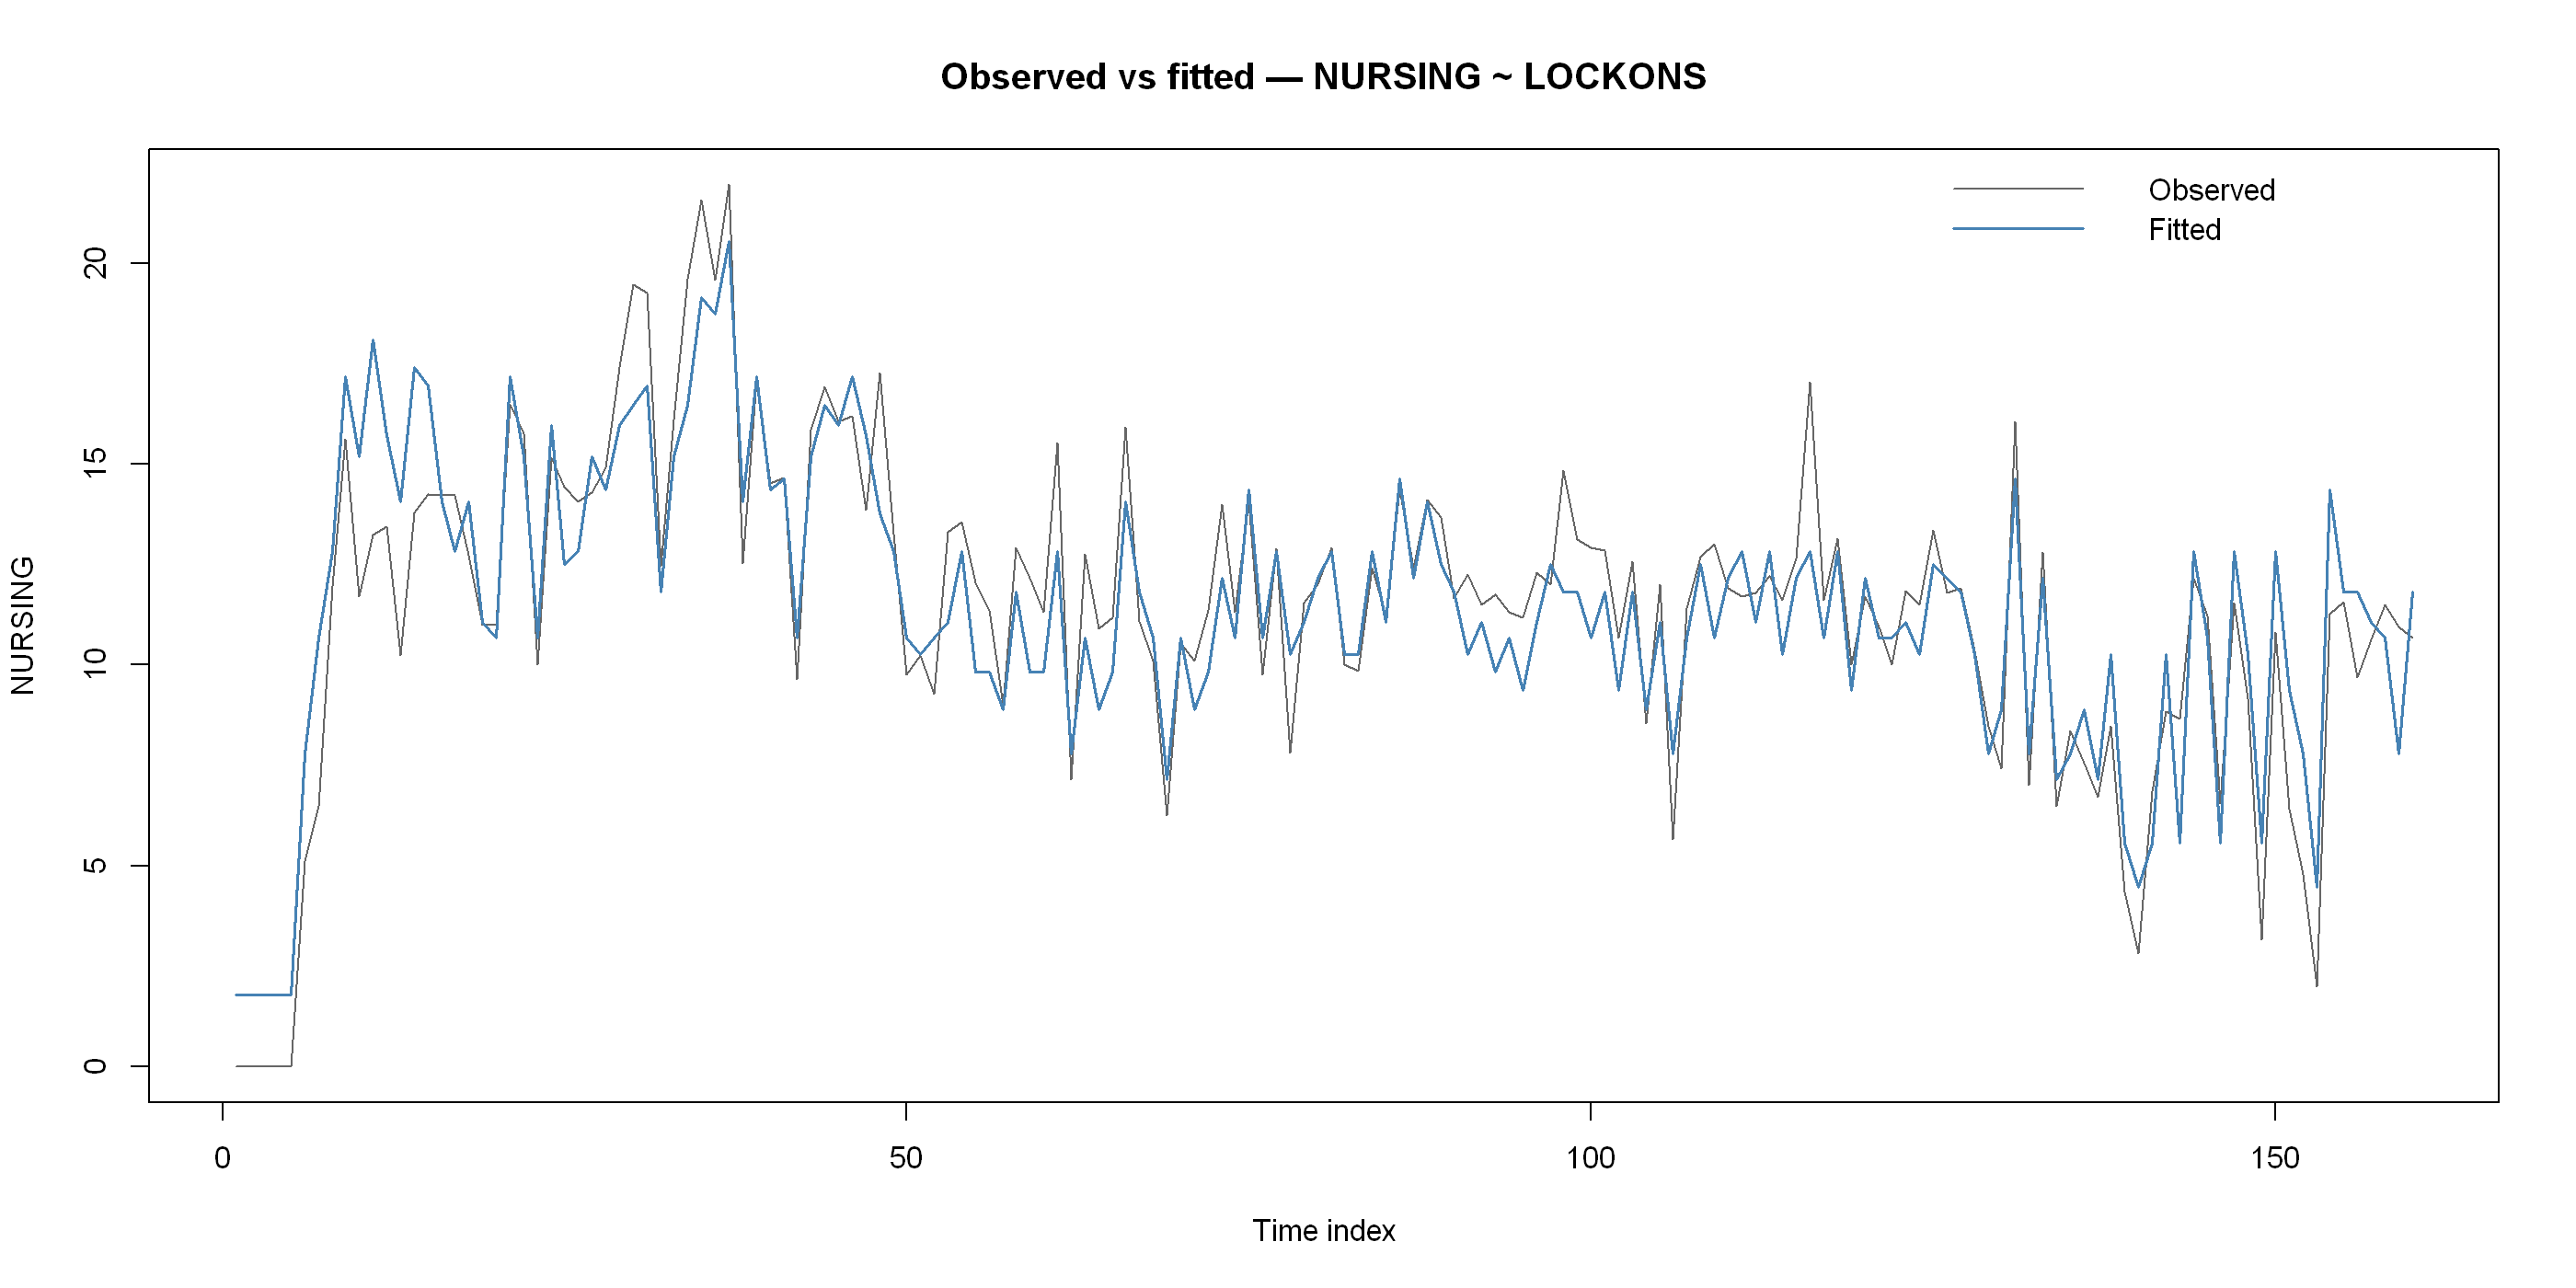

In [71]:
## ------- hardcode the winner: NURSING ~ LOCKONS -------
best_fit <- gls(NURSING ~ LOCKONS,
                data        = as.data.frame(d.beluga),
                correlation = corARMA(p = 2, q = 0),
                method      = "REML")

## ------- fit vs. observed + R^2 -------
y    <- as.numeric(d.beluga[, "NURSING"])
yhat <- as.numeric(fitted(best_fit))

r2_pearson <- cor(y, yhat)^2
r2_var     <- 1 - sum((y - yhat)^2) / sum((y - mean(y))^2)

## scatter: observed vs fitted
op <- par(mfrow = c(1, 1), mar = c(4, 4, 3, 1)); on.exit(par(op))
plot(y, yhat,
     xlab = "Observed NURSING", ylab = "Fitted NURSING",
     main = sprintf("NURSING ~ LOCKONS\nR^2 = %.3f (corr)  |  %.3f (1 - RSS/TSS)",
                    r2_pearson, r2_var),
     pch = 16, col = adjustcolor("steelblue", 0.6))
abline(0, 1, col = "red", lwd = 1.5, lty = 2)
grid()

## time-series overlay
t <- seq_along(y)
plot(t, y, type = "l", lwd = 1, col = "grey40",
     xlab = "Time index", ylab = "NURSING",
     main = "Observed vs fitted — NURSING ~ LOCKONS")
lines(t, yhat, col = "steelblue", lwd = 1.5)
legend("topright", legend = c("Observed", "Fitted"),
       col = c("grey40", "steelblue"), lwd = c(1, 1.5), bty = "n")

## final coefficient summary
summary(best_fit)

![ex5_2.png](ex5_2.png)

In [72]:
t.url <- "http://stat.ethz.ch/Teaching/Datasets/WBL/varve.dat"
d.varve <- ts(scan(t.url)[201:550])


#### a

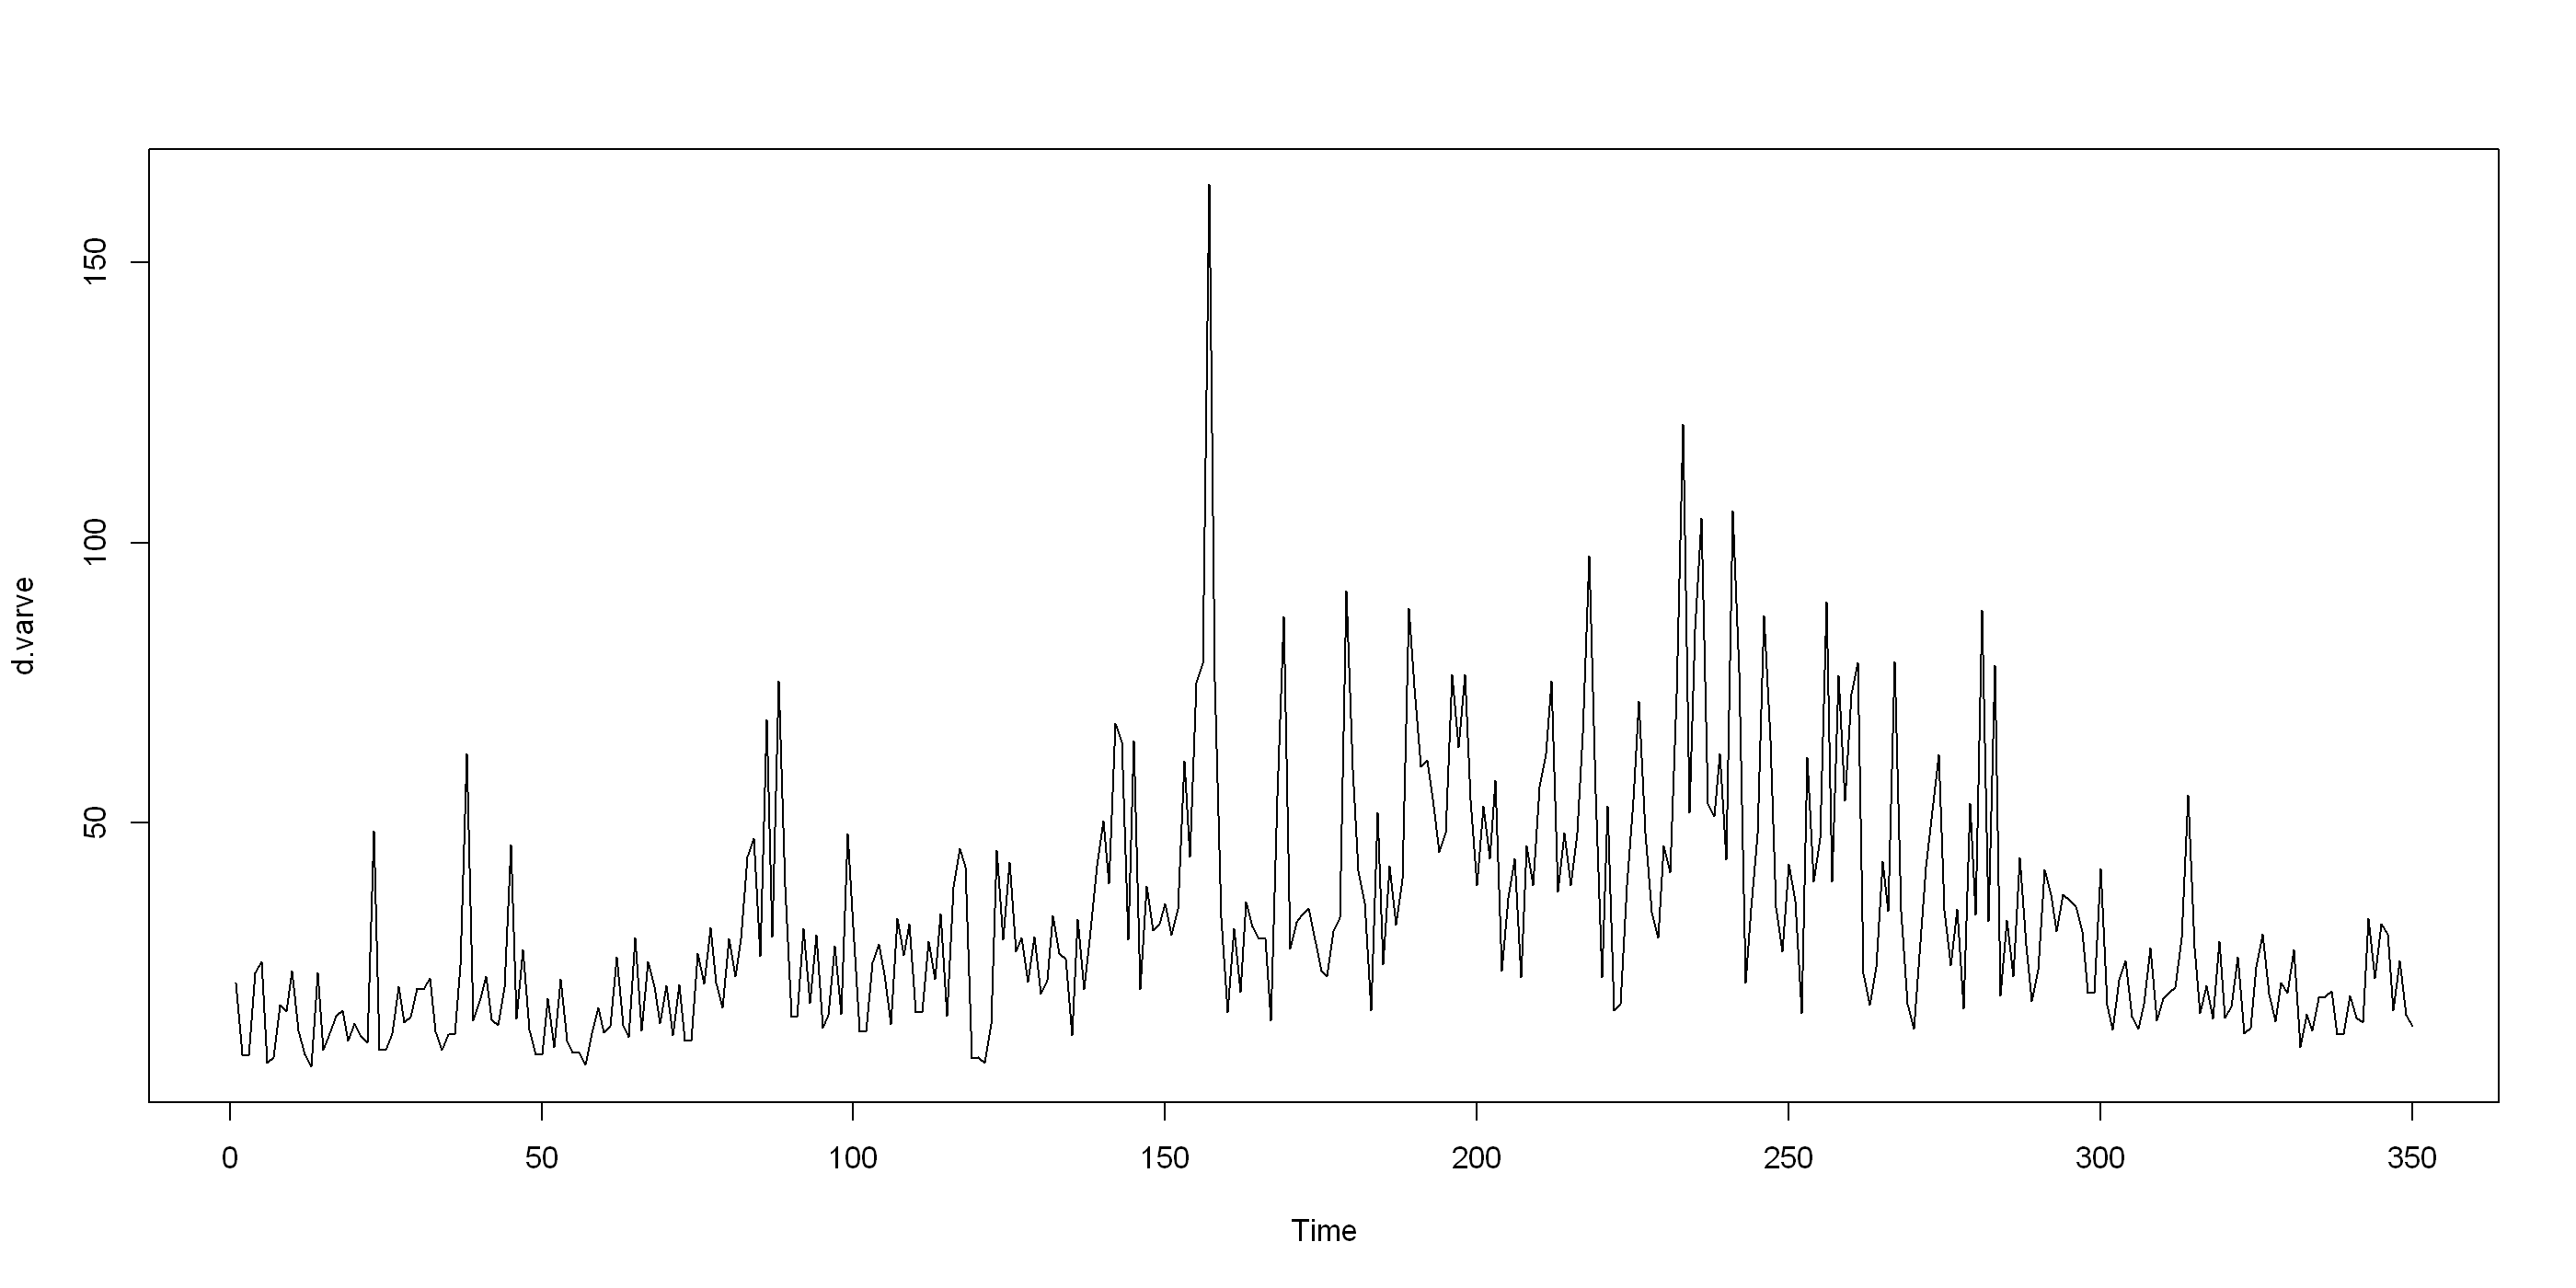

In [73]:
plot(d.varve)

Log-transform will help, but might not suffice.
* It might help because the data has peaks which makes it hard to argue for stationarity
* We might need something stronger because the peaks are so severe and there is like a nonlinear trend

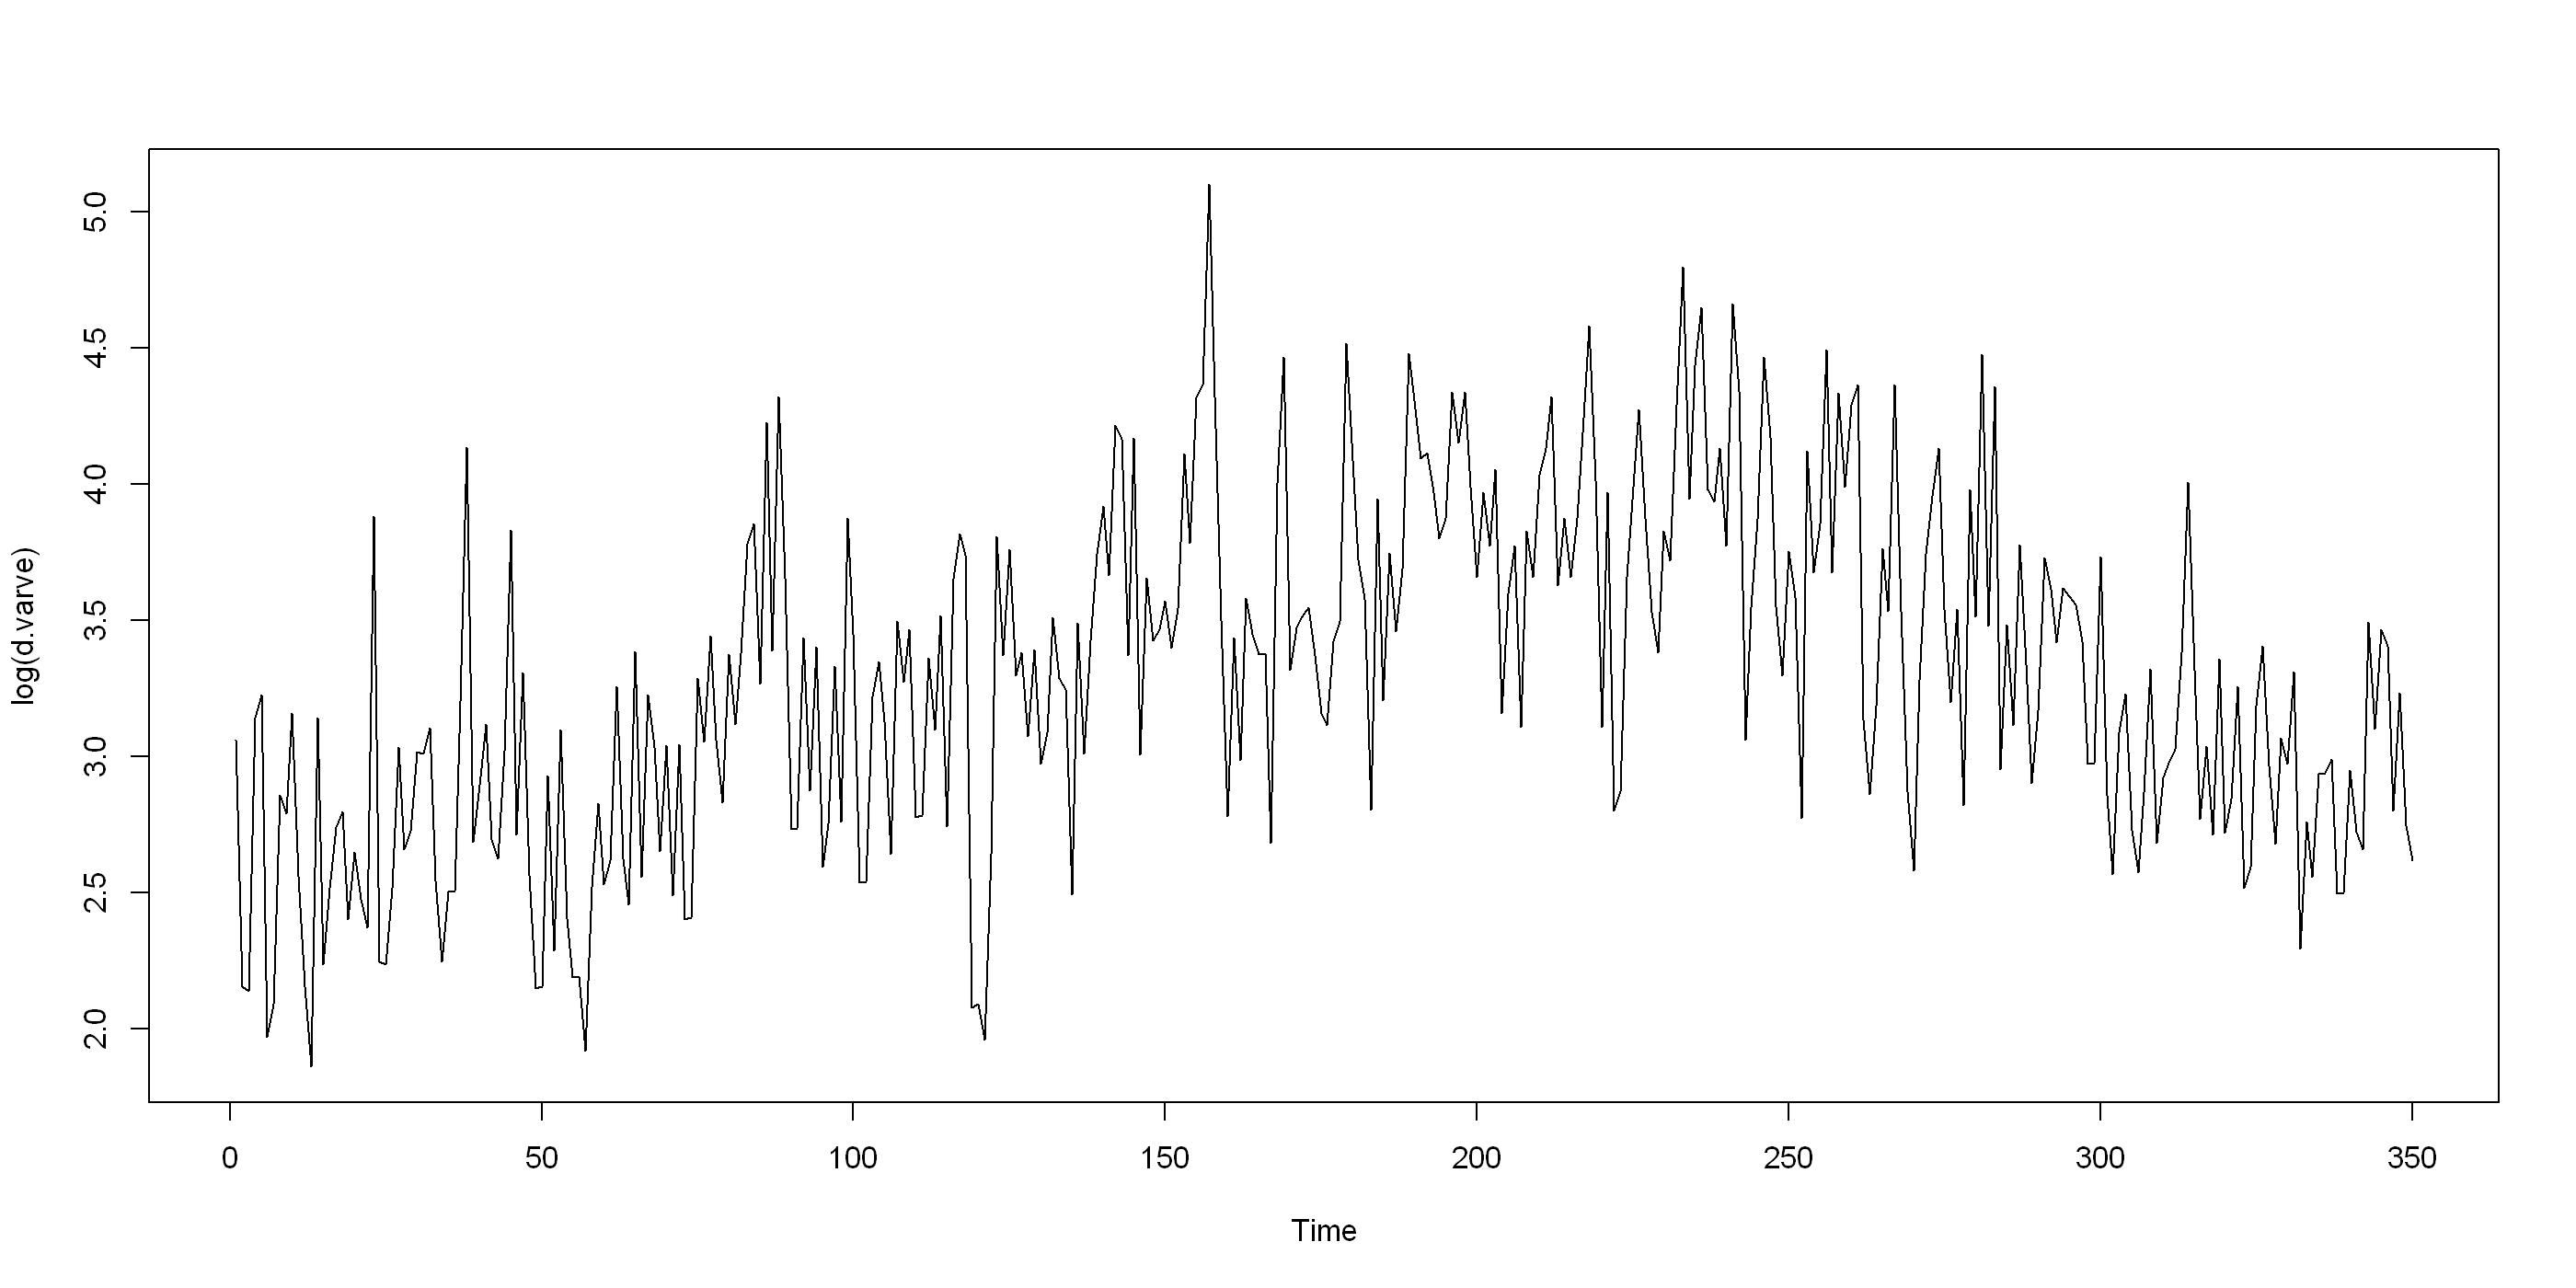

In [74]:
plot(log(d.varve))

#### b

No, the series is not stationary after the transformation there is a clear non-linear trend. We try the classic:
* $\ln(X_t/X_{t-1})$


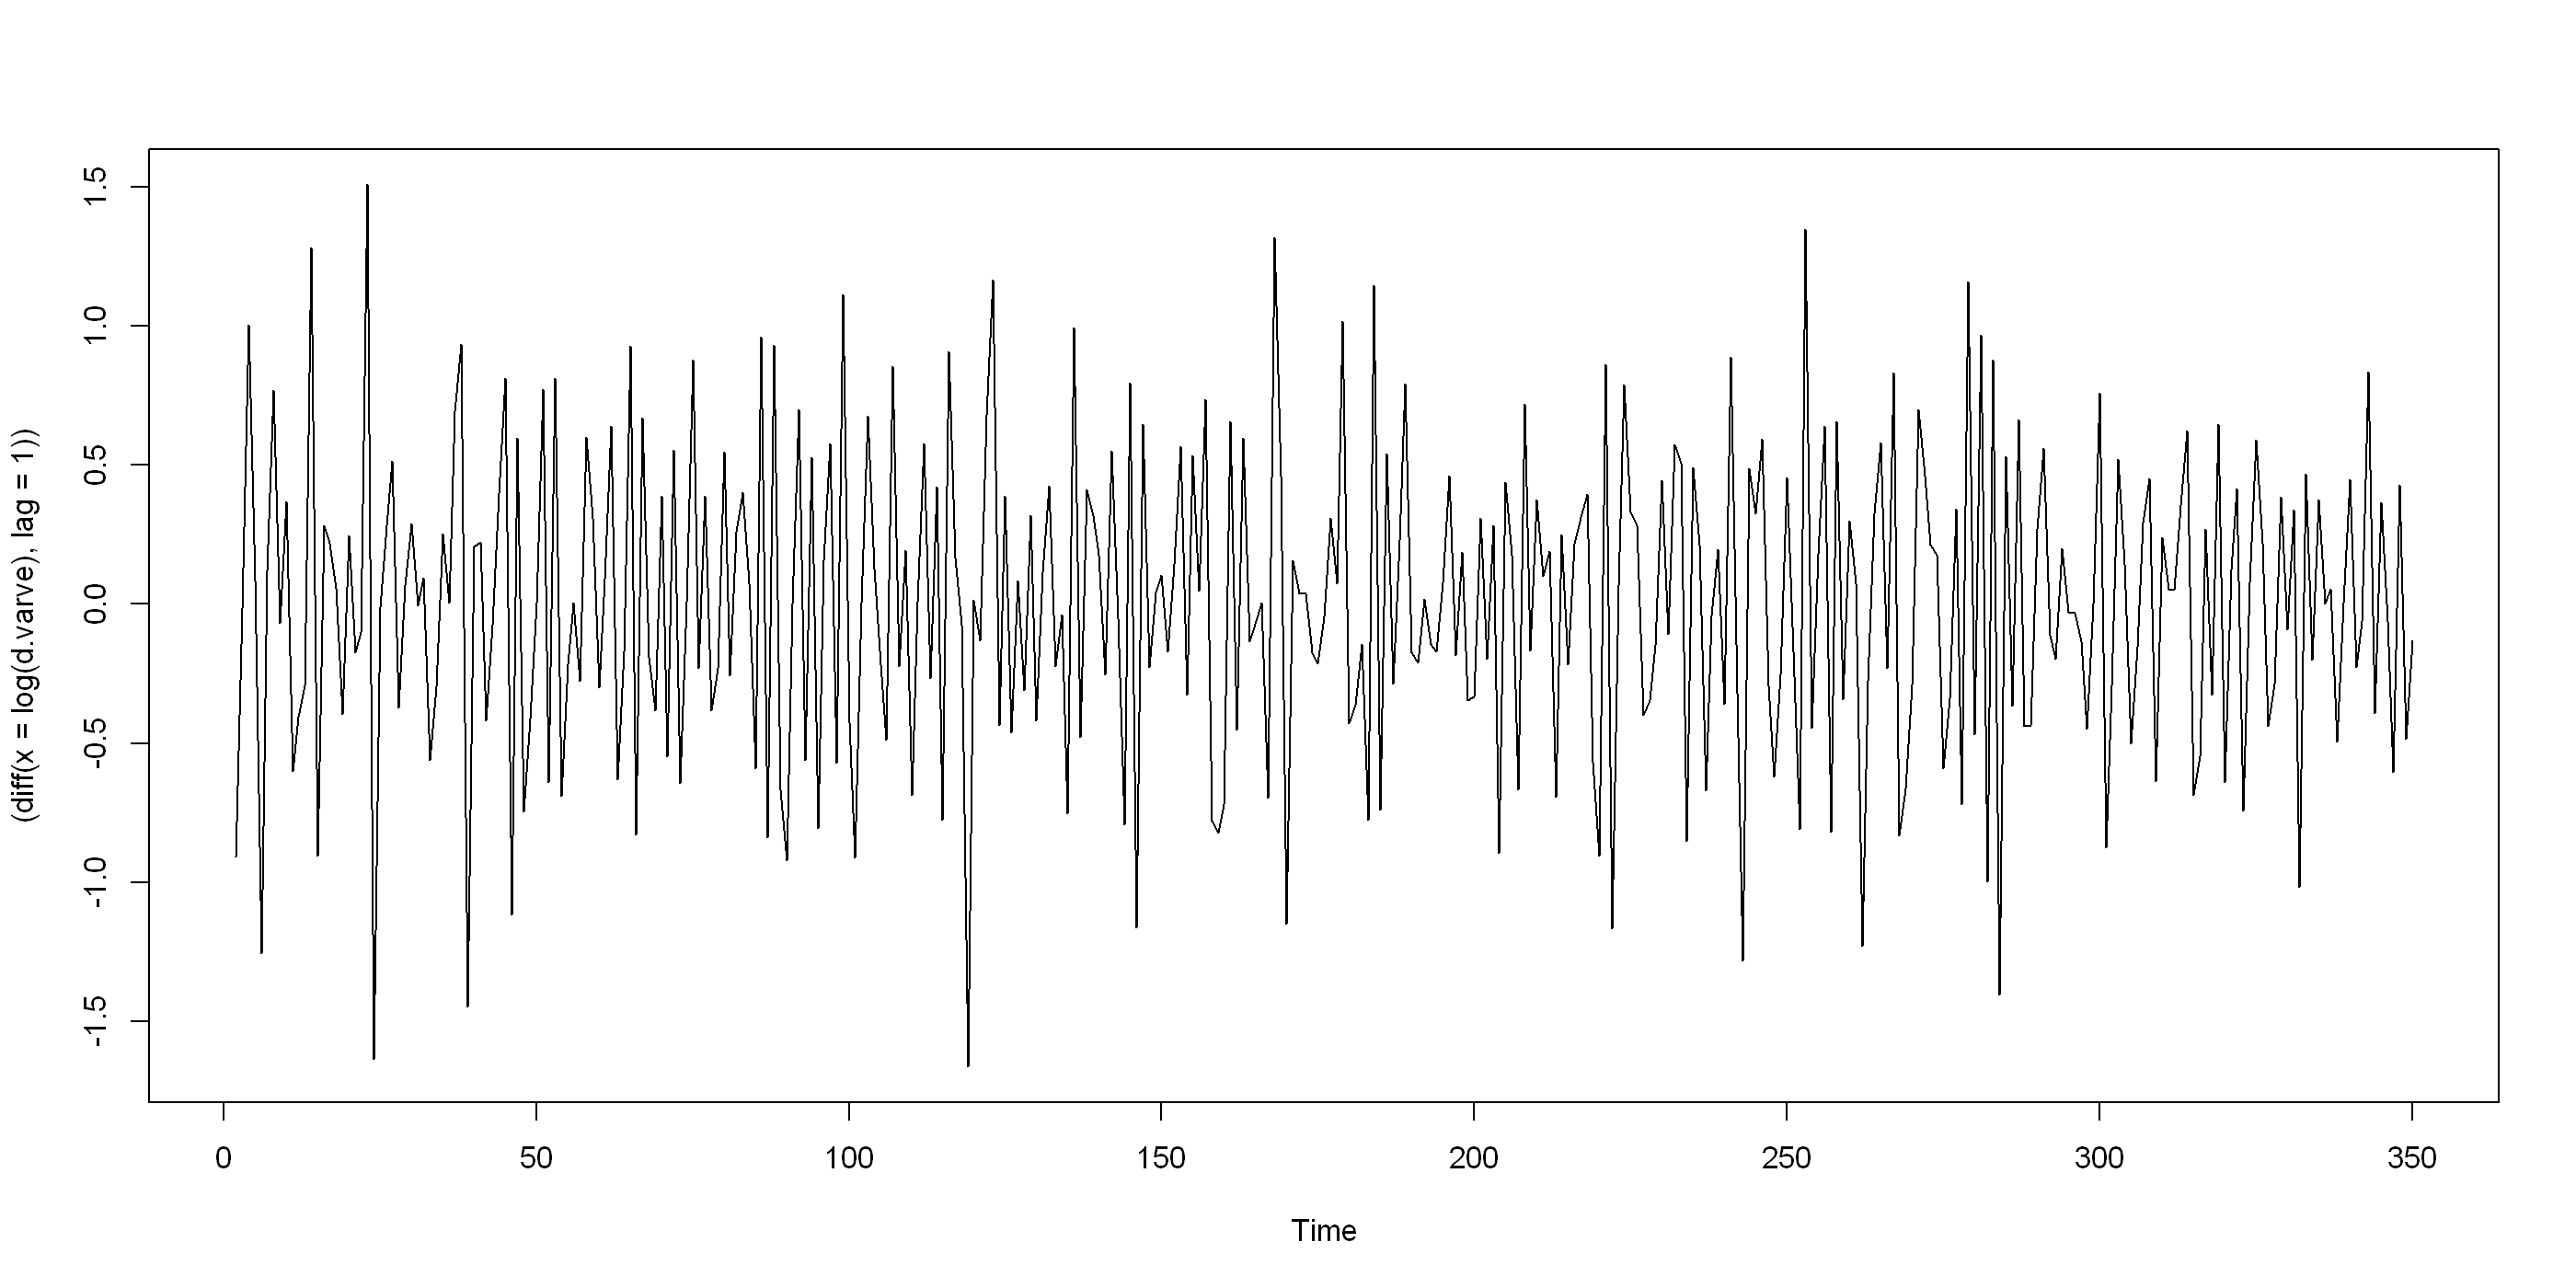

In [75]:
plot((diff(x =log(d.varve) ,lag=1)))


It is clear the series is stationary (or at least there are no evidence that suggest otherwise)

#### c

In [76]:
x.varve <- diff(x =log(d.varve),lag = 1)

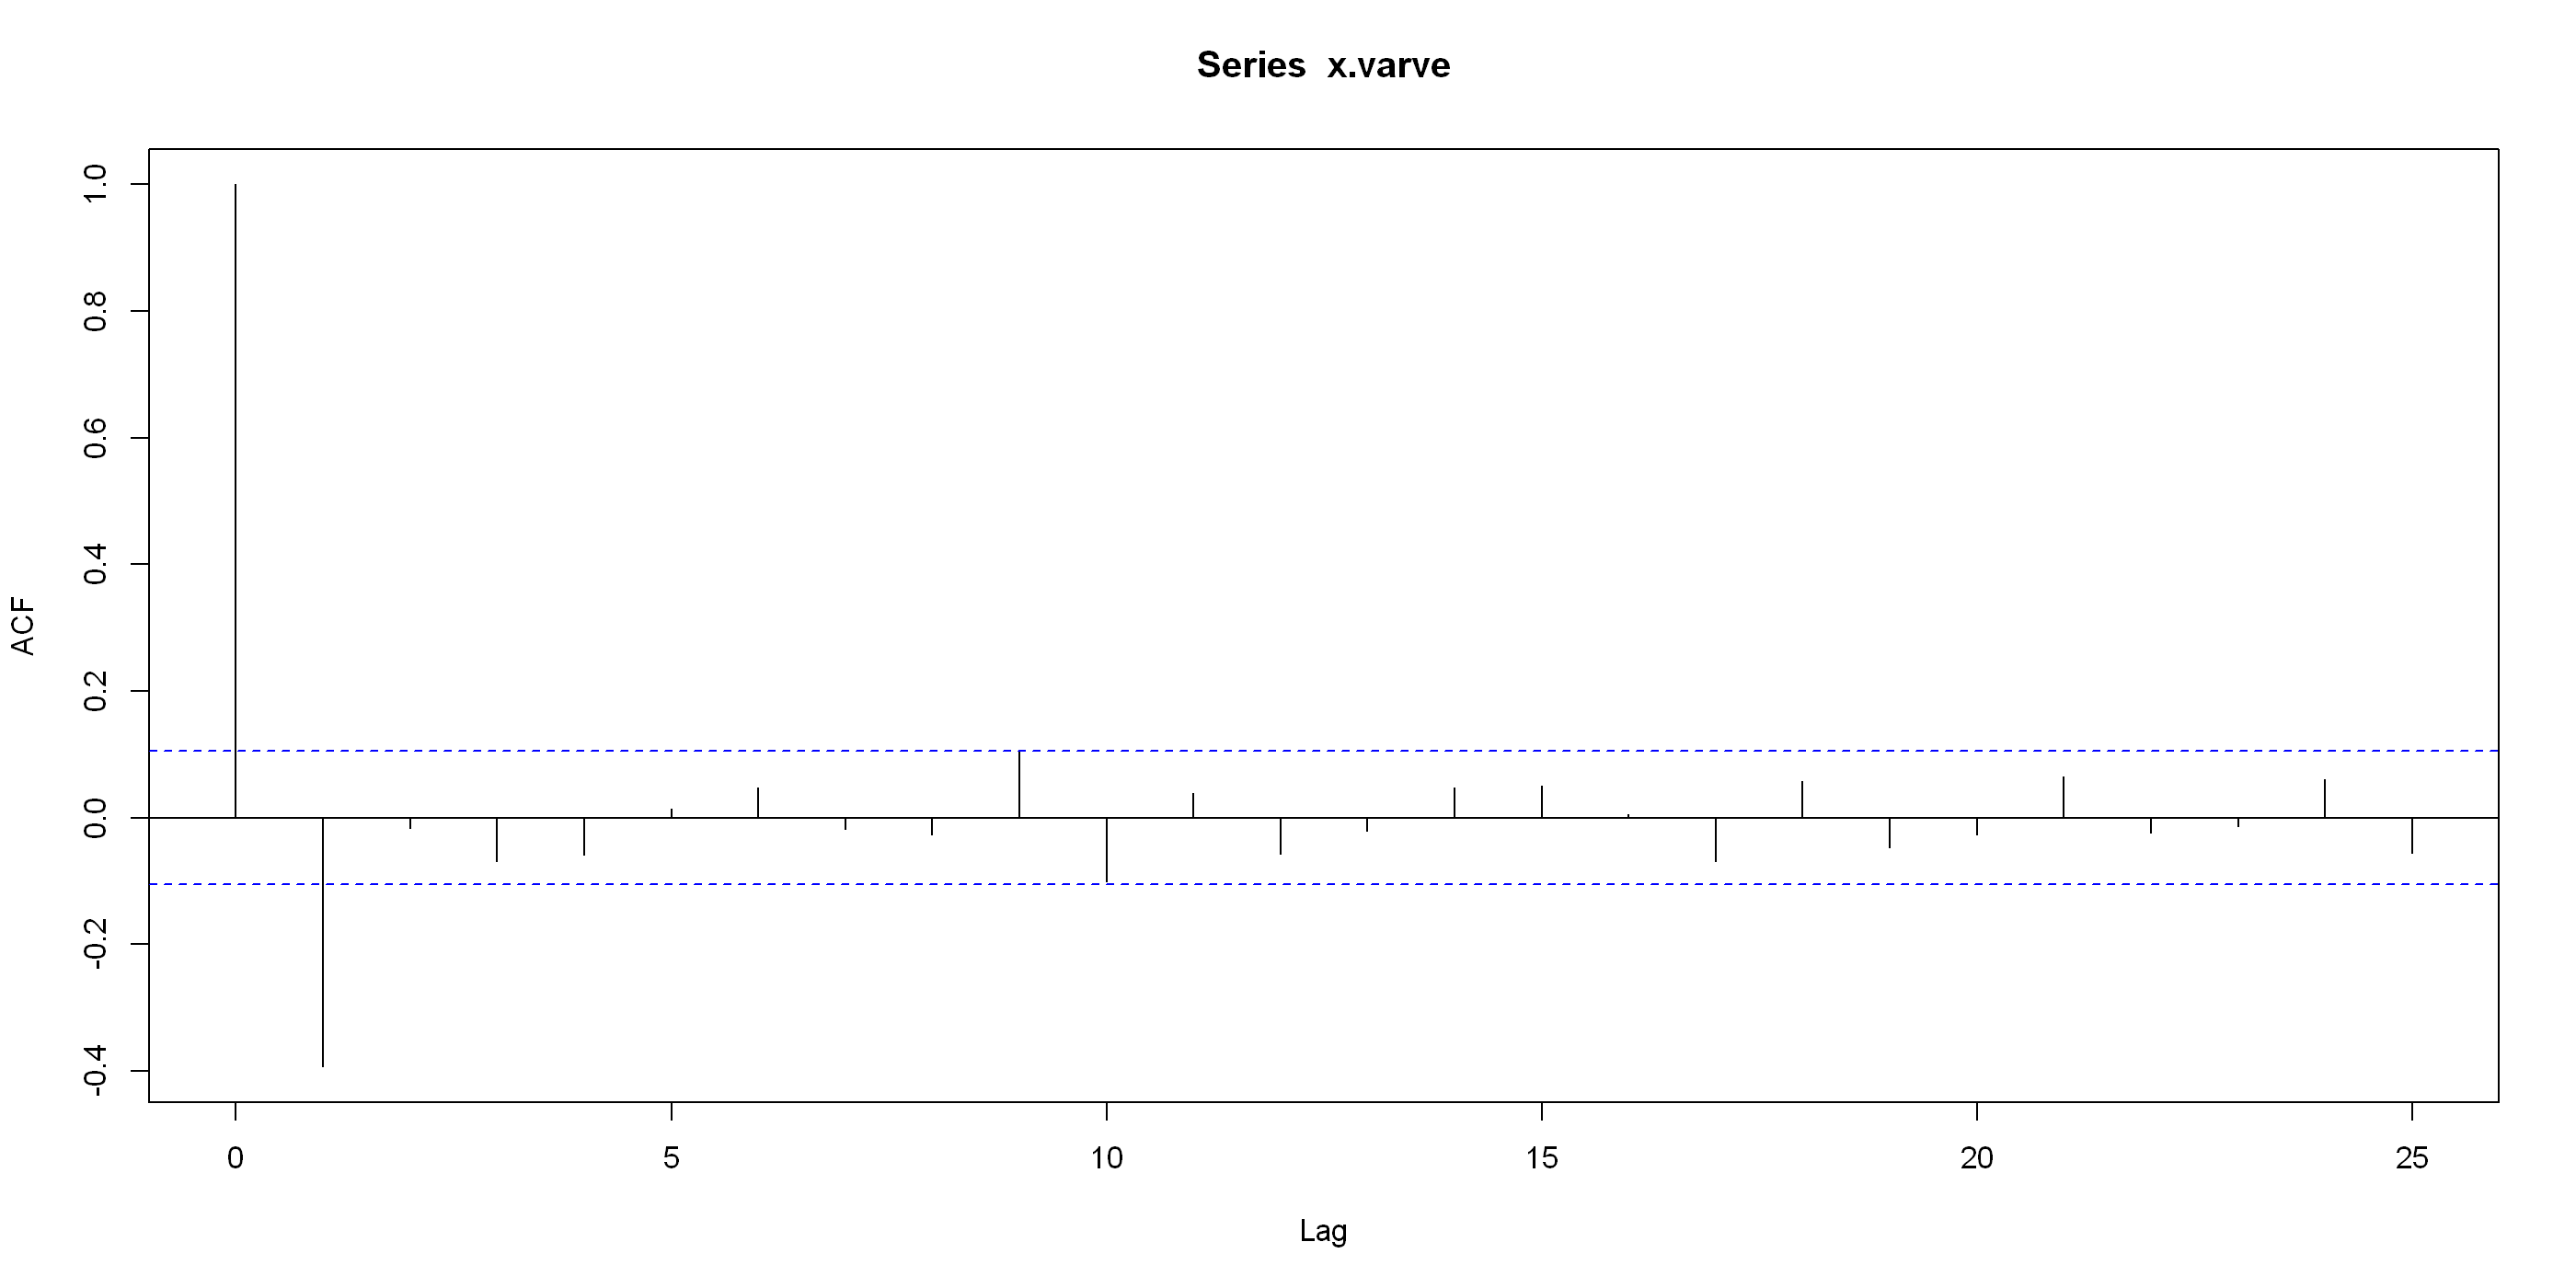

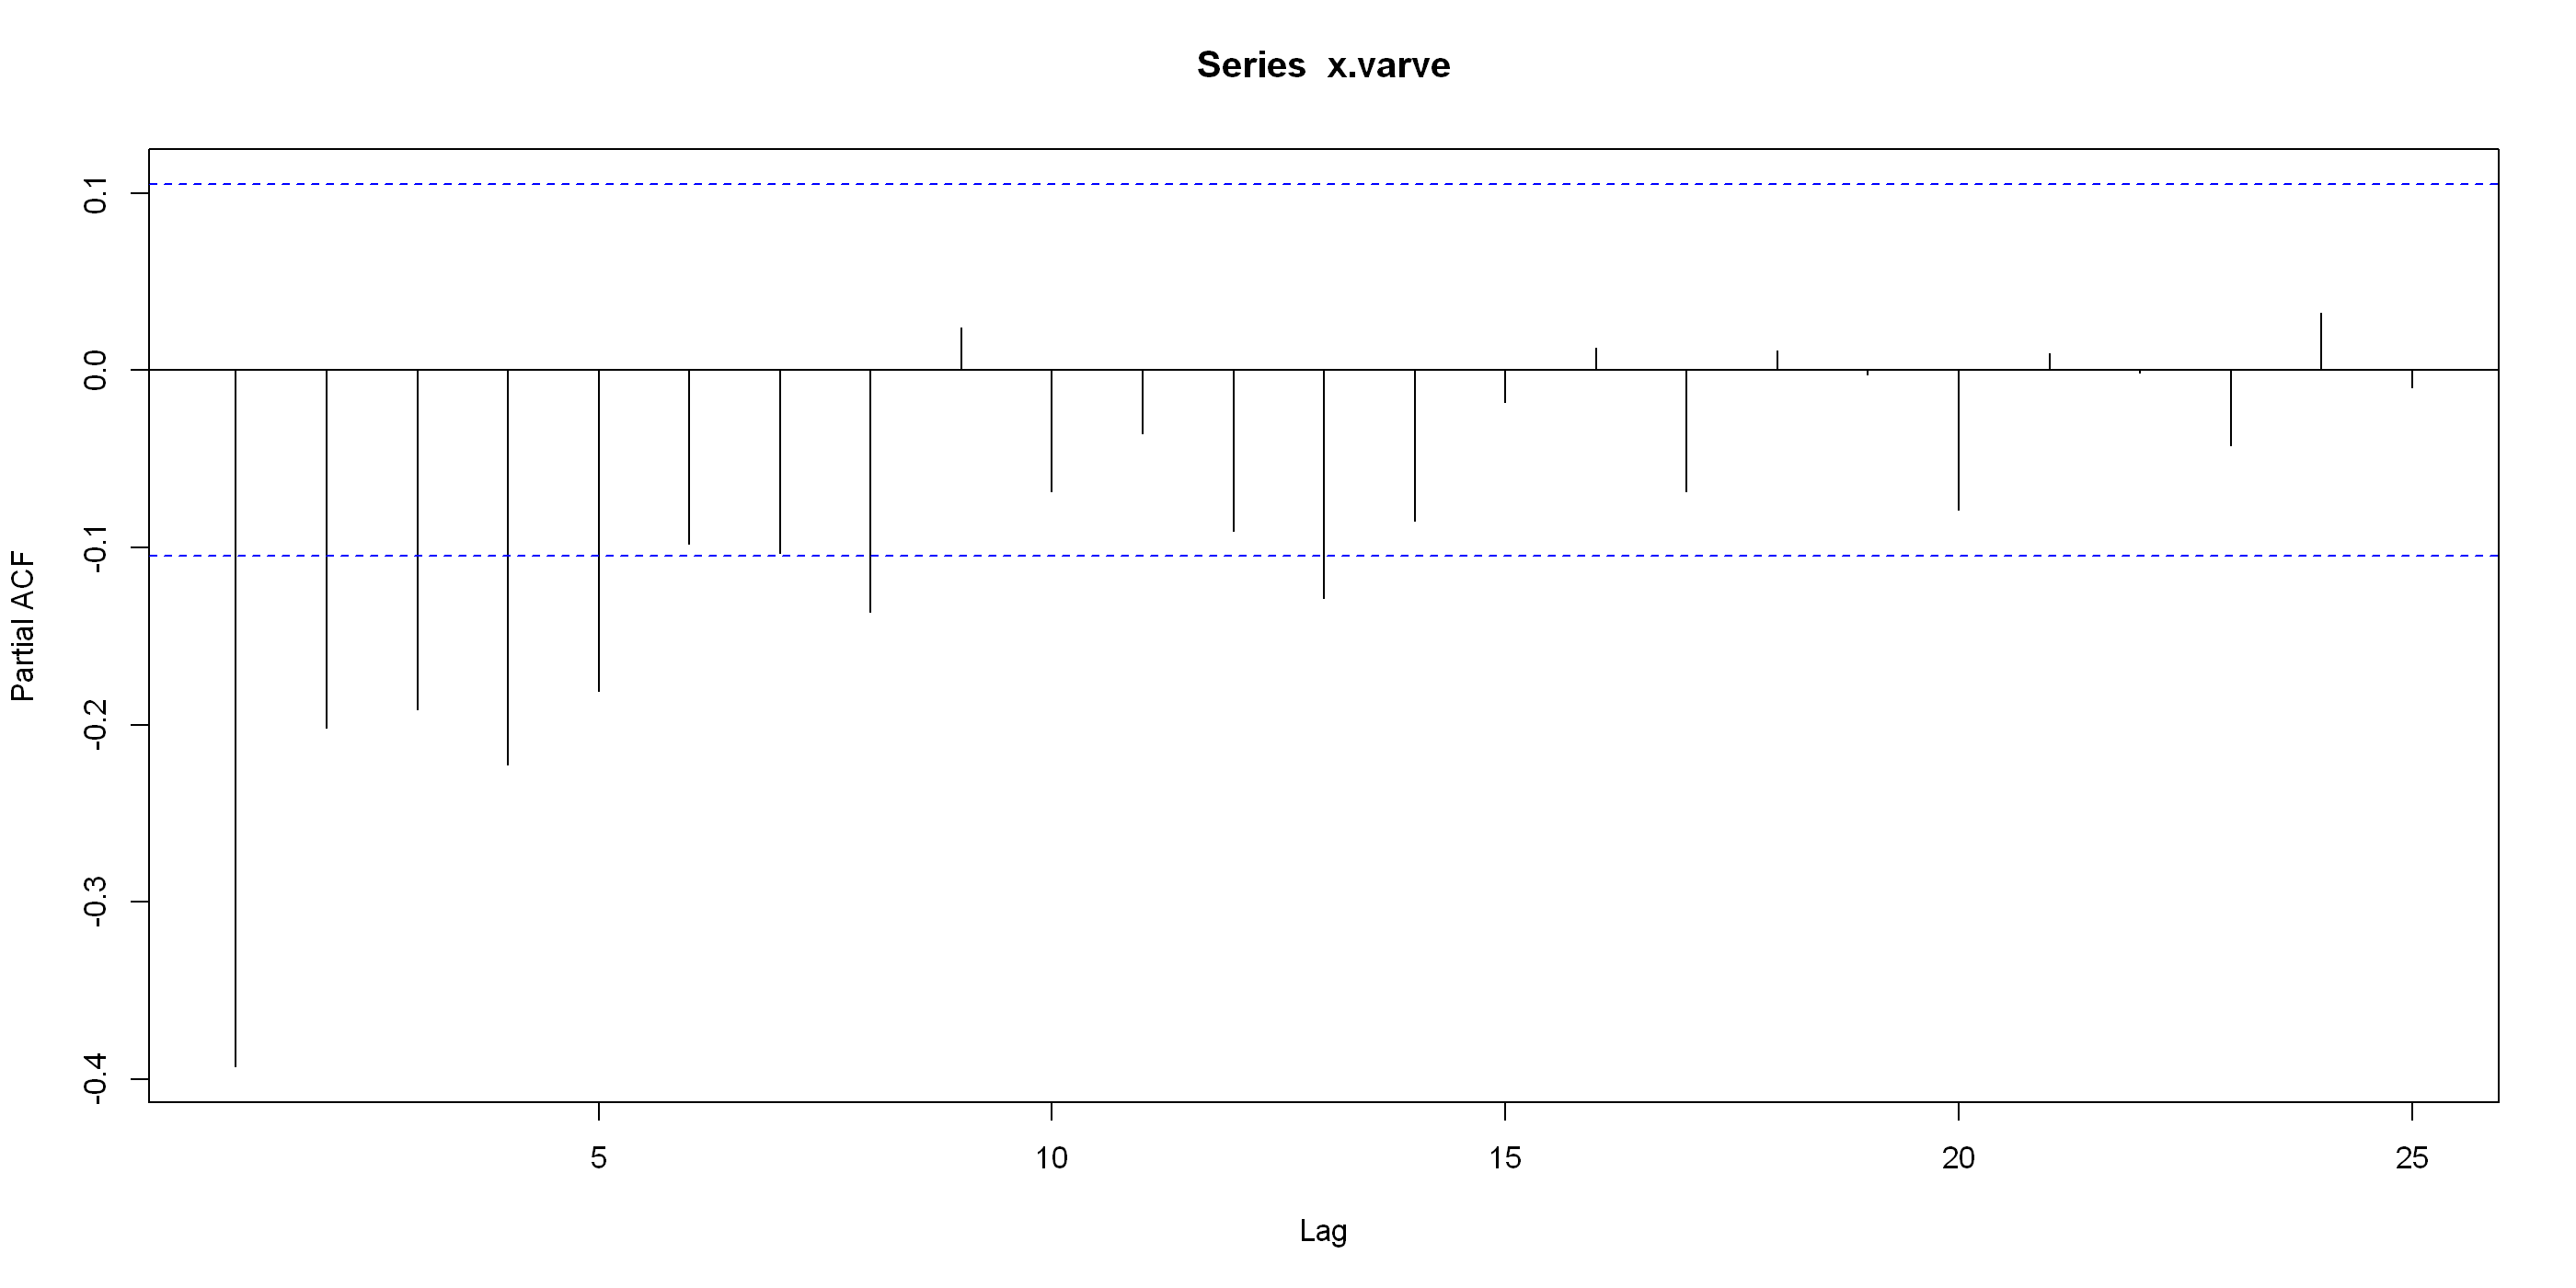

In [77]:
acf(x.varve)
pacf(x.varve)

We argue with the above that a suitable fit might be roughly ARMA(1,1) or similarly any combination of $p \in \{1,2,3,4,5\},q \in \{1,2,3\}$ could be plausible.

In [84]:
library(forecast)

trace_text <- capture.output(
  fit <- auto.arima(x.varve,max.p = 6,max.q = 6,stepwise = FALSE, approximation = FALSE,trace=TRUE,ic="aic",max.order = 10)
)

## lines look like: " ARIMA(2,0,1)                    : 412.1234"
parsed <- regmatches(
  trace_text,
  regexec("ARIMA\\(([0-9]+),([0-9]+),([0-9]+)\\).*?: +([0-9.\\-]+|Inf)", trace_text)
)
parsed <- parsed[lengths(parsed) > 0]

tab <- do.call(rbind, lapply(parsed, function(m) {
  data.frame(spec = m[1], p = as.integer(m[2]), d = as.integer(m[3]),
             q = as.integer(m[4]), AICc = as.numeric(m[5]))
}))
tab <- tab[!is.na(tab$AICc) & is.finite(tab$AICc), ]
head(tab[order(tab$AICc), ], 15)

,spec,p,d,q,AICc
,<chr>,<int>,<int>,<int>,<dbl>
49,"ARIMA(3,0,3) with zero mean : 457.9426",3,0,3,457.9426
17,"ARIMA(1,0,1) with zero mean : 459.304",1,0,1,459.3040
7,"ARIMA(0,0,3) with zero mean : 459.6819",0,0,3,459.6819
50,"ARIMA(3,0,3) with non-zero mean : 459.8455",3,0,3,459.8455
63,"ARIMA(4,0,3) with zero mean : 460.5274",4,0,3,460.5274
31,"ARIMA(2,0,1) with zero mean : 460.8282",2,0,1,460.8282
19,"ARIMA(1,0,2) with zero mean : 461.0124",1,0,2,461.0124
18,"ARIMA(1,0,1) with non-zero mean : 461.2019",1,0,1,461.2019
45,"ARIMA(3,0,1) with zero mean : 461.2392",3,0,1,461.2392


In [87]:
trace_text <- capture.output(
  fit <- auto.arima(x.varve,
                    max.p = 6, max.q = 6, max.order = 10,
                    stepwise = FALSE, approximation = FALSE,
                    ic = "bic", trace = TRUE)
)

parsed <- regmatches(
  trace_text,
  regexec("ARIMA\\(([0-9]+),([0-9]+),([0-9]+)\\).*?: +([0-9.\\-]+|Inf)", trace_text)
)
parsed <- parsed[lengths(parsed) > 0]

tab <- do.call(rbind, lapply(parsed, function(m) {
  data.frame(spec = m[1],
             p = as.integer(m[2]), d = as.integer(m[3]), q = as.integer(m[4]),
             BIC = as.numeric(m[5]))
}))
tab <- tab[!is.na(tab$BIC) & is.finite(tab$BIC), ]
head(tab[order(tab$BIC), ], 15)

,spec,p,d,q,BIC
,<chr>,<int>,<int>,<int>,<dbl>
17,"ARIMA(1,0,1) with zero mean : 470.8692",1,0,1,470.8692
5,"ARIMA(0,0,2) with zero mean : 473.2395",0,0,2,473.2395
7,"ARIMA(0,0,3) with zero mean : 475.1022",0,0,3,475.1022
31,"ARIMA(2,0,1) with zero mean : 476.2485",2,0,1,476.2485
19,"ARIMA(1,0,2) with zero mean : 476.4327",1,0,2,476.4327
18,"ARIMA(1,0,1) with non-zero mean : 476.6222",1,0,1,476.6222
6,"ARIMA(0,0,2) with non-zero mean : 479.0006",0,0,2,479.0006
45,"ARIMA(3,0,1) with zero mean : 480.5145",3,0,1,480.5145
8,"ARIMA(0,0,3) with non-zero mean : 480.8558",0,0,3,480.8558


ARIMA(1,0,1), it is (with zero mean).

In [97]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


In [98]:
r.varve <- arima(x.varve,order = c(1,0,1),include.mean = F)

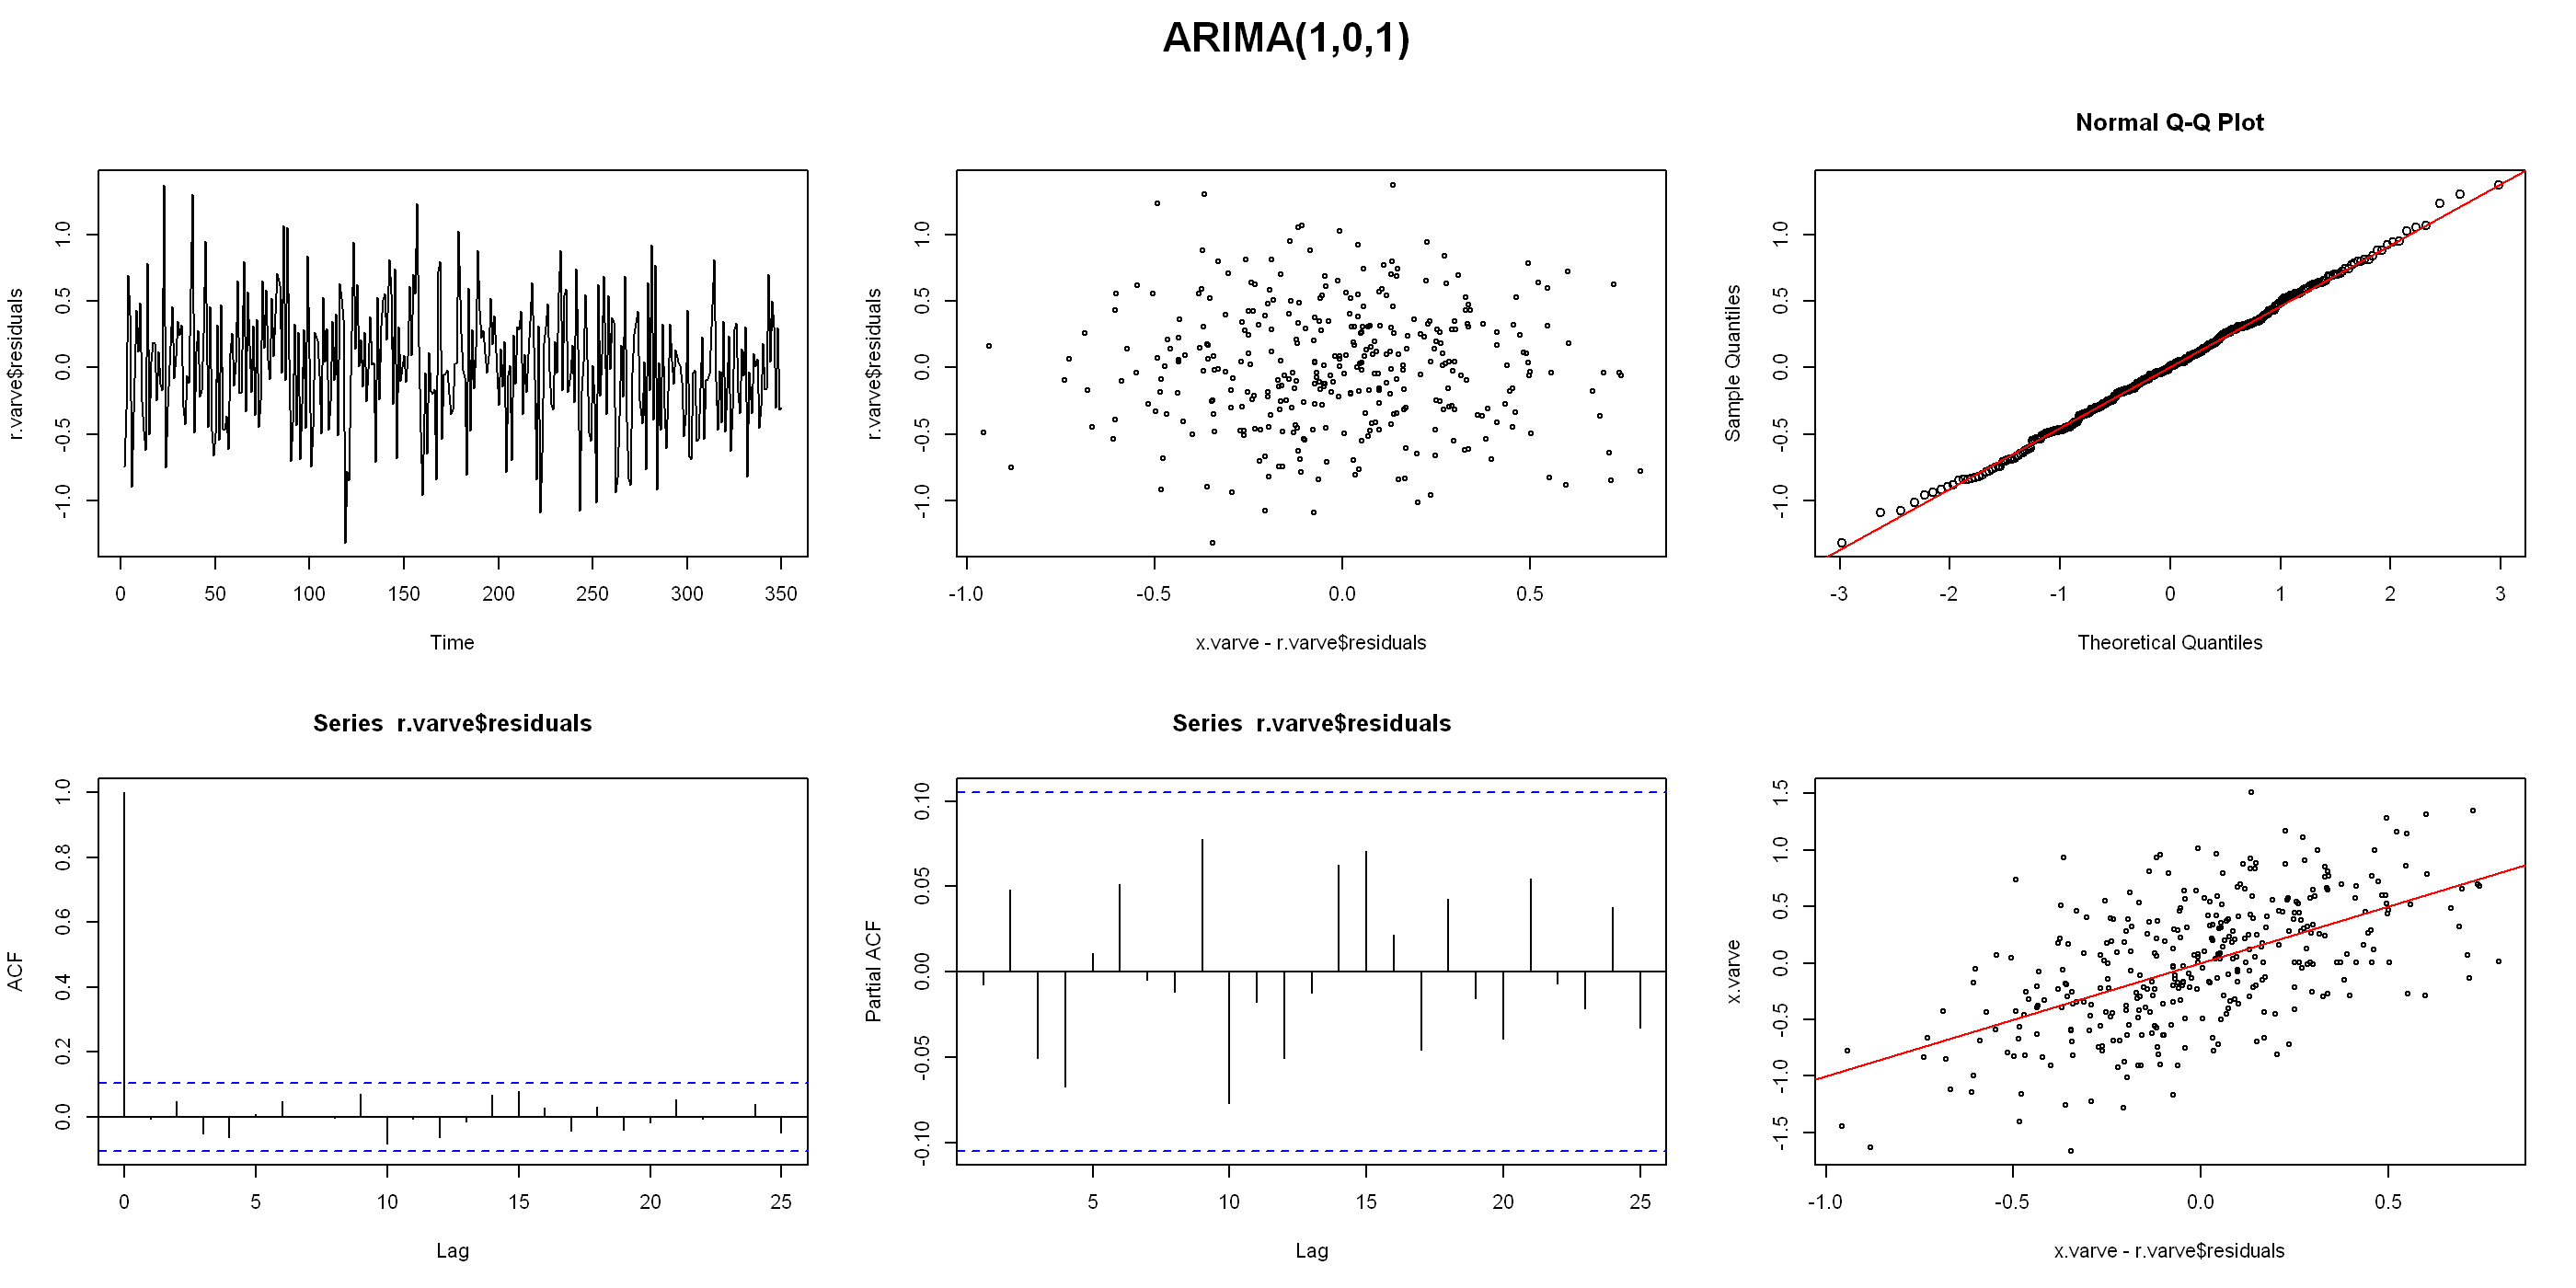

In [150]:
par(mfrow = c(2,3),oma=c(0,0,3,0))
plot(r.varve$residuals)
plot(x.varve-r.varve$residuals,r.varve$residuals)
qqnorm(r.varve$residuals)
qqline(r.varve$residuals,col="red")
acf(r.varve$residuals)
pacf(r.varve$residuals)
plot(x.varve-r.varve$residuals,x.varve)
abline(0, 1,col="red")
title("ARIMA(1,0,1)",outer=TRUE, cex.main=2)


In [105]:
print(r.varve$coef)

       ar1        ma1 
 0.2460979 -0.9139683 


$$
f^*(x,(\alpha_1,\beta_1))_t = \alpha^*_1 x^*_{t-1}+\beta^*_1 E^*_{t-1}+E^*_t \approx 0.246 x^*_{t-1}-0.914^*_1 E^*_{t-1}+E^*_t
$$

which yields (in transformed form):

$$
f(x,(\alpha_1,\beta_1))_t = \exp(\alpha^*_1 x^*_{t-1}+\beta^*_1 E^*_{t-1}+E^*_t)*x_{t-1} \approx \exp(0.246 x^*_{t-1}-0.914^*_1 E^*_{t-1}+E^*_t)*x_{t-1}
$$

and our fit becomes
$$
f(x,(\alpha_1,\beta_1))_t \approx \exp(\alpha^*_1 x^*_{t-1}+\beta^*_1 E^*_{t-1})*x_{t-1} \approx \exp(0.246 x^*_{t-1}-0.914^*_1 E^*_{t-1})*x_{t-1}
$$
Note that by the above analysis the residuals are almost perfectly standard-normals, hence this approximation is fine (from the bias perspective).

In [127]:
fit_normalScale_biased <- exp(r.varve$coef[1]*lag(x.varve,k = 1)+r.varve$coef[2]*lag(r.varve$residuals,k=1))*lag(d.varve,k = 1)

In [128]:
sigma_2 <- (var(r.varve$residuals))

In [129]:
fit_normalScale_biasSmooth <- exp(r.varve$coef[1]*lag(x.varve,k = 1)+r.varve$coef[2]*lag(r.varve$residuals,k=1)+sigma_2/2)*lag(d.varve,k = 1)

Just for fun we try the following

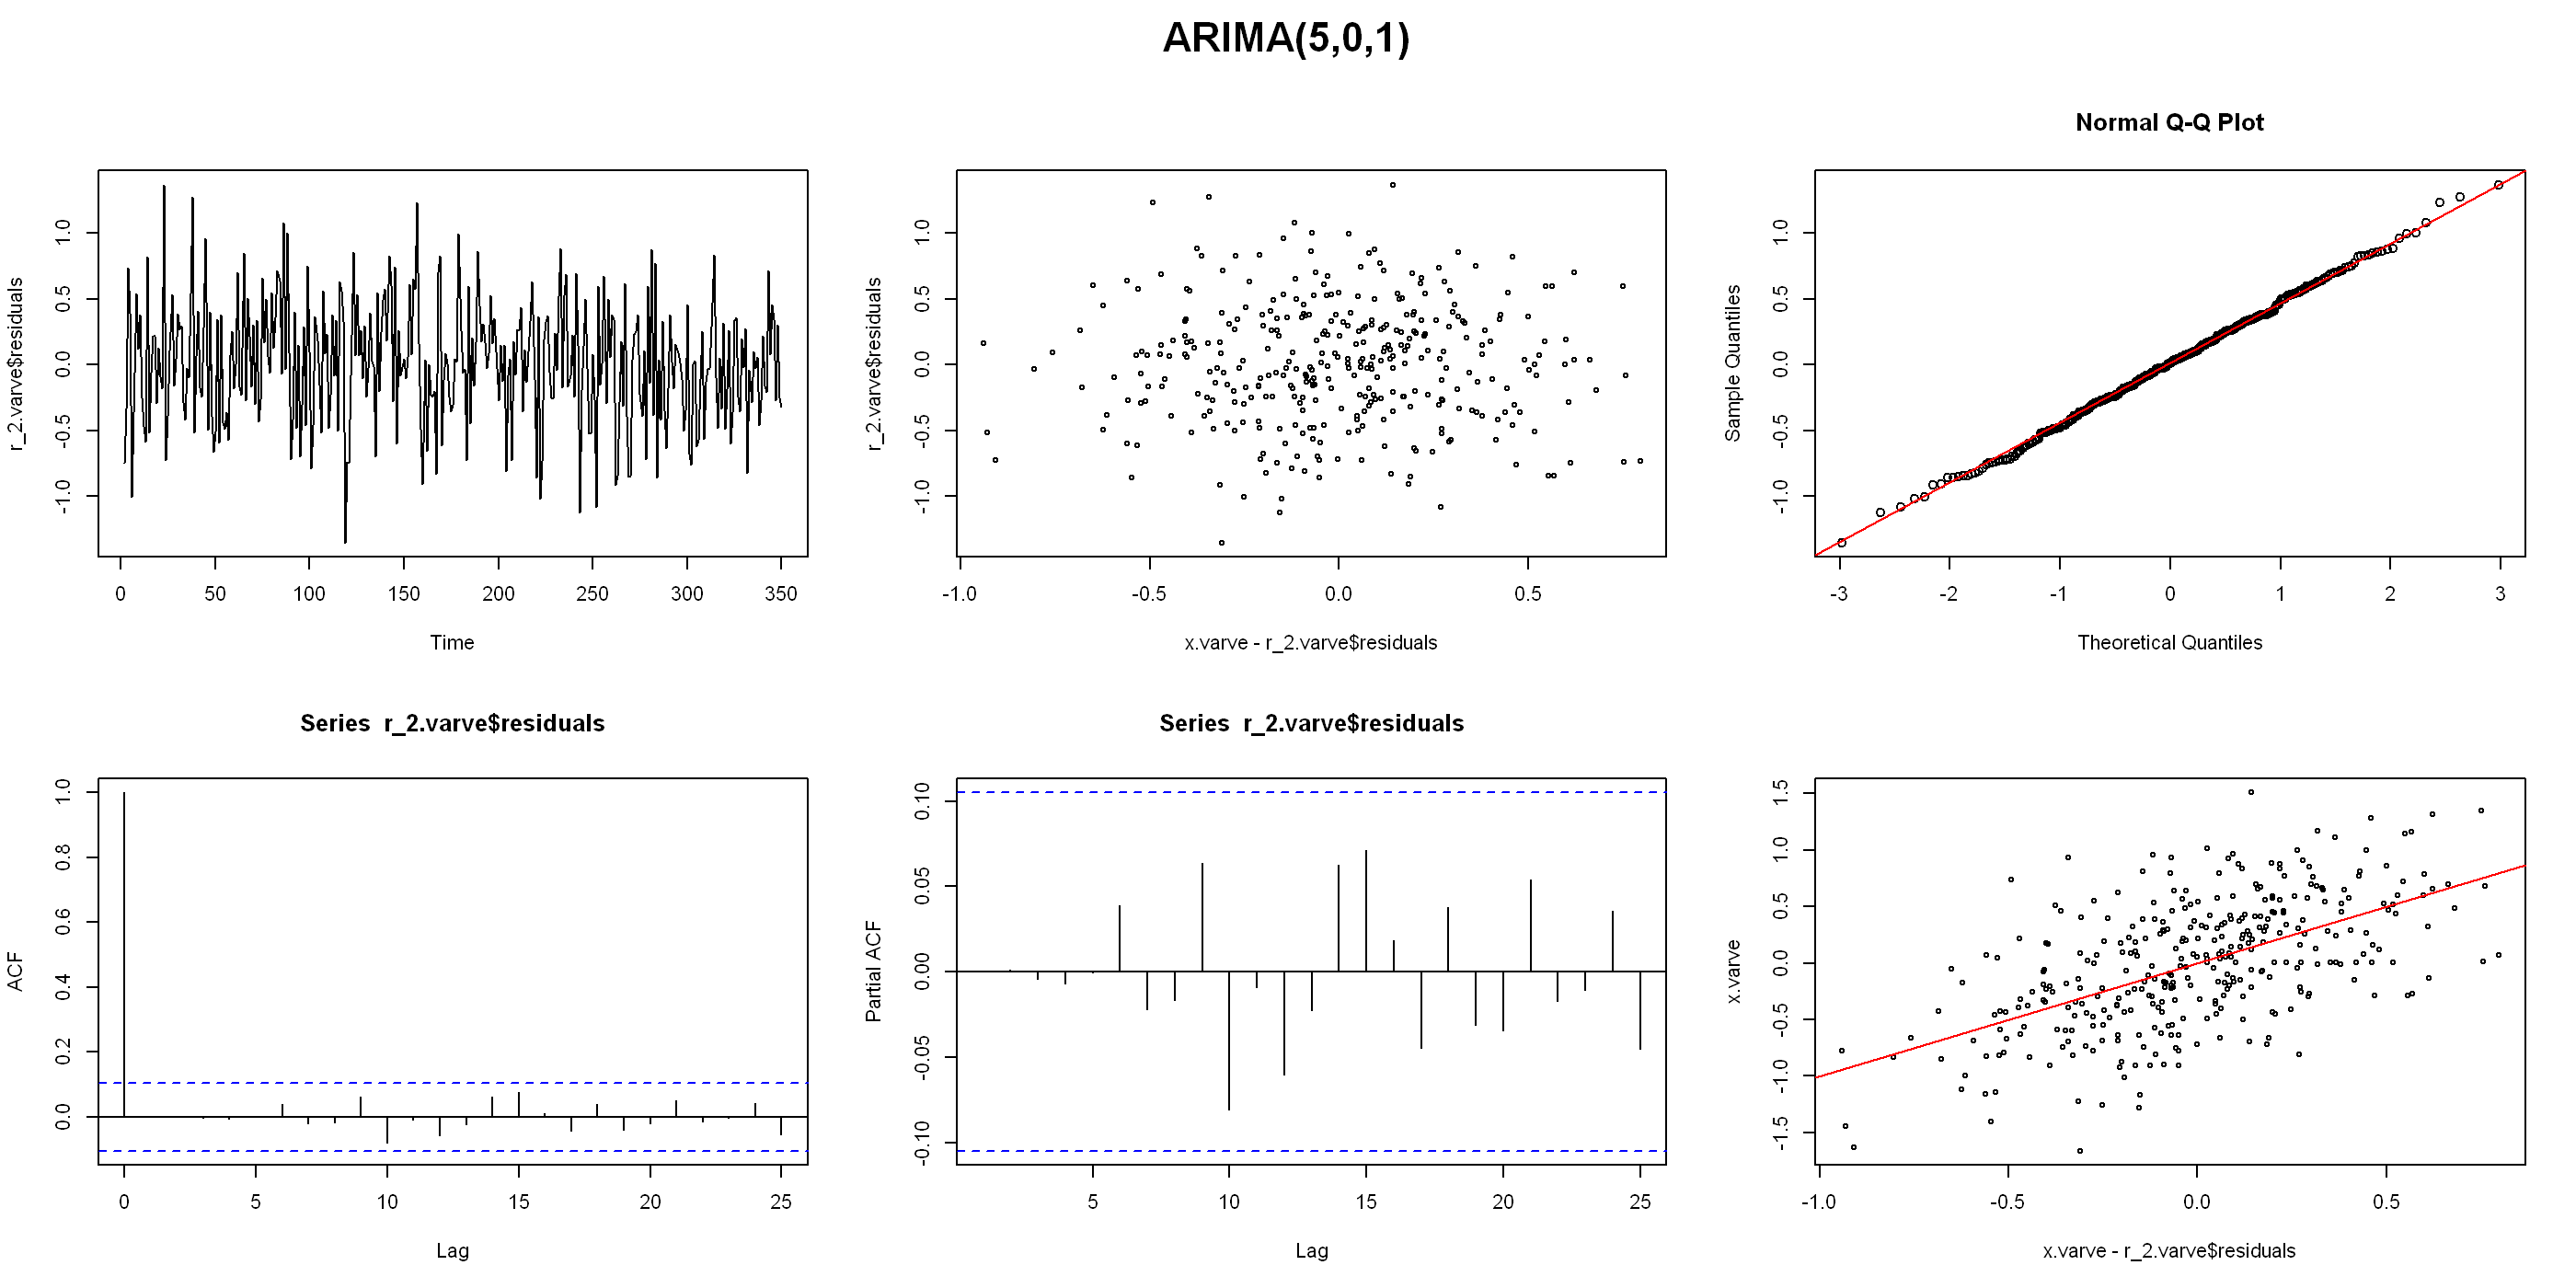

In [151]:
r_2.varve <- arima(x.varve,order = c(5,0,1),include.mean = F)
par(mfrow = c(2,3),oma=c(0,0,3,0))
plot(r_2.varve$residuals)
plot(x.varve-r_2.varve$residuals,r_2.varve$residuals)
qqnorm(r_2.varve$residuals)
qqline(r_2.varve$residuals,col="red")
acf(r_2.varve$residuals)
pacf(r_2.varve$residuals)
plot(x.varve-r_2.varve$residuals,x.varve)
abline(0, 1,col="red")
title("ARIMA(5,0,1)",outer=TRUE, cex.main=2)

fit_normalScale_biasSmooth_5 <- exp(r_2.varve$coef[1]*lag(x.varve,k = 1)+r_2.varve$coef[2]*lag(r_2.varve$residuals,k=1)+sigma_2/2)*lag(d.varve,k = 1)


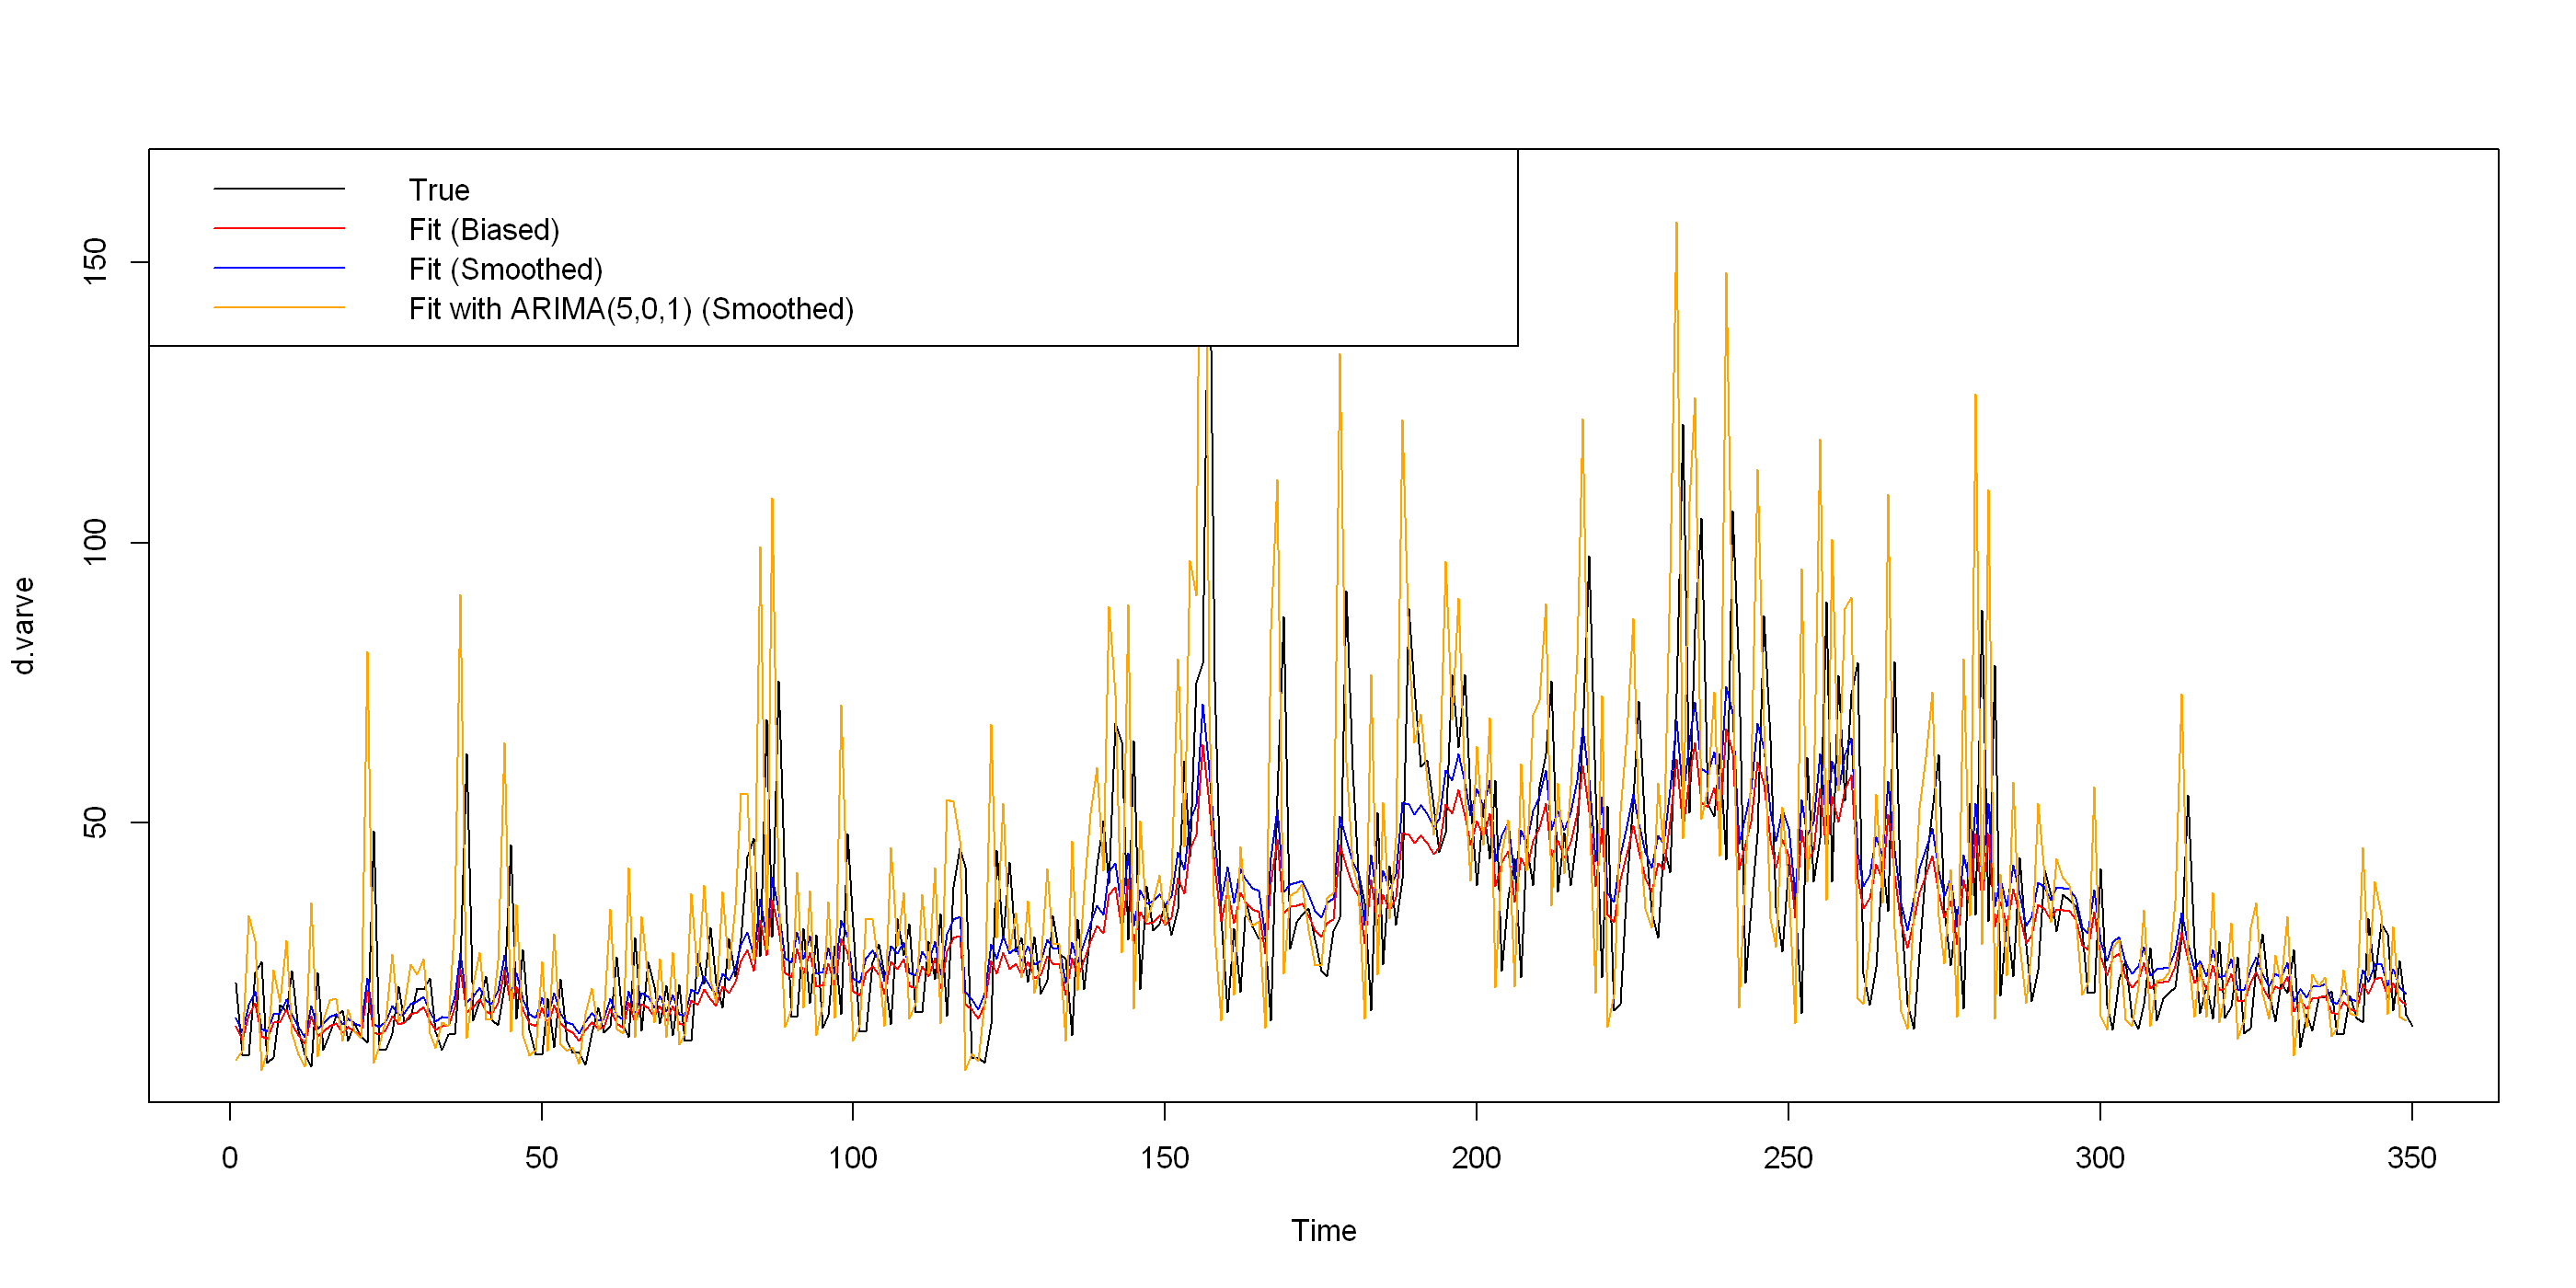

In [154]:
plot(d.varve)
lines(fit_normalScale_biased,col="red")
lines(fit_normalScale_biasSmooth,col="blue")
lines(fit_normalScale_biasSmooth_5,col="orange")
legend(x="topleft",legend = c("True","Fit (Biased)","Fit (Smoothed)","Fit with ARIMA(5,0,1) (Smoothed)"),col=c("black","red","blue","orange"),lw=1)